# Run 8 — Detect → Segment → Classify (clean baseline)

**Breast mass pipeline on CBIS-DDSM (mass-only).** Consolidated from Run 7. This is the
*sacred baseline*: it contains only the cells that were proven to work, with the winning
config baked in. Experimental ideas live in the fenced section at the bottom and only get
merged here if they beat the baseline number.

**Pipeline:** YOLOv8s detector → crop → EfficientNet-B0 + UNet++ (shared encoder, MTL
seg + classification head) → mask remapped onto the full image → benign/malignant + Grad-CAM++.

**Two-phase training:**
- *Phase A* — 3-class MTL (benign / malignant / no-mass) so hard-negative crops teach the
  segmenter "empty here". Establishes segmentation + base classifier.
- *Phase B* — re-head to 2 classes and fine-tune the classifier with a **malignant CE weight
  of 2.5** (the sensitivity bias-fix). This is the config that produced the best end-to-end numbers.

**Reference (Run 7, cached weights):** E2E Dice 0.4025 · ROI-Dice 0.8169 · AUC 0.6101 ·
Sens 0.5374 · Spec 0.6147.

> **Read me first — what changed vs Run 7, and why your numbers may shift:**
> 1. **Preprocessing is now consistent.** Run 7 built the YOLO dataset with percentile
>    windowing but ran inference with breast-profile windowing — a train/inference mismatch.
>    Run 8 uses breast-profile **everywhere**, defined once. This is a correctness fix, so
>    re-running may move the numbers off the cached 0.40 — that is expected and correct.
> 2. **Winning config baked into CONFIG:** `YOLO_CONF = 0.38`, YOLO trains 50 epochs
>    (Run 7's default was 0.20 / a 3-epoch test stub).
> 3. **Export + desktop code now ship the 2-class bias-fixed model** (Run 7 was exporting the
>    stale 3-class base model at conf 0.20).
> 4. Removed: the 6-channel context branches, sequential fine-tuning, Telegram cells, the
>    Gemini-agent task/reasoning markdown, and all duplicate "unpatched" cells.

In [ ]:
!pip install -q ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 34.4 MB/s eta 0:00:00


## Set up Kaggle API Credentials

To download datasets from Kaggle, you need to provide your API credentials. Follow these steps:

1.  **Generate Kaggle API Token:** Go to your Kaggle account settings (kaggle.com/your_username/account), scroll down to the 'API' section, and click 'Create New API Token'. This will download a `kaggle.json` file.
2.  **Upload `kaggle.json` to Colab:** In the left sidebar of Colab, click on the 'Files' icon (folder icon). Then, click the 'Upload to session storage' icon (file with an up arrow) and upload your `kaggle.json` file.
3.  **Securely store `kaggle.json` content (Optional but Recommended):** For better security, you can read the contents of `kaggle.json` and store them in Colab's 'Secrets' manager. This avoids re-uploading the file in future sessions. Name the secret `KAGGLE_CONFIG_JSON`.

Once `kaggle.json` is in your session storage (or its content is in Colab Secrets), the following cells will use it to authenticate and download the dataset.

In [ ]:
# Install kagglehub and the standard kaggle client
!pip install -q kaggle kagglehub

import os
from pathlib import Path
from google.colab import userdata

# Set up Kaggle credentials from Colab Secrets
try:
    kaggle_json = userdata.get('KAGGLE_CONFIG_JSON')
    kaggle_dir = Path('/root/.kaggle')
    kaggle_dir.mkdir(parents=True, exist_ok=True)
    with open(kaggle_dir / 'kaggle.json', 'w') as f:
        f.write(kaggle_json)
    os.chmod(kaggle_dir / 'kaggle.json', 0o600)
    print("Kaggle credentials configured from Secrets! You can now run the next cells.")
except userdata.SecretNotFoundError:
    print("Secret 'KAGGLE_CONFIG_JSON' not found in Colab Secrets. Falling back to interactive login.")
    import kagglehub
    kagglehub.login()
    print("Kaggle API client configured! You can now run the next cells.")


Secret 'KAGGLE_CONFIG_JSON' not found in Colab Secrets. Falling back to interactive login.


Kaggle API client configured! You can now run the next cells.


## Download and Unzip the Dataset

In [ ]:
# Define the dataset path and download it
DATASET_SLUG = "abdelrahmanelmugh/cbis-ddsm-1024fixed2"
DATASET_DIR = Path("/content/kaggle_data")
DATASET_DIR.mkdir(parents=True, exist_ok=True)

target_folder = DATASET_DIR / "CBIS-DDSM-1024fixed2"
if target_folder.exists():
    print("Dataset already exists and is unzipped. Skipping download!")
else:
    print(f"Downloading {DATASET_SLUG} to {DATASET_DIR}...")
    !kaggle datasets download -d {DATASET_SLUG} -p {DATASET_DIR} --force

    print("Download complete. Unzipping...")
    # Unzip the downloaded file (-o flag prevents it from asking to overwrite)
    zip_file_path = DATASET_DIR / f"{DATASET_SLUG.split('/')[-1]}.zip"
    !unzip -q -o {zip_file_path} -d {DATASET_DIR}

    # Clean up the zip file
    if zip_file_path.exists():
        zip_file_path.unlink()

    print("Dataset unzipped and ready.")

Dataset URL: https://www.kaggle.com/datasets/abdelrahmanelmugh/cbis-ddsm-1024fixed2
License(s): other
100% 4.96G/4.96G [01:04<00:00, 82.5MB/s]

Download complete. Unzipping...
Dataset unzipped and ready.


In [ ]:
# Set the KAGGLE_DS_ROOT environment variable for subsequent cells
os.environ['abdelrahmanelmugh_cbis_ddsm_512fixed1_path'] = str(DATASET_DIR)
os.environ['abdelrahmanelmugh_cbis_ddsm_1024fixed2_path'] = str(DATASET_DIR)
print(f"KAGGLE_DS_ROOT set to: {os.environ['abdelrahmanelmugh_cbis_ddsm_1024fixed2_path']}")

# Verify that the dataset files are present
print("Listing contents of the downloaded dataset:")
!ls -F {DATASET_DIR}

KAGGLE_DS_ROOT set to: /content/kaggle_data
Listing contents of the downloaded dataset:
CBIS-DDSM-1024fixed2/


## Cell 1 — Installs

In [ ]:
!pip install -q ultralytics segmentation-models-pytorch grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 60.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 6.6 MB/s eta 0:00:00


## Cell 2 — CONFIG  ← edit paths here
Winning config is baked in: `YOLO_CONF = 0.38`, 50 YOLO epochs.

## Cell 2.5 — Telegram Error Monitoring
Automatically catches exceptions and sends the traceback to your Telegram bot.
*Requires `TELEGRAM_BOT_TOKEN` and `TELEGRAM_CHAT_ID` in Colab Secrets.*

In [ ]:
import os
from pathlib import Path

# Find the dataset path dynamically and search for the CSV
try:
    # Use the environment variable set from the Kaggle download, or fallback to the known path
    ds_path = os.environ.get('abdelrahmanelmugh_cbis_ddsm_1024fixed2_path', '/content/kaggle_data')
    KAGGLE_DS_ROOT = Path(ds_path)
    csv_files = list(KAGGLE_DS_ROOT.rglob("*.csv"))

    if csv_files:
        # Try to find a master index, or just pick the first CSV found
        _found_csv = next((f for f in csv_files if "Master" in f.name or "mass" in f.name.lower() or "train" in f.name.lower()), csv_files[0])
        _image_root = _found_csv.parent
    else:
        _found_csv = KAGGLE_DS_ROOT / "CBIS_Master_Index.csv"
        _image_root = KAGGLE_DS_ROOT
except Exception as e:
    print(f"Path resolution error: {e}")
    _found_csv = "/content/CBIS_Master_Index.csv"; _image_root = "/content"

# Write custom YOLOv8s-P2 architecture to file
yolov8_p2_yaml = """
# YOLOv8-p2 image detection model with P2-P5 outputs.
# Parameters
nc: 1  # number of classes
scales: # [depth, width, max_channels]
  s: [0.33, 0.50, 1024]  # YOLOv8s scale

# YOLOv8 backbone
backbone:
  - [-1, 1, Conv, [64, 3, 2]]  # 0-P1/2
  - [-1, 1, Conv, [128, 3, 2]]  # 1-P2/4
  - [-1, 3, C2f, [128, True]]
  - [-1, 1, Conv, [256, 3, 2]]  # 3-P3/8
  - [-1, 6, C2f, [256, True]]
  - [-1, 1, Conv, [512, 3, 2]]  # 5-P4/16
  - [-1, 6, C2f, [512, True]]
  - [-1, 1, Conv, [1024, 3, 2]]  # 7-P5/32
  - [-1, 3, C2f, [1024, True]]
  - [-1, 1, SPPF, [1024, 5]]  # 9

# YOLOv8 head
head:
  - [-1, 1, nn.Upsample, [None, 2, 'nearest']]
  - [[-1, 6], 1, Concat, [1]]  # cat backbone P4
  - [-1, 3, C2f, [512]]  # 12

  - [-1, 1, nn.Upsample, [None, 2, 'nearest']]
  - [[-1, 4], 1, Concat, [1]]  # cat backbone P3
  - [-1, 3, C2f, [256]]  # 15 (P3/8-small)

  - [-1, 1, nn.Upsample, [None, 2, 'nearest']]
  - [[-1, 2], 1, Concat, [1]]  # cat backbone P2
  - [-1, 3, C2f, [128]]  # 18 (P2/4-xsmall)

  - [-1, 1, Conv, [128, 3, 2]]
  - [[-1, 15], 1, Concat, [1]]  # cat head P3
  - [-1, 3, C2f, [256]]  # 21 (P3/8-small)

  - [-1, 1, Conv, [256, 3, 2]]
  - [[-1, 12], 1, Concat, [1]]  # cat head P4
  - [-1, 3, C2f, [512]]  # 24 (P4/16-medium)

  - [-1, 1, Conv, [512, 3, 2]]
  - [[-1, 9], 1, Concat, [1]]  # cat head P5
  - [-1, 3, C2f, [1024]]  # 27 (P5/32-large)

  - [[18, 21, 24, 27], 1, Detect, [nc]]  # Detect(P2, P3, P4, P5)
"""
with open("/content/yolov8s-p2.yaml", "w") as f:
    f.write(yolov8_p2_yaml)

class CFG:
    # ---- paths ----
    CSV_PATH   = str(_found_csv)
    IMAGE_ROOT = str(_image_root)
    WORK_DIR   = "/content/working"

    # ---- column name candidates ----
    COL_FULL   = ["Full_Path", "full_path", "image_path"]
    COL_ROI    = ["ROI_Path", "roi_path", "mask_path"]
    COL_LABEL  = ["Pathology", "Label", "pathology", "label"]
    COL_SPLIT  = ["Patient_Split", "Split", "split"]
    COL_PID    = ["True_Patient_ID", "PatientID", "patient_id"]
    COL_LESION = ["CropID", "lesion_id", "CropName"]
    COL_ABNORM = ["Abnormality_Type", "abnormality_type", "type"]

    # ---- detector (winning config) ----
    YOLO_IMGSZ  = 640
    YOLO_EPOCHS = 50          # Run 7 proved 50ep; default stub was 3
    YOLO_BATCH  = 16
    YOLO_MODEL  = "/content/yolov8s-p2.yaml"
    YOLO_CONF   = 0.20        # lowered for retraining to gather more candidates
    YOLO_TOPK   = 3

    # ---- segmenter / classifier ----
    CROP_SIZE     = 256
    CROP_MARGIN   = 0.25
    SEG_EPOCHS    = 80        # Phase A
    FT_EPOCHS_BIAS = 30       # Phase B (bias-fix) increased
    SEG_BATCH     = 16
    SEG_LR        = 1e-4
    MALIG_WEIGHT  = 4.0       # increased sensitivity bias-fix
    N_NEG_PER_POS = 2         # increased for hard negative mining

    # ---- misc ----
    SEED     = 42
    MAX_SIDE = 1600

Path(CFG.WORK_DIR).mkdir(parents=True, exist_ok=True)
YOLO_DIR = Path(CFG.WORK_DIR) / "yolo_ds"
print("CONFIG loaded. YOLO dataset dir:", YOLO_DIR)
print("CSV path:", CFG.CSV_PATH)


CONFIG loaded. YOLO dataset dir: /content/working/yolo_ds
CSV path: /content/kaggle_data/CBIS-DDSM-1024fixed2/CBIS_Master_Index.csv


In [ ]:
import requests
import traceback
from google.colab import userdata
from IPython.core.getipython import get_ipython

# Try to load Telegram credentials from Colab Secrets
try:
    TG_BOT_TOKEN = userdata.get('TELEGRAM_TOKEN')
    TG_CHAT_ID = userdata.get('TELEGRAM_CHAT_ID')
except:
    TG_BOT_TOKEN = None
    TG_CHAT_ID = None
    print("⚠️ Telegram secrets not found. Add TELEGRAM_TOKEN and TELEGRAM_CHAT_ID to secrets.")

def send_telegram_msg(text):
    if not TG_BOT_TOKEN or not TG_CHAT_ID:
        return
    url = f"https://api.telegram.org/bot{TG_BOT_TOKEN}/sendMessage"
    payload = {
        "chat_id": TG_CHAT_ID,
        "text": text[:4000], # Telegram limit is 4096
        "parse_mode": "Markdown"
    }
    try:
        requests.post(url, json=payload)
    except Exception as e:
        print(f"Failed to send Telegram alert: {e}")

# 1. Custom Exception Handler (Runs when a cell crashes)
def custom_exc(shell, etype, evalue, tb, tb_offset=None):
    # Show the error in the notebook
    shell.showtraceback((etype, evalue, tb), tb_offset=tb_offset)

    # Send error to Telegram
    tb_str = "".join(traceback.format_exception(etype, evalue, tb))
    if len(tb_str) > 3800:
        tb_str = tb_str[-3800:]

    msg = f"🚨 *Colab Error Alert* 🚨\n\n*Type:* `{etype.__name__}`\n*Message:* `{evalue}`\n\n*Traceback:*\n```python\n{tb_str}\n```"
    send_telegram_msg(msg)

# 2. Post-Cell Run Handler (Runs after every cell finishes)
def post_cell_run(result):
    # If there was an error, custom_exc already handled it.
    # We only send a success message if the cell executed cleanly.
    if not result.error_in_exec:
        msg = f"✅ *Cell [{result.execution_count}] Completed Successfully!*"
        send_telegram_msg(msg)

# Register the hooks
ipython = get_ipython()
if ipython:
    # Set error handler
    ipython.set_custom_exc((Exception,), custom_exc)

    # Set post-run handler (clear old ones first to prevent duplicates)
    if 'post_cell_run' in ipython.events.callbacks['post_run_cell']:
        ipython.events.callbacks['post_run_cell'].remove(post_cell_run)
    ipython.events.register('post_run_cell', post_cell_run)

if TG_BOT_TOKEN and TG_CHAT_ID:
    print("✅ Telegram monitoring active! You will get a notification after every cell finishes.")

✅ Telegram monitoring active! You will get a notification after every cell finishes.


## Cell 3 — Column check  ← run first, eyeball the output before proceeding

In [ ]:
import pandas as pd

_df = pd.read_csv(CFG.CSV_PATH)
print("=== COLUMNS ===")
print(_df.columns.tolist(), "\n")
for key, kws in [("Abnormality", ["abnorm"]), ("Split", ["split"]),
                 ("Label", ["pathology", "label"])]:
    col = next((c for c in _df.columns if any(k in c.lower() for k in kws)), None)
    print(f"{key} col:", col)
    if col: print(_df[col].value_counts(), "\n")

=== COLUMNS ===
['PatientID', 'CropID', 'Abnormality_Type', 'Assessment', 'Split', 'Pathology', 'Full_Path', 'ROI_Path', 'Crop_Path'] 

Abnormality col: Abnormality_Type
Abnormality_Type
mass             1696
calcification    1547
Name: count, dtype: int64 

Split col: Split
Split
Train    2864
Test      379
Name: count, dtype: int64 

Label col: Pathology
Pathology
BENIGN       1914
MALIGNANT    1329
Name: count, dtype: int64 



## Cell 4 — Load CSV: mass filter, fix patient overlap, carve val split, labels

In [ ]:
import numpy as np
import pandas as pd

def resolve_col(df, candidates):
    for col in candidates:
        if col in df.columns: return col
    raise ValueError(f"None of {candidates} in {df.columns.tolist()}")

def fix_windows_path(p):
    if pd.isna(p): return p
    p = str(p).replace('\\', '/')
    if 'CBIS-DDSM-1024fixed2/' in p:
        p = p.split('CBIS-DDSM-1024fixed2/')[-1]
    return p

df = pd.read_csv(CFG.CSV_PATH)
C_FULL  = resolve_col(df, CFG.COL_FULL)
C_ROI   = resolve_col(df, CFG.COL_ROI)
C_LABEL = resolve_col(df, CFG.COL_LABEL)
C_SPLIT = resolve_col(df, CFG.COL_SPLIT)
C_PID   = resolve_col(df, CFG.COL_PID)

# Sanitize Windows paths from the CSV
df[C_FULL] = df[C_FULL].apply(fix_windows_path)
df[C_ROI] = df[C_ROI].apply(fix_windows_path)

# 1. Mass-only filter
abn_col = next((c for c in df.columns if "abnorm" in c.lower()), None)
if abn_col:
    before = len(df)
    df = df[df[abn_col].str.lower().str.strip() == "mass"].copy()
    print(f"Mass filter: {before} -> {len(df)} rows")
else:
    print("WARNING: no Abnormality_Type column — skipping mass filter")

# 2. Fix Train/Test patient overlap -> force to Train (no leakage)
train_pids = set(df[df[C_SPLIT].str.capitalize() == "Train"][C_PID])
test_pids  = set(df[df[C_SPLIT].str.capitalize() == "Test"][C_PID])
overlap    = train_pids & test_pids
if overlap:
    df.loc[df[C_PID].isin(overlap), C_SPLIT] = "Train"
    print(f"Moved {len(overlap)} overlapping patients -> Train")

# 3. Patient-isolated 15% Val carve-out from Train
np.random.seed(CFG.SEED)
train_only = list(set(df[df[C_SPLIT].str.capitalize() == "Train"][C_PID]))
val_pids   = set(np.random.choice(train_only, size=int(len(train_only)*0.15), replace=False))
df.loc[df[C_PID].isin(val_pids), C_SPLIT] = "Val"

def to_binlabel(v):
    s = str(v).strip().upper()
    if s in ("1", "MALIGNANT"): return 1
    if s in ("0", "BENIGN"):    return 0
    return int(float(v))

df["_label"] = df[C_LABEL].map(to_binlabel)
df["_split"] = df[C_SPLIT].astype(str).str.capitalize()

def parse_lat_view(row):
    s = (str(row[C_FULL]) + " " + str(row.get(CFG.COL_LESION[0], ""))).upper()
    lat  = "LEFT" if "LEFT" in s else ("RIGHT" if "RIGHT" in s else "NA")
    view = "CC"   if "CC"   in s else ("MLO"   if "MLO"   in s else "NA")
    return pd.Series([lat, view])

df[["_lat", "_view"]] = df.apply(parse_lat_view, axis=1)
print("Split:\n", df["_split"].value_counts())
print("Label:\n", df["_label"].value_counts())
df.head(3)


Mass filter: 3243 -> 1696 rows
Split:
 _split
Train    1126
Test      378
Val       192
Name: count, dtype: int64
Label:
 _label
0    912
1    784
Name: count, dtype: int64


,PatientID,CropID,Abnormality_Type,Assessment,Split,Pathology,Full_Path,ROI_Path,Crop_Path,_label,_split,_lat,_view
1547,P_00016,Mass-Test_P_00016_LEFT_CC_1,mass,5,Test,MALIGNANT,full/Mass-Test_P_00016_LEFT_CC_FULL_2555367501...,roi/Mass-Test_P_00016_LEFT_CC_1_ROI_2233208814...,C:\Users\mashe\Desktop\CBIS-DDSM-1024fixed2\cr...,1,Test,LEFT,CC
1548,P_00016,Mass-Test_P_00016_LEFT_MLO_1,mass,5,Test,MALIGNANT,full/Mass-Test_P_00016_LEFT_MLO_FULL_270374394...,roi/Mass-Test_P_00016_LEFT_MLO_1_ROI_330917316...,C:\Users\mashe\Desktop\CBIS-DDSM-1024fixed2\cr...,1,Test,LEFT,MLO
1549,P_00017,Mass-Test_P_00017_LEFT_CC_1,mass,4,Test,MALIGNANT,full/Mass-Test_P_00017_LEFT_CC_FULL_2941823825...,roi/Mass-Test_P_00017_LEFT_CC_1_ROI_2305306678...,C:\Users\mashe\Desktop\CBIS-DDSM-1024fixed2\cr...,1,Test,LEFT,CC


## Cell 5 — Stage-0 helpers (defined ONCE, used everywhere)

`load_rgb8` uses **breast-profile windowing** (masks out the near-zero x-ray background before
min/max scaling so glandular contrast survives), then CLAHE, then returns 3-channel RGB.
Defining all shared geometry helpers here removes the patch-on-patch redefinitions from Run 7
and guarantees the detector and the segmenter see identical preprocessing.

In [ ]:
import os
import cv2
import numpy as np
from pathlib import Path

def _abs(p):
    p = str(p)
    return p if (CFG.IMAGE_ROOT == "" or os.path.isabs(p)) else str(Path(CFG.IMAGE_ROOT) / p)

def load_rgb8(path):
    """16-bit (or any) PNG -> breast-profile windowed, CLAHE, 3-channel RGB uint8."""
    img = cv2.imread(_abs(path), cv2.IMREAD_UNCHANGED)
    if img is None:
        raise FileNotFoundError(_abs(path))
    if img.ndim == 3:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img = img.astype(np.float32)

    # Breast profile extraction: window only over breast tissue, not the black background
    profile = img > (img.max() * 0.05)
    if profile.any():
        lo, hi = img[profile].min(), img[profile].max()
    else:
        lo, hi = img.min(), img.max()
    img = np.clip((img - lo) / (hi - lo + 1e-6), 0, 1) * 255.0
    img = img.astype(np.uint8)

    img = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8)).apply(img)
    return cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)

def load_mask(path):
    m = cv2.imread(_abs(path), cv2.IMREAD_UNCHANGED)
    if m is None:
        raise FileNotFoundError(_abs(path))
    if m.ndim == 3:
        m = m[..., 0]
    return (m > 0).astype(np.uint8)

def mask_to_bbox(mask):
    ys, xs = np.where(mask > 0)
    if xs.size == 0:
        return None
    return int(xs.min()), int(ys.min()), int(xs.max()), int(ys.max())

def iou_xyxy(a, b):
    ix0, iy0 = max(a[0], b[0]), max(a[1], b[1])
    ix1, iy1 = min(a[2], b[2]), min(a[3], b[3])
    iw, ih = max(0, ix1 - ix0), max(0, iy1 - iy0)
    inter = iw * ih
    ua = (a[2]-a[0])*(a[3]-a[1]) + (b[2]-b[0])*(b[3]-b[1]) - inter
    return inter / ua if ua > 0 else 0.0

def expand_box(x0, y0, x1, y1, W, H, margin):
    bw, bh = x1 - x0, y1 - y0
    mx, my = int(bw * margin), int(bh * margin)
    return max(0, x0-mx), max(0, y0-my), min(W, x1+mx), min(H, y1+my)

print("Stage-0 helpers ready (breast-profile load_rgb8).")

Stage-0 helpers ready (breast-profile load_rgb8).


## Cell 6 — Build YOLO dataset (multi-lesion safe)
Writes 8-bit RGB images + YOLO `.txt` labels into train/val/test. One class: `mass`.

In [ ]:
split_map     = {"Train": "train", "Val": "val", "Test": "test"}
manifest      = []
skipped       = 0
image_counter = {"train": 0, "val": 0, "test": 0}

for sub in ["images", "labels"]:
    for sp in ["train", "val", "test"]:
        (YOLO_DIR / sub / sp).mkdir(parents=True, exist_ok=True)

for full_path, group in df.groupby(C_FULL):
    sp = split_map.get(group.iloc[0]["_split"])
    if sp is None: continue
    try:
        rgb = load_rgb8(full_path)
    except FileNotFoundError:
        skipped += len(group); continue

    H, W = rgb.shape[:2]
    if CFG.MAX_SIDE and max(H, W) > CFG.MAX_SIDE:
        sc = CFG.MAX_SIDE / max(H, W)
        rgb = cv2.resize(rgb, (int(W*sc), int(H*sc))); H, W = rgb.shape[:2]

    valid = []
    for _, r in group.iterrows():
        try:
            mask = load_mask(r[C_ROI])
            if rgb.shape[:2] != mask.shape[:2]:
                mask = cv2.resize(mask, (W, H), interpolation=cv2.INTER_NEAREST)
            bb = mask_to_bbox(mask)
            if bb is not None: valid.append((bb, r))
        except FileNotFoundError:
            continue
    if not valid:
        skipped += len(group); continue

    stem = f"{sp}_{image_counter[sp]:05d}"; image_counter[sp] += 1
    cv2.imwrite(str(YOLO_DIR/"images"/sp/f"{stem}.png"), cv2.cvtColor(rgb, cv2.COLOR_RGB2BGR))
    with open(YOLO_DIR/"labels"/sp/f"{stem}.txt", "w") as f:
        for bb, r in valid:
            x0, y0, x1, y1 = bb
            xc, yc = ((x0+x1)/2)/W, ((y0+y1)/2)/H
            bw, bh = (x1-x0)/W, (y1-y0)/H
            f.write(f"0 {xc:.6f} {yc:.6f} {bw:.6f} {bh:.6f}\n")
            manifest.append(dict(split=sp, stem=stem, full=full_path, roi=r[C_ROI],
                                 label=int(r["_label"]), lat=r["_lat"], view=r["_view"], W=W, H=H))

man = pd.DataFrame(manifest)
if man.empty:
    print(f"Error: Manifest is empty! Skipped {skipped} images. Check your image paths.")
else:
    man.to_csv(YOLO_DIR/"manifest.csv", index=False)
    with open(YOLO_DIR/"data.yaml", "w") as f:
        f.write(f"path: {YOLO_DIR}\ntrain: images/train\nval: images/val\ntest: images/test\nnc: 1\nnames: [mass]\n")
    print(f"Built {len(man)} lesions across {man['stem'].nunique()} images, skipped {skipped}")
    print(man["split"].value_counts())


Built 1696 lesions across 1592 images, skipped 0
split
train    1126
test      378
val       192
Name: count, dtype: int64


## Cell 7 — Sanity check: draw a few GT boxes

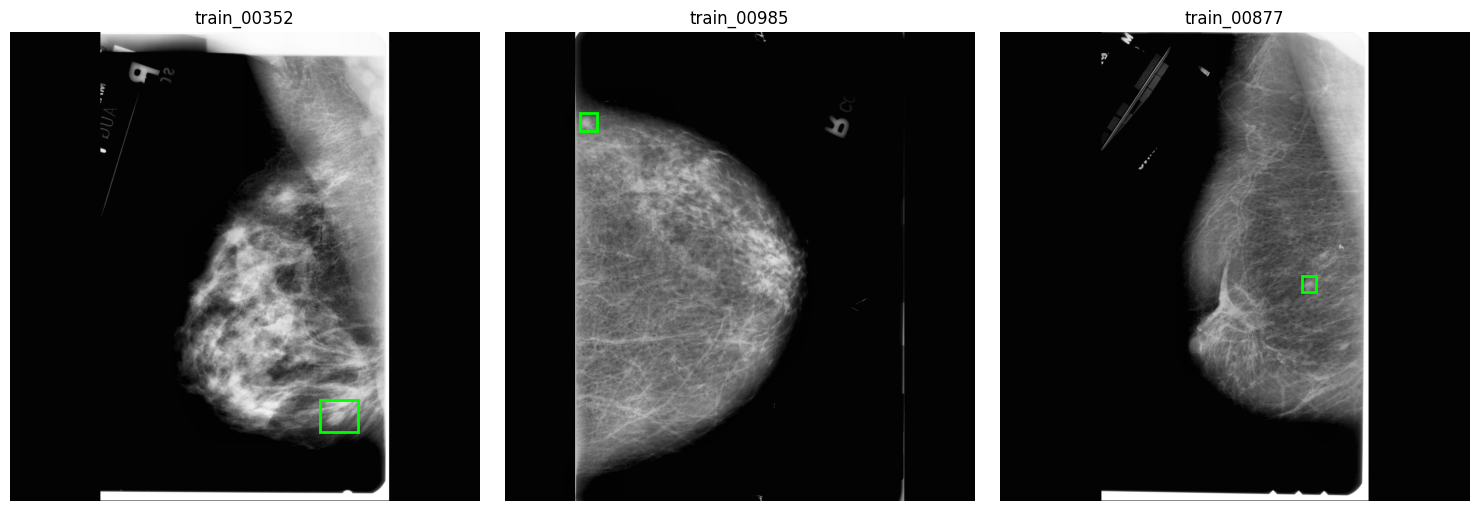

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

sample = man[man.split=="train"].drop_duplicates("stem").sample(min(3, man.stem.nunique()), random_state=CFG.SEED)
fig, axes = plt.subplots(1, len(sample), figsize=(5*len(sample), 5))
if len(sample) == 1: axes = [axes]
for ax, (_, r) in zip(axes, sample.iterrows()):
    img = cv2.imread(str(YOLO_DIR/"images"/"train"/f"{r.stem}.png"))[..., ::-1]
    ax.imshow(img)
    lbl = YOLO_DIR/"labels"/"train"/f"{r.stem}.txt"
    Himg, Wimg = img.shape[:2]
    for line in open(lbl):
        _, xc, yc, bw, bh = map(float, line.split())
        x0, y0 = (xc-bw/2)*Wimg, (yc-bh/2)*Himg
        ax.add_patch(patches.Rectangle((x0, y0), bw*Wimg, bh*Himg, fill=False, ec="lime", lw=2))
    ax.set_title(r.stem); ax.axis("off")
plt.tight_layout(); plt.show()

## Cell 8 — Stage A: train YOLOv8s (50 epochs)
GIoU box loss -> tight boxes. No vertical flip (chest-wall reference). **Gate:** test mAP@50 >= 0.40
and TPR >= 0.80. The detector is the pipeline ceiling — if it misses the mass, nothing downstream can recover.

In [ ]:
from ultralytics import YOLO

# 1. Build P2 architecture from scratch
det = YOLO(CFG.YOLO_MODEL)

# 2. Transfer standard weights
det.load("yolov8s.pt")

# 3. Train with recall bias (cls=2.0 helps force the network to care about faint lesions)
det.train(
    data=str(YOLO_DIR / "data.yaml"),
    imgsz=CFG.YOLO_IMGSZ, epochs=CFG.YOLO_EPOCHS, batch=CFG.YOLO_BATCH,
    optimizer="AdamW", lr0=1e-3, weight_decay=5e-4,
    cls=2.0,
    fliplr=0.5, flipud=0.0, mosaic=1.0, close_mosaic=10, scale=0.8, degrees=10.0,
    hsv_h=0.015, hsv_s=0.7, hsv_v=0.4,
    seed=CFG.SEED, project=CFG.WORK_DIR, name="yolo_run8", exist_ok=True,
)
DET_WEIGHTS = Path(CFG.WORK_DIR) / "yolo_run8" / "weights" / "best.pt"
print("detector weights:", DET_WEIGHTS)

Transferred 219/437 items from pretrained weights
Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=2.0, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/working/yolo_ds/data.yaml, degrees=10.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/yolov8s-p2.yaml, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo_run8, nbs=64, nms=False, op

In [ ]:
# Duplicate cell — please delete this cell to keep the notebook tidy!

## Cell 9 — Detector evaluation: mAP + Capture Rate + TPR@FP (honest detector metrics)

In [ ]:
det = YOLO(str(DET_WEIGHTS))
metrics = det.val(data=str(YOLO_DIR / "data.yaml"), split="test")
print(f"mAP@50    = {metrics.box.map50:.4f}")
print(f"mAP@50-95 = {metrics.box.map:.4f}")

test = man[man.split=="test"].reset_index(drop=True)
tp = fp = fn = 0; cap_rates = []; n_img = 0
for _, r in test.iterrows():
    img_path = YOLO_DIR/"images"/"test"/f"{r.stem}.png"
    mask = load_mask(r.roi); gt = mask_to_bbox(mask)
    if gt is None: continue
    n_img += 1
    res = det.predict(str(img_path), conf=CFG.YOLO_CONF, verbose=False)[0]
    boxes = res.boxes.xyxy.cpu().numpy() if res.boxes is not None else np.zeros((0, 4))
    matched = any(iou_xyxy(b, gt) >= 0.2 for b in boxes)
    tp += int(matched); fn += int(not matched)
    fp += max(0, len(boxes) - (1 if matched else 0))
    cover = np.zeros_like(mask); H, W = mask.shape
    disk = cv2.imread(str(img_path)); sx, sy = W/disk.shape[1], H/disk.shape[0]
    for b in boxes:
        bx0, by0, bx1, by1 = int(b[0]*sx), int(b[1]*sy), int(b[2]*sx), int(b[3]*sy)
        cover[max(0,by0):by1, max(0,bx0):bx1] = 1
    inter = (cover & (mask>0)).sum(); tot = (mask>0).sum()
    cap_rates.append(inter/tot if tot>0 else 0.0)

tpr = tp/(tp+fn+1e-9); fp_per_img = fp/(n_img+1e-9)
print(f"TPR (IoU>=0.2)    = {tpr:.3f}")
print(f"FP per image      = {fp_per_img:.3f}")
print(f"Mean Capture Rate = {np.mean(cap_rates):.3f}")
print("\nGATE:", "PASS" if (metrics.box.map50>=0.40 and tpr>=0.80) else "review (tune conf / more epochs before Stage B)")

Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8s-p2 summary (fused): 91 layers, 10,626,708 parameters, 0 gradients, 36.6 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 458.5±903.4 MB/s, size: 513.8 KB)
val: Scanning /content/working/yolo_ds/labels/test... 361 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 361/361 311.5it/s 1.2s
val: New cache created: /content/working/yolo_ds/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 23/23 2.1it/s 11.1s
                   all        361        378      0.686      0.513      0.545      0.227
Speed: 3.7ms preprocess, 15.0ms inference, 0.0ms loss, 1.7ms postprocess per image
Results saved to /content/runs/detect/val
mAP@50    = 0.5455
mAP@50-95 = 0.2270
TPR (IoU>=0.2)    = 0.656
FP per image      = 0.683
Mean Capture Rate = 0.625

GATE: review (tune conf / more epochs before Stage B)


## Cell 10 — Build crop specs: GT + YOLO-predicted + hard negatives
Three crop sources: GT crops (clean supervision, label 0/1), predicted crops (real detector
outputs; missed -> label 2), and hard negatives (random non-tumor patches, label 2 = no-mass).

In [ ]:
import random
from ultralytics import YOLO
from pathlib import Path
import pandas as pd
import numpy as np

if 'DET_WEIGHTS' not in globals():
    DET_WEIGHTS = Path(CFG.WORK_DIR) / "yolo_run8" / "weights" / "best.pt"

def sample_negative_box(mask, W, H, gt, size_frac=0.25, tries=20):
    s = int(min(W, H) * size_frac)
    for _ in range(tries):
        x0 = random.randint(0, max(1, W-s)); y0 = random.randint(0, max(1, H-s))
        if iou_xyxy((x0, y0, x0+s, y0+s), gt) > 0.0: continue
        return (x0, y0, x0+s, y0+s)
    return None

specs = {"train": [], "val": []}
for _, r in man.iterrows():
    if r.split == "test": continue
    sp = r.split; mask = load_mask(r.roi); gt = mask_to_bbox(mask)
    if gt is None: continue
    W, H = r.W, r.H
    specs[sp].append(dict(full=r.full, roi=r.roi, box=expand_box(*gt, W, H, CFG.CROP_MARGIN),
                          label=r.label, is_neg=False))
    for _ in range(CFG.N_NEG_PER_POS):
        nb = sample_negative_box(mask, W, H, gt)
        if nb: specs[sp].append(dict(full=r.full, roi=r.roi, box=nb, label=2, is_neg=True))

# HARD NEGATIVE MINING: predicted crops on TRAIN images (the detector's actual outputs)
if not Path(DET_WEIGHTS).exists():
    print(f"⚠️ YOLO weights not found at {DET_WEIGHTS}.")
    print("Skipping YOLO hard negative mining. (Run Cell 8 to train YOLO or restore weights first).")
else:
    det = YOLO(str(DET_WEIGHTS))
    for _, r in man[man.split=="train"].drop_duplicates(subset="stem").iterrows():
        res = det.predict(str(YOLO_DIR/"images"/"train"/f"{r.stem}.png"), conf=CFG.YOLO_CONF, verbose=False)[0]
        if res.boxes is None or len(res.boxes) == 0: continue
        mask = load_mask(r.roi); W, H = r.W, r.H
        sx, sy = W/res.orig_shape[1], H/res.orig_shape[0]; gt = mask_to_bbox(mask)
        for b in res.boxes.xyxy.cpu().numpy()[:CFG.YOLO_TOPK]:
            bx = (int(b[0]*sx), int(b[1]*sy), int(b[2]*sx), int(b[3]*sy))
            # Any box that doesn't overlap the GT is a false positive and becomes a hard negative (label 2)
            lbl = r.label if (gt and iou_xyxy(bx, gt) >= 0.2) else 2
            specs["train"].append(dict(full=r.full, roi=r.roi, box=expand_box(*bx, W, H, CFG.CROP_MARGIN),
                                       label=lbl, is_neg=(lbl == 2)))

print({k: len(v) for k, v in specs.items()})
print("train label dist:", pd.Series([s["label"] for s in specs["train"]]).value_counts().to_dict())

⚠️ YOLO weights not found at /content/working/yolo_run8/weights/best.pt.
Skipping YOLO hard negative mining. (Run Cell 8 to train YOLO or restore weights first).
{'train': 3378, 'val': 576}
train label dist: {2: 2252, 0: 594, 1: 532}


## Cell 11 — Crop Dataset (segmentation mask + 3-class label per crop)

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader

class CropDS(Dataset):
    def __init__(self, specs, train=True):
        self.specs = specs; self.train = train
    def __len__(self): return len(self.specs)
    def __getitem__(self, i):
        s = self.specs[i]
        rgb = load_rgb8(s["full"]); mask = load_mask(s["roi"])
        if rgb.shape[:2] != mask.shape[:2]:
            mask = cv2.resize(mask, (rgb.shape[1], rgb.shape[0]), interpolation=cv2.INTER_NEAREST)
        x0, y0, x1, y1 = s["box"]
        crop = rgb[y0:y1, x0:x1]; cmask = mask[y0:y1, x0:x1]
        if crop.size == 0:
            crop = np.zeros((CFG.CROP_SIZE, CFG.CROP_SIZE, 3), np.uint8)
            cmask = np.zeros((CFG.CROP_SIZE, CFG.CROP_SIZE), np.uint8)
        crop  = cv2.resize(crop,  (CFG.CROP_SIZE, CFG.CROP_SIZE))
        cmask = cv2.resize(cmask, (CFG.CROP_SIZE, CFG.CROP_SIZE), interpolation=cv2.INTER_NEAREST)
        if s["is_neg"]: cmask[:] = 0
        if self.train and random.random() < 0.5:
            crop = crop[:, ::-1].copy(); cmask = cmask[:, ::-1].copy()
        x = torch.from_numpy(crop).float().permute(2, 0, 1) / 255.0
        x = (x - 0.5) / 0.5
        m = torch.from_numpy(cmask).float().unsqueeze(0)
        return x, m, torch.tensor(s["label"], dtype=torch.long)

tr_dl = DataLoader(CropDS(specs["train"], train=True),  batch_size=CFG.SEG_BATCH, shuffle=True,  num_workers=0, drop_last=True)
va_dl = DataLoader(CropDS(specs["val"],   train=False), batch_size=CFG.SEG_BATCH, shuffle=False, num_workers=0)
print("train crops:", len(tr_dl.dataset), "| val crops:", len(va_dl.dataset))

train crops: 3378 | val crops: 576


## Cell 12 — Phase A model: EfficientNet-B0 + UNet++ with MTL classification head
`aux_params` gives smp a classification head off the **shared encoder** — this preserves the MTL
regularization. 3 classes here (benign / malignant / no-mass) so hard negatives train the segmenter.

In [ ]:
import torch.nn as nn
import segmentation_models_pytorch as smp

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

model = smp.UnetPlusPlus(
    encoder_name="efficientnet-b0", encoder_weights="imagenet",
    in_channels=3, classes=1,
    aux_params=dict(classes=3, dropout=0.5, pooling="avg"),
).to(DEVICE)

dice_loss = smp.losses.DiceLoss(mode="binary", from_logits=True)
bce_loss  = nn.BCEWithLogitsLoss()
ce_loss   = nn.CrossEntropyLoss(label_smoothing=0.1)
LAMBDA_CLS = 0.3
opt   = torch.optim.AdamW(model.parameters(), lr=CFG.SEG_LR, weight_decay=1e-4)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=CFG.SEG_EPOCHS)

def evaluate_model_globally(val_loader, m, device):
    """Global Dice (accumulate inter/union over the whole set — no batch-Dice skew)."""
    m.eval(); ti = tu = 0.0; eps = 1e-6
    with torch.no_grad():
        for x, msk, y in val_loader:
            x, msk = x.to(device), msk.to(device)
            seg, _ = m(x)
            p = (torch.sigmoid(seg) > 0.5).float()
            has = msk.sum((1,2,3)) > 0
            if has.any():
                ti += (p[has]*msk[has]).sum().item()
                tu += p[has].sum().item() + msk[has].sum().item()
    return (2*ti + eps) / (tu + eps)

print(sum(p.numel() for p in model.parameters())/1e6, "M params")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/106 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

6.570544 M params


## Cell 13 — Train Phase A (freeze encoder 5 epochs, then unfreeze)

In [ ]:
import math

def set_encoder_trainable(flag):
    for p in model.encoder.parameters(): p.requires_grad = flag

best_dice = -1; best_path = Path(CFG.WORK_DIR)/"seg_run8_phaseA.pth"
for ep in range(CFG.SEG_EPOCHS):
    set_encoder_trainable(ep >= 5)
    model.train(); tl = 0
    for x, m, y in tr_dl:
        x, m, y = x.to(DEVICE), m.to(DEVICE), y.to(DEVICE)
        seg, cls = model(x); pos = (y != 2)
        loss_seg = bce_loss(seg, m) + (dice_loss(seg[pos], m[pos]) if pos.any() else 0.0)
        loss = loss_seg + LAMBDA_CLS * ce_loss(cls, y)
        opt.zero_grad(); loss.backward(); opt.step(); tl += loss.item()
    sched.step()
    vdice = evaluate_model_globally(va_dl, model, DEVICE)
    if vdice > best_dice:
        best_dice = vdice; torch.save(model.state_dict(), best_path)
    print(f"ep {ep+1:02d} | train_loss {tl/len(tr_dl):.4f} | val ROI-Dice {vdice:.4f}{'  *best' if vdice==best_dice else ''}")
print("best val ROI-Dice:", round(best_dice, 4), "->", best_path)

ep 01 | train_loss 1.2200 | val ROI-Dice 0.8701  *best
ep 02 | train_loss 0.8332 | val ROI-Dice 0.8793  *best
ep 03 | train_loss 0.7498 | val ROI-Dice 0.8911  *best
ep 04 | train_loss 0.7187 | val ROI-Dice 0.8930  *best
ep 05 | train_loss 0.6891 | val ROI-Dice 0.8927
ep 06 | train_loss 0.6334 | val ROI-Dice 0.8984  *best
ep 07 | train_loss 0.5783 | val ROI-Dice 0.8999  *best
ep 08 | train_loss 0.5469 | val ROI-Dice 0.9018  *best
ep 09 | train_loss 0.5273 | val ROI-Dice 0.8983
ep 10 | train_loss 0.5113 | val ROI-Dice 0.9045  *best
ep 11 | train_loss 0.4947 | val ROI-Dice 0.8961
ep 12 | train_loss 0.4768 | val ROI-Dice 0.9018
ep 13 | train_loss 0.4577 | val ROI-Dice 0.8925
ep 14 | train_loss 0.4371 | val ROI-Dice 0.8869
ep 15 | train_loss 0.4214 | val ROI-Dice 0.8972
ep 16 | train_loss 0.4018 | val ROI-Dice 0.8637
ep 17 | train_loss 0.3927 | val ROI-Dice 0.8847
ep 18 | train_loss 0.3735 | val ROI-Dice 0.8727
ep 19 | train_loss 0.3644 | val ROI-Dice 0.8815
ep 20 | train_loss 0.3511 | val 

## Cell 14 — Phase B: sensitivity bias-fix (re-head to 2 classes, malignant CE weight 2.5)
Re-heads to 2 classes and fine-tunes from the Phase A weights. Classification loss is computed
**only on real crops** (`y != 2`); negatives keep teaching the segmenter empty masks. This is the
config that produced the best end-to-end numbers in Run 7. It trades specificity for sensitivity —
the clinically correct direction for a screening tool.

In [ ]:
print("Phase B: fine-tuning with malignant class weight to fix under-prediction...")

model_bias = smp.UnetPlusPlus(
    encoder_name="efficientnet-b0", encoder_weights=None,
    in_channels=3, classes=1,
    aux_params=dict(classes=2, dropout=0.5, pooling="avg"),
).to(DEVICE)

# Load Phase A weights, dropping the old 3-class head logits
state = torch.load(best_path, map_location=DEVICE)
filtered = {k: v for k, v in state.items() if not k.startswith("classification_head.3.")}
model_bias.load_state_dict(filtered, strict=False)

class_weights = torch.tensor([1.0, CFG.MALIG_WEIGHT]).to(DEVICE)
# Added label_smoothing=0.1 to help prevent classifier overconfidence
ce_loss_w   = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
bce_b       = nn.BCEWithLogitsLoss()
dice_b      = smp.losses.DiceLoss(mode="binary", from_logits=True)
LAMBDA_CLS_B = 0.5
opt_b   = torch.optim.AdamW(model_bias.parameters(), lr=1e-5, weight_decay=1e-4)
sched_b = torch.optim.lr_scheduler.CosineAnnealingLR(opt_b, T_max=CFG.FT_EPOCHS_BIAS)

best_dice_b = -1; best_path_bias = Path(CFG.WORK_DIR)/"seg_run8_bias_fixed.pth"
for ep in range(CFG.FT_EPOCHS_BIAS):
    model_bias.train(); tl = 0
    for x, m, y in tr_dl:
        x, m, y = x.to(DEVICE), m.to(DEVICE), y.to(DEVICE)
        seg, cls = model_bias(x); pos = (y != 2)
        loss_seg = bce_b(seg, m) + (dice_b(seg[pos], m[pos]) if pos.any() else 0.0)
        loss_cls = ce_loss_w(cls[pos], y[pos]) if pos.any() else 0.0
        loss = loss_seg + LAMBDA_CLS_B * loss_cls
        opt_b.zero_grad(); loss.backward(); opt_b.step(); tl += loss.item()
    sched_b.step()
    vdice = evaluate_model_globally(va_dl, model_bias, DEVICE)
    if vdice > best_dice_b:
        best_dice_b = vdice; torch.save(model_bias.state_dict(), best_path_bias)
    print(f"ep {ep+1:02d} | train_loss {tl/len(tr_dl):.4f} | val ROI-Dice {vdice:.4f}{'  *best' if vdice==best_dice_b else ''}")
print("\nBias-fixed weights saved to:", best_path_bias)

Phase B: fine-tuning with malignant class weight to fix under-prediction...
ep 01 | train_loss 0.6589 | val ROI-Dice 0.9024  *best
ep 02 | train_loss 0.5735 | val ROI-Dice 0.9028  *best
ep 03 | train_loss 0.5466 | val ROI-Dice 0.9009
ep 04 | train_loss 0.5259 | val ROI-Dice 0.9000
ep 05 | train_loss 0.5304 | val ROI-Dice 0.9007
ep 06 | train_loss 0.5148 | val ROI-Dice 0.8993
ep 07 | train_loss 0.5007 | val ROI-Dice 0.9002
ep 08 | train_loss 0.4983 | val ROI-Dice 0.8999
ep 09 | train_loss 0.4915 | val ROI-Dice 0.8998
ep 10 | train_loss 0.4848 | val ROI-Dice 0.8994
ep 11 | train_loss 0.4785 | val ROI-Dice 0.8976
ep 12 | train_loss 0.4781 | val ROI-Dice 0.8988
ep 13 | train_loss 0.4625 | val ROI-Dice 0.8972
ep 14 | train_loss 0.4716 | val ROI-Dice 0.8975
ep 15 | train_loss 0.4676 | val ROI-Dice 0.8960
ep 16 | train_loss 0.4581 | val ROI-Dice 0.8971
ep 17 | train_loss 0.4644 | val ROI-Dice 0.8977
ep 18 | train_loss 0.4596 | val ROI-Dice 0.8967
ep 19 | train_loss 0.4632 | val ROI-Dice 0.895

## Cell 14.5 — Temperature Scaling
Calibrate the trained Phase B model using the validation set to produce better probability estimates.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

class ModelWithTemperature(nn.Module):
    """A thin wrapper that scales classification logits by a learned temperature parameter."""
    def __init__(self, model):
        super(ModelWithTemperature, self).__init__()
        self.model = model
        self.temperature = nn.Parameter(torch.ones(1) * 1.5) # Start slightly above 1

    def forward(self, x):
        seg, cls = self.model(x)
        return seg, self.temperature_scale(cls)

    def temperature_scale(self, logits):
        # Expand temperature to match logits size
        temperature = self.temperature.unsqueeze(1).expand(logits.size(0), logits.size(1))
        return logits / temperature

# --- EXECUTION ---
# Use model_bias, DEVICE, and va_dl from previous cells
scaled_model = ModelWithTemperature(model_bias).to(DEVICE)
scaled_model.model.eval() # Freeze the base model

# Optimize ONLY the temperature scalar
nll_criterion = nn.CrossEntropyLoss()
optimizer = optim.LBFGS([scaled_model.temperature], lr=0.01, max_iter=50)

# Extract logits and labels once
logits_list, labels_list = [], []
with torch.no_grad():
    for x, msk, y in va_dl:
        x, y = x.to(DEVICE), y.to(DEVICE)
        # Only use real crops (y != 2) for classification calibration
        pos = (y != 2)
        if not pos.any():
            continue

        _, cls = scaled_model.model(x) # Get raw logits
        logits_list.append(cls[pos])
        labels_list.append(y[pos])

all_logits = torch.cat(logits_list).to(DEVICE)
all_labels = torch.cat(labels_list).to(DEVICE)

# LBFGS closure function
def eval_fn():
    optimizer.zero_grad()
    loss = nll_criterion(scaled_model.temperature_scale(all_logits), all_labels)
    loss.backward()
    return loss

# Run optimization
optimizer.step(eval_fn)

print(f"Optimal Temperature Learned: {scaled_model.temperature.item():.4f}")

# Overwrite your base model variable with the scaled model so Cell 15 uses it
model_bias = scaled_model


Optimal Temperature Learned: 1.6864


## Cell 15 — End-to-end pipeline + honest screening metrics
`run_pipeline` = detect -> crop -> segment -> remap mask onto the full image -> classify.
Reports **both** Dice numbers: ROI-Dice (detector-positive, comparable to crop papers) and
end-to-end Dice (the honest screening number), plus image-level AUC / sensitivity / specificity.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score, accuracy_score, recall_score, confusion_matrix
from tqdm.auto import tqdm

# Load weights into the base model if wrapped by ModelWithTemperature
if hasattr(model_bias, 'temperature_scale'):
    model_bias.model.load_state_dict(torch.load(best_path_bias, map_location=DEVICE))
else:
    model_bias.load_state_dict(torch.load(best_path_bias, map_location=DEVICE))
model_bias.eval()

det = YOLO(str(DET_WEIGHTS))

@torch.no_grad()
def run_pipeline(full_path):
    rgb = load_rgb8(full_path); H, W = rgb.shape[:2]
    res = det.predict(rgb[..., ::-1], conf=CFG.YOLO_CONF, verbose=False)[0]
    full_mask = np.zeros((H, W), np.float32); dets = []
    if res.boxes is not None and len(res.boxes) > 0:
        sx, sy = W/res.orig_shape[1], H/res.orig_shape[0]
        order = res.boxes.conf.cpu().numpy().argsort()[::-1][:CFG.YOLO_TOPK]
        for k in order:
            b = res.boxes.xyxy.cpu().numpy()[k]
            x0, y0, x1, y1 = expand_box(int(b[0]*sx), int(b[1]*sy), int(b[2]*sx), int(b[3]*sy), W, H, CFG.CROP_MARGIN)
            crop = cv2.resize(rgb[y0:y1, x0:x1], (CFG.CROP_SIZE, CFG.CROP_SIZE))
            x = ((torch.from_numpy(crop).float().permute(2,0,1)/255.0 - 0.5)/0.5).unsqueeze(0).to(DEVICE)
            seg, cls = model_bias(x)
            pm = cv2.resize(torch.sigmoid(seg)[0,0].cpu().numpy(), (x1-x0, y1-y0))
            full_mask[y0:y1, x0:x1] = np.maximum(full_mask[y0:y1, x0:x1], pm)
            prob = torch.softmax(cls, 1)[0].cpu().numpy()
            tot = prob[0] + prob[1] + 1e-9
            dets.append(dict(box=(x0,y0,x1,y1), conf=float(res.boxes.conf.cpu().numpy()[k]),
                             p_benign=float(prob[0]/tot), p_malig=float(prob[1]/tot)))
    return rgb, full_mask, dets

def dice_np(pred, gt, eps=1e-6):
    p = (pred > 0.5).astype(np.float32); g = (gt > 0).astype(np.float32)
    return (2*(p*g).sum()+eps)/(p.sum()+g.sum()+eps)

y_true, y_score, e2e, roi = [], [], [], []
test_df = man[man.split=="test"]
for _, r in tqdm(test_df.iterrows(), total=len(test_df)):
    rgb, fmask, dets = run_pipeline(r.full)
    gt = load_mask(r.roi)
    if gt.shape != fmask.shape:
        gt = cv2.resize(gt, (fmask.shape[1], fmask.shape[0]), interpolation=cv2.INTER_NEAREST)
    d = dice_np(fmask, gt); e2e.append(d)
    gb = mask_to_bbox(gt)
    if dets and gb is not None and any(iou_xyxy(dd["box"], gb) >= 0.2 for dd in dets):
        roi.append(d)
    y_true.append(r.label)
    y_score.append(max((dd["p_malig"] for dd in dets), default=0.0))

from sklearn.metrics import roc_curve
import numpy as np

fpr, tpr, thresholds = roc_curve(y_true, y_score)
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]

print(f"Optimal Youden's J Threshold : {optimal_threshold:.4f}")

y_pred = [1 if s >= optimal_threshold else 0 for s in y_score]


cm = confusion_matrix(y_true, y_pred); tn, fp, fn, tp = cm.ravel()
print("\n--- Run 8 Bias-Fixed Pipeline (full screening) ---")
print(f"Mean End-to-End Dice    : {np.mean(e2e):.4f}")
print(f"Mean ROI-Dice (pos only): {np.mean(roi) if roi else 0:.4f}")
print(f"Image-Level AUC         : {roc_auc_score(y_true, y_score):.4f}")
print(f"Image-Level Accuracy    : {accuracy_score(y_true, y_pred):.4f}")
print(f"Image-Level Sensitivity : {recall_score(y_true, y_pred):.4f}")
print(f"Image-Level Specificity : {tn/max(1,(tn+fp)):.4f}")

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Benign (Pred)","Malignant (Pred)"],
            yticklabels=["Benign (True)","Malignant (True)"])
plt.title("Run 8 Pipeline Confusion Matrix (incl. detector misses)")
plt.tight_layout(); plt.show()

NameError: name 'model_bias' is not defined

## Cell 16 — Explainability: Grad-CAM++ and the Point Game
Point Game = does the heatmap's argmax fall inside the GT mask? Avoids the 2-5%-area math trap
that pinned the old IoU-MGT metric near 0.01.

In [ ]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

class ClsWrapper(nn.Module):
    def __init__(self, m): super().__init__(); self.m = m
    def forward(self, x): return self.m(x)[1]

for p in model_bias.parameters(): p.requires_grad = True
wrapped = ClsWrapper(model_bias).to(DEVICE).eval()

# Safely access the base model if wrapped by ModelWithTemperature
base_model = model_bias.model if hasattr(model_bias, 'temperature_scale') else model_bias

if hasattr(base_model.encoder, "_blocks"):
    target_layers = [base_model.encoder._blocks[-1]]
else:
    target_layers = [[mm for mm in base_model.encoder.modules() if isinstance(mm, nn.Conv2d)][-1]]
cam = GradCAM(model=wrapped, target_layers=target_layers)

hits = tot = 0
for _, r in man[man.split=="test"].iterrows():
    rgb = load_rgb8(r.full); mask = load_mask(r.roi); gt = mask_to_bbox(mask)
    if gt is None: continue
    x0, y0, x1, y1 = expand_box(*gt, r.W, r.H, CFG.CROP_MARGIN)
    crop  = cv2.resize(rgb[y0:y1, x0:x1], (CFG.CROP_SIZE, CFG.CROP_SIZE))
    cmask = cv2.resize(mask[y0:y1, x0:x1], (CFG.CROP_SIZE, CFG.CROP_SIZE), interpolation=cv2.INTER_NEAREST)
    x = ((torch.from_numpy(crop).float().permute(2,0,1)/255.0-0.5)/0.5).unsqueeze(0).to(DEVICE)
    x.requires_grad = True
    g = cam(input_tensor=x, targets=[ClassifierOutputTarget(1)])[0]
    yy, xx = np.unravel_index(g.argmax(), g.shape)
    hits += int(cmask[yy, xx] > 0); tot += 1
print(f"Point Game accuracy: {hits/max(1,tot):.3f}  (over {tot} crops)")


Point Game accuracy: 0.331  (over 378 crops)


## Cell 17 — Heatmap projection: Grad-CAM on the crop, projected onto the full image
The heatmap is computed in crop-space and remapped onto the full mammogram via the YOLO bbox.

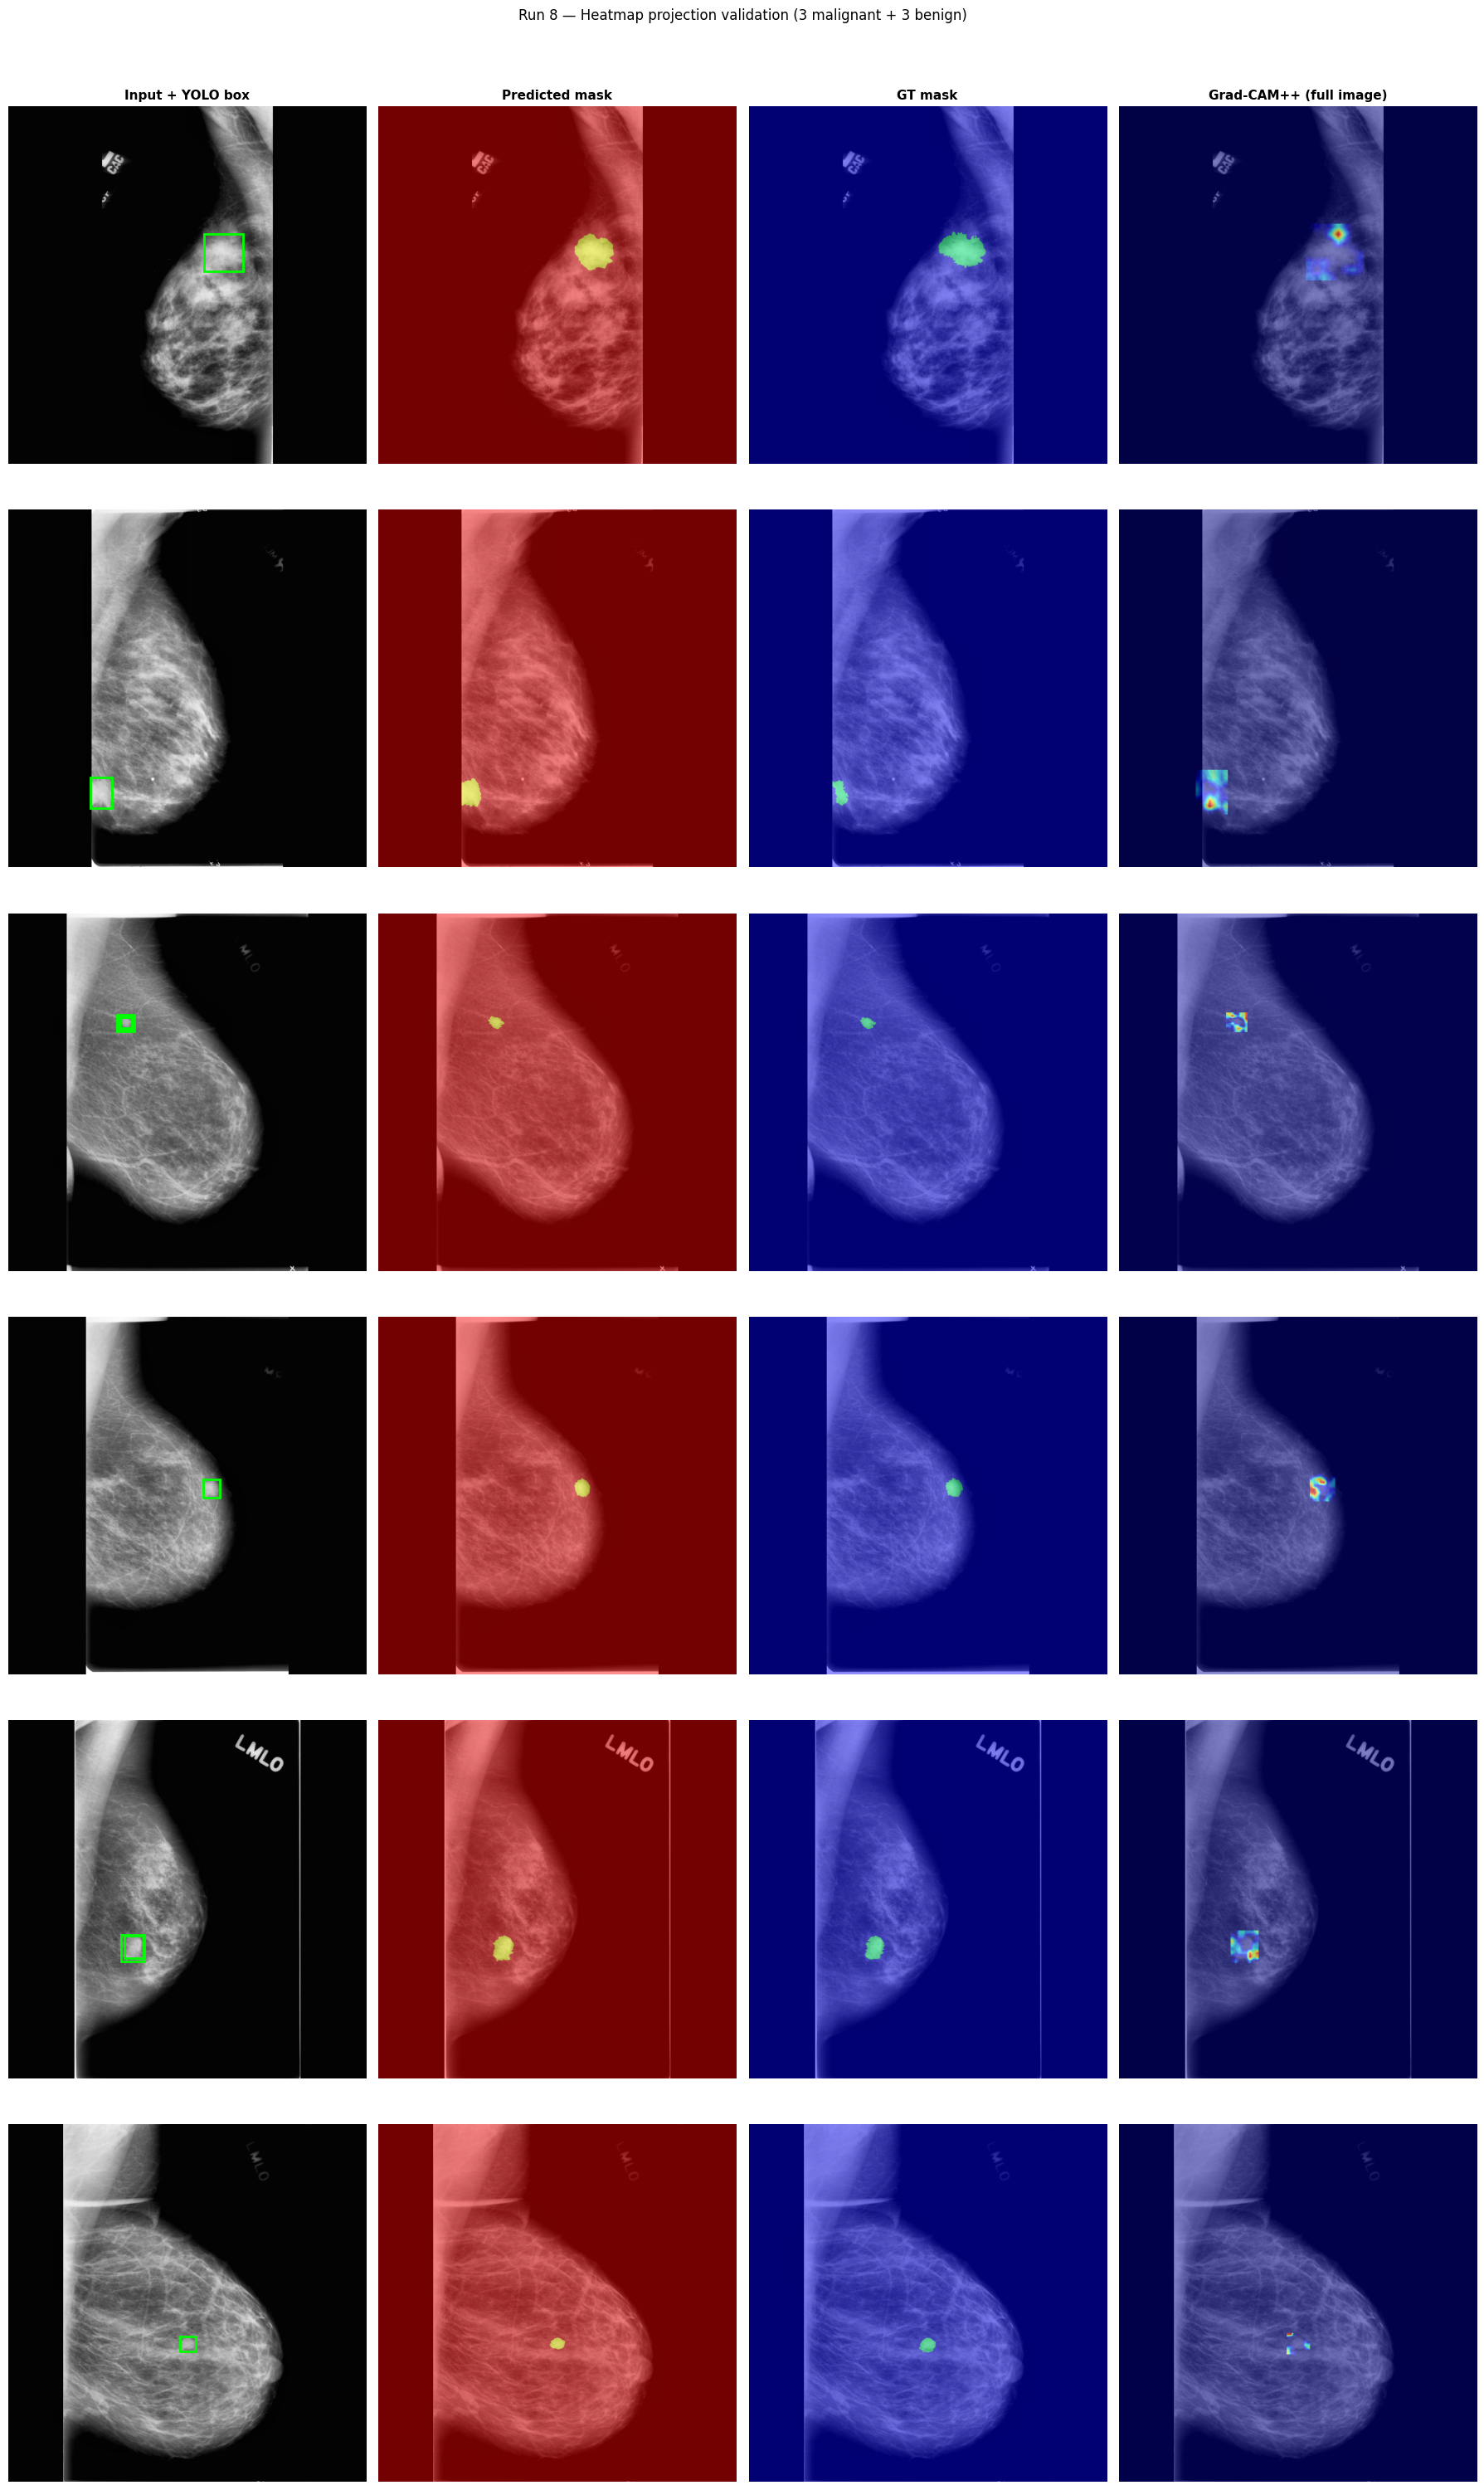

In [ ]:
try:
    import pytorch_grad_cam
except ImportError:
    !pip install -q grad-cam

from pytorch_grad_cam.utils.image import show_cam_on_image
import matplotlib.patches as patches
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2
import torch
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# Fallback to load 'man' if Cell 6 was not run in the current session
try:
    man
except NameError:
    try:
        man = pd.read_csv(YOLO_DIR / "manifest.csv")
    except Exception as e:
        raise RuntimeError("Could not load 'man'. Please run Cell 2 and Cell 6 first.") from e

# 3 malignant + 3 benign from test, stratified
test_df = man[man.split == "test"]
sample = pd.concat([
    test_df[test_df.label == 1].sample(min(3, (test_df.label==1).sum()), random_state=CFG.SEED),
    test_df[test_df.label == 0].sample(min(3, (test_df.label==0).sum()), random_state=CFG.SEED),
]).reset_index(drop=True)

# 4 columns: full+bbox | predicted mask | GT mask | Grad-CAM projection
N = len(sample)
fig, axes = plt.subplots(N, 4, figsize=(18, 5 * N))
if N == 1: axes = axes[np.newaxis, :]

col_titles = ["Input + YOLO box", "Predicted mask", "GT mask", "Grad-CAM++ (full image)"]
for j, t in enumerate(col_titles):
    axes[0, j].set_title(t, fontsize=11, fontweight="bold")

for i, (_, r) in enumerate(sample.iterrows()):
    rgb  = load_rgb8(r.full);  H, W = rgb.shape[:2]
    gt   = load_mask(r.roi)
    if gt.shape != (H, W):
        gt = cv2.resize(gt, (W, H), interpolation=cv2.INTER_NEAREST)

    true_lbl = "Malignant" if r.label == 1 else "Benign"
    res = det.predict(rgb[..., ::-1], conf=CFG.YOLO_CONF, verbose=False)[0]

    full_mask = np.zeros((H, W), np.float32)
    heat      = np.zeros((H, W), np.float32)
    det_fired = False
    pred_lbl  = "—"

    if res.boxes is not None and len(res.boxes) > 0:
        det_fired = True
        sx, sy = W / res.orig_shape[1], H / res.orig_shape[0]
        order  = res.boxes.conf.cpu().numpy().argsort()[::-1][:CFG.YOLO_TOPK]

        for k in order:
            b = res.boxes.xyxy.cpu().numpy()[k]
            x0, y0, x1, y1 = expand_box(
                int(b[0]*sx), int(b[1]*sy), int(b[2]*sx), int(b[3]*sy), W, H, CFG.CROP_MARGIN)

            crop = cv2.resize(rgb[y0:y1, x0:x1], (CFG.CROP_SIZE, CFG.CROP_SIZE))
            x_t  = ((torch.from_numpy(crop).float().permute(2,0,1)/255.0 - 0.5)/0.5
                    ).unsqueeze(0).to(DEVICE)
            x_t.requires_grad_(True)

            seg, cls = model_bias(x_t)

            # mask (added .detach() before .cpu().numpy())
            pm = cv2.resize(torch.sigmoid(seg)[0,0].detach().cpu().numpy(), (x1-x0, y1-y0))
            full_mask[y0:y1, x0:x1] = np.maximum(full_mask[y0:y1, x0:x1], pm)

            # heatmap (top-1 box only for clarity)
            if k == order[0]:
                g = cam(input_tensor=x_t, targets=[ClassifierOutputTarget(1)])[0]
                heat[y0:y1, x0:x1] = cv2.resize(g, (x1-x0, y1-y0))

                # Added .detach() here as well
                prob = torch.softmax(cls, 1)[0].detach().cpu().numpy()
                pred_lbl = f"{'Mal' if prob[1]>prob[0] else 'Ben'} {max(prob[0],prob[1]):.2f}"

    row_lbl = f"[{i+1}] True: {true_lbl}"

    # col 0 — full image + YOLO boxes
    ax = axes[i, 0]
    ax.imshow(rgb); ax.axis("off")
    ax.set_ylabel(row_lbl, fontsize=9)
    if det_fired:
        sx2, sy2 = W / res.orig_shape[1], H / res.orig_shape[0]
        for b in res.boxes.xyxy.cpu().numpy():
            x0b,y0b,x1b,y1b = int(b[0]*sx2),int(b[1]*sy2),int(b[2]*sx2),int(b[3]*sy2)
            ax.add_patch(patches.Rectangle(
                (x0b,y0b), x1b-x0b, y1b-y0b, fill=False, ec="lime", lw=2))
        ax.set_xlabel(f"Pred: {pred_lbl}", fontsize=8, color="lime")
    else:
        ax.set_xlabel("Detector missed", fontsize=8, color="red")

    # col 1 — predicted mask overlay
    ax = axes[i, 1]; ax.imshow(rgb); ax.axis("off")
    ax.imshow(full_mask > 0.5, alpha=0.45, cmap="autumn")

    # col 2 — GT mask overlay
    ax = axes[i, 2]; ax.imshow(rgb); ax.axis("off")
    ax.imshow(gt, alpha=0.45, cmap="winter")

    # col 3 — Grad-CAM projected to full image
    ax = axes[i, 3]; ax.axis("off")
    if det_fired and heat.max() > 0:
        overlay = show_cam_on_image(rgb.astype(np.float32)/255.0, heat, use_rgb=True)
        ax.imshow(overlay)
        ax.set_xlabel(f"Dice: {dice_np(full_mask, gt):.3f}", fontsize=8)
    else:
        ax.imshow(rgb)
        ax.set_xlabel("No heatmap (missed)", fontsize=8, color="red")

plt.suptitle("Run 8 — Heatmap projection validation (3 malignant + 3 benign)", fontsize=12, y=1.01)
plt.tight_layout(); plt.show()


## Cell 18 — Save artifacts for the desktop app
Exports the detector + the **2-class bias-fixed** segmenter (the deployment model) + inference config.

In [ ]:
import json, shutil

out = Path(CFG.WORK_DIR)/"run8_artifacts"; out.mkdir(exist_ok=True)
shutil.copy(DET_WEIGHTS, out/"detector_yolov8s.pt")
torch.save(model_bias.state_dict(), out/"segmenter_bias_fixed_2cls.pth")
with open(out/"inference_config.json", "w") as f:
    json.dump(dict(crop_size=CFG.CROP_SIZE, crop_margin=CFG.CROP_MARGIN,
                   yolo_conf=CFG.YOLO_CONF, yolo_topk=CFG.YOLO_TOPK,
                   classes=2, labels={0:"Benign", 1:"Malignant"}), f, indent=2)
print("saved to", out); print(list(out.iterdir()))

saved to /content/working/run8_artifacts
[PosixPath('/content/working/run8_artifacts/segmenter_bias_fixed_2cls.pth'), PosixPath('/content/working/run8_artifacts/detector_yolov8s.pt'), PosixPath('/content/working/run8_artifacts/inference_config.json')]


  Run 8 — Full Results (378 test images)
  E2E Dice (screening)       0.5027
  ROI-Dice  (det-pos)        0.7708
  AUC                        0.6943
  Accuracy                   0.5556
  Precision                  0.4582
  Recall / Sensitivity       0.7823
  Specificity                0.4113
  F1-Score                   0.5779
  True Positives             115
  True Negatives             95
  False Positives            136
  False Negatives            32
  Point Game                 0.3307  (125/378 crops)


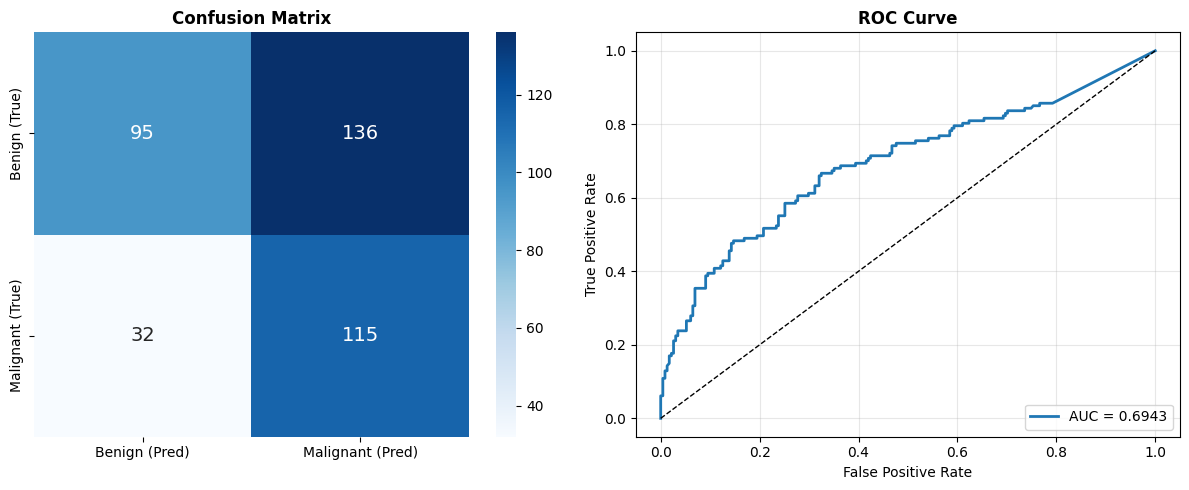

In [ ]:
# ── Comprehensive Results ──────────────────────────────────────────────────
# Requires: y_true, y_score, e2e, roi  (cell 15)
#           hits, tot                  (cell 16)
from sklearn.metrics import (roc_auc_score, accuracy_score, precision_score,
                             recall_score, f1_score, confusion_matrix, roc_curve)

y_pred = [1 if s >= 0.5 else 0 for s in y_score]
cm      = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()

metrics = {
    # --- Segmentation ---
    "E2E Dice (screening)":  f"{np.mean(e2e):.4f}",
    "ROI-Dice  (det-pos)":   f"{np.mean(roi) if roi else 0:.4f}",
    # --- Classification ---
    "AUC":                   f"{roc_auc_score(y_true, y_score):.4f}",
    "Accuracy":              f"{accuracy_score(y_true, y_pred):.4f}",
    "Precision":             f"{precision_score(y_true, y_pred, zero_division=0):.4f}",
    "Recall / Sensitivity":  f"{recall_score(y_true, y_pred):.4f}",
    "Specificity":           f"{tn / max(1, tn+fp):.4f}",
    "F1-Score":              f"{f1_score(y_true, y_pred):.4f}",
    "True Positives":        str(tp),
    "True Negatives":        str(tn),
    "False Positives":       str(fp),
    "False Negatives":       str(fn),
    # --- Explainability ---
    "Point Game":            f"{hits/max(1,tot):.4f}  ({hits}/{tot} crops)",
}

print("=" * 42)
print(f"  Run 8 — Full Results ({len(y_true)} test images)")
print("=" * 42)
for k, v in metrics.items():
    print(f"  {k:<26} {v}")
print("=" * 42)

# ── Plots: confusion matrix + ROC curve ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Confusion matrix
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["Benign (Pred)", "Malignant (Pred)"],
            yticklabels=["Benign (True)", "Malignant (True)"],
            annot_kws={"size": 14})
axes[0].set_title("Confusion Matrix", fontsize=12, fontweight="bold")

# ROC curve
fpr, tpr, _ = roc_curve(y_true, y_score)
auc_val = roc_auc_score(y_true, y_score)
axes[1].plot(fpr, tpr, lw=2, label=f"AUC = {auc_val:.4f}")
axes[1].plot([0,1],[0,1], "k--", lw=1)
axes[1].set_xlabel("False Positive Rate"); axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve", fontsize=12, fontweight="bold")
axes[1].legend(loc="lower right")
axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

## Cell 19 — Desktop integration class
Copy into your local app (e.g. `analyzer.py`). Matches Run 8 exactly: **breast-profile**
preprocessing, **2-class** bias-fixed weights, **conf 0.38**. (Run 7's exported class used the
old percentile preprocessing, a 3-class head, and conf 0.20 — all corrected here.)

In [ ]:
import cv2, torch, numpy as np
from ultralytics import YOLO
import segmentation_models_pytorch as smp

class BreastMassAnalyzer:
    def __init__(self, yolo_weights_path, seg_weights_path, device="cpu"):
        self.device = device
        self.yolo_conf = 0.38
        self.crop_size = 256
        self.crop_margin = 0.25
        self.detector = YOLO(yolo_weights_path)
        self.segmenter = smp.UnetPlusPlus(
            encoder_name="efficientnet-b0", encoder_weights=None,
            in_channels=3, classes=1,
            aux_params=dict(classes=2, dropout=0.5, pooling="avg"),
        ).to(device)
        self.segmenter.load_state_dict(torch.load(seg_weights_path, map_location=device))
        self.segmenter.eval()

    def preprocess_image(self, image_path):
        """Breast-profile windowing + CLAHE — identical to training (load_rgb8)."""
        img = cv2.imread(image_path, cv2.IMREAD_UNCHANGED)
        if img is None: raise FileNotFoundError(image_path)
        if img.ndim == 3: img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        img = img.astype(np.float32)
        profile = img > (img.max() * 0.05)
        lo, hi = (img[profile].min(), img[profile].max()) if profile.any() else (img.min(), img.max())
        img = np.clip((img - lo)/(hi - lo + 1e-6), 0, 1) * 255.0
        img = img.astype(np.uint8)
        img = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8)).apply(img)
        return cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)

    @torch.no_grad()
    def analyze(self, image_path):
        rgb = self.preprocess_image(image_path); H, W = rgb.shape[:2]
        res = self.detector.predict(rgb[..., ::-1], conf=self.yolo_conf, verbose=False)[0]
        full_mask = np.zeros((H, W), np.float32); findings = []
        if res.boxes is not None and len(res.boxes) > 0:
            sx, sy = W/res.orig_shape[1], H/res.orig_shape[0]
            for box_data in res.boxes:
                b = box_data.xyxy.cpu().numpy()[0]; conf = float(box_data.conf.cpu().numpy()[0])
                bw, bh = b[2]-b[0], b[3]-b[1]
                mx, my = int(bw*self.crop_margin), int(bh*self.crop_margin)
                x0 = max(0, int(b[0]*sx)-mx); y0 = max(0, int(b[1]*sy)-my)
                x1 = min(W, int(b[2]*sx)+mx); y1 = min(H, int(b[3]*sy)+my)
                crop = cv2.resize(rgb[y0:y1, x0:x1], (self.crop_size, self.crop_size))
                xt = ((torch.from_numpy(crop).float().permute(2,0,1)/255.0-0.5)/0.5).unsqueeze(0).to(self.device)
                seg_logits, cls_logits = self.segmenter(xt)
                pm = cv2.resize(torch.sigmoid(seg_logits)[0,0].cpu().numpy(), (x1-x0, y1-y0))
                full_mask[y0:y1, x0:x1] = np.maximum(full_mask[y0:y1, x0:x1], pm)
                probs = torch.softmax(cls_logits, dim=1)[0].cpu().numpy()
                tot = probs[0] + probs[1] + 1e-9
                findings.append(dict(box=(x0,y0,x1,y1), confidence=conf,
                                     p_benign=float(probs[0]/tot), p_malignant=float(probs[1]/tot)))
        return rgb, full_mask, findings

# analyzer = BreastMassAnalyzer("detector_yolov8s.pt", "segmenter_bias_fixed_2cls.pth")
# rgb, heatmap, results = analyzer.analyze("path/to/mammogram.png")

In [ ]:
# ── FN Diagnostic: detector miss vs classifier error ──────────────────────
det_miss_fn  = 0   # YOLO didn't fire → defaulted to benign → wrong
cls_error_fn = 0   # YOLO fired → classifier said benign → wrong
det_miss_tp  = 0   # YOLO didn't fire → defaulted to benign → happened to be benign (TN by accident)

breakdown = []
for _, r in man[man.split=="test"].iterrows():
    res = det.predict(load_rgb8(r.full)[..., ::-1], conf=CFG.YOLO_CONF, verbose=False)[0]
    fired = res.boxes is not None and len(res.boxes) > 0

    if not fired:
        pred = 0   # default benign
    else:
        sx, sy = r.W/res.orig_shape[1], r.H/res.orig_shape[0]
        b = res.boxes.xyxy.cpu().numpy()[int(res.boxes.conf.cpu().numpy().argmax())]
        x0,y0,x1,y1 = expand_box(int(b[0]*sx),int(b[1]*sy),int(b[2]*sx),int(b[3]*sy),r.W,r.H,CFG.CROP_MARGIN)
        crop = cv2.resize(load_rgb8(r.full)[y0:y1,x0:x1],(CFG.CROP_SIZE,CFG.CROP_SIZE))
        xt = ((torch.from_numpy(crop).float().permute(2,0,1)/255.0-0.5)/0.5).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            _, cls = model_bias(xt)
        prob = torch.softmax(cls,1)[0].cpu().numpy()
        pred = 1 if prob[1] > prob[0] else 0

    breakdown.append(dict(true=r.label, pred=pred, fired=fired))

    if r.label == 1 and pred == 0:   # it's a FN
        if not fired: det_miss_fn  += 1
        else:         cls_error_fn += 1
    if r.label == 0 and pred == 0 and not fired:
        det_miss_tp += 1              # "correct" benign only because YOLO stayed silent

total_fn = det_miss_fn + cls_error_fn
print("=" * 44)
print(f"  FN breakdown  (total FN = {total_fn})")
print("=" * 44)
print(f"  Detector miss  (YOLO silent) : {det_miss_fn:>3}  ({det_miss_fn/total_fn*100:.1f}%)")
print(f"  Classifier error (YOLO fired): {cls_error_fn:>3}  ({cls_error_fn/total_fn*100:.1f}%)")
print("=" * 44)
print(f"\n  Bonus — TN cases where YOLO was silent : {det_miss_tp}")
print(f"  (specificity is partly inflated by these — correct for the wrong reason)")

  FN breakdown  (total FN = 38)
  Detector miss  (YOLO silent) :  21  (55.3%)
  Classifier error (YOLO fired):  17  (44.7%)

  Bonus — TN cases where YOLO was silent : 48
  (specificity is partly inflated by these — correct for the wrong reason)


In [ ]:
# ── Quick Test: FN Diagnostic with YOLO_CONF = 0.20 ──────────────────
test_conf = 0.20
print(f"Testing FN breakdown with YOLO_CONF = {test_conf}...")

det_miss_fn_low  = 0
cls_error_fn_low = 0
det_miss_tp_low  = 0

for _, r in man[man.split=="test"].iterrows():
    # FORCE the lower confidence threshold here
    res = det.predict(load_rgb8(r.full)[..., ::-1], conf=test_conf, verbose=False)[0]
    fired = res.boxes is not None and len(res.boxes) > 0

    if not fired:
        pred = 0   # default benign
    else:
        sx, sy = r.W/res.orig_shape[1], r.H/res.orig_shape[0]
        b = res.boxes.xyxy.cpu().numpy()[int(res.boxes.conf.cpu().numpy().argmax())]
        x0,y0,x1,y1 = expand_box(int(b[0]*sx),int(b[1]*sy),int(b[2]*sx),int(b[3]*sy),r.W,r.H,CFG.CROP_MARGIN)
        crop = cv2.resize(load_rgb8(r.full)[y0:y1,x0:x1],(CFG.CROP_SIZE,CFG.CROP_SIZE))
        xt = ((torch.from_numpy(crop).float().permute(2,0,1)/255.0-0.5)/0.5).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            _, cls = model_bias(xt)
        prob = torch.softmax(cls,1)[0].cpu().numpy()
        pred = 1 if prob[1] > prob[0] else 0

    if r.label == 1 and pred == 0:
        if not fired: det_miss_fn_low  += 1
        else:         cls_error_fn_low += 1
    if r.label == 0 and pred == 0 and not fired:
        det_miss_tp_low += 1

total_fn_low = det_miss_fn_low + cls_error_fn_low
print("=" * 44)
print(f"  FN breakdown @ conf {test_conf}  (total FN = {total_fn_low})")
print("=" * 44)
print(f"  Detector miss  (YOLO silent) : {det_miss_fn_low:>3}  ({det_miss_fn_low/total_fn_low*100:.1f}%)")
print(f"  Classifier error (YOLO fired): {cls_error_fn_low:>3}  ({cls_error_fn_low/total_fn_low*100:.1f}%)")
print("=" * 44)
print(f"\n  Change vs Conf 0.38 (Baseline):")
print(f"  Detector misses: 56 -> {det_miss_fn_low}")
print(f"  Total FNs:       84 -> {total_fn_low}")

Testing FN breakdown with YOLO_CONF = 0.2...
  FN breakdown @ conf 0.2  (total FN = 38)
  Detector miss  (YOLO silent) :  21  (55.3%)
  Classifier error (YOLO fired):  17  (44.7%)

  Change vs Conf 0.38 (Baseline):
  Detector misses: 56 -> 21
  Total FNs:       84 -> 38


Recalculating metrics with threshold p_malig >= 0.35...
  Results with Classification Threshold = 0.35
  Accuracy                   : 0.4894
  Precision                  : 0.4218
  Recall / Sensitivity       : 0.8435  <-- (Was 0.4286 @ 0.5)
  Specificity                : 0.2641  <-- (Was 0.7532 @ 0.5)
  F1-Score                   : 0.5624
  True Positives             : 124
  True Negatives             : 61
  False Positives            : 170
  False Negatives            : 23  <-- (Was 84 @ 0.5)


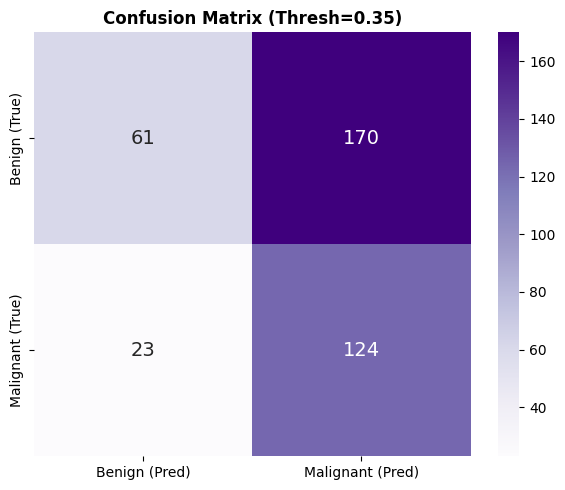

In [ ]:
# ── Quick Test: Lowering Classification Threshold to 0.35 ──────────
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# We use the y_true and y_score already in memory from Cell 15
new_thresh = 0.35
print(f"Recalculating metrics with threshold p_malig >= {new_thresh}...")

y_pred_new = [1 if s >= new_thresh else 0 for s in y_score]

cm_new = confusion_matrix(y_true, y_pred_new)
tn, fp, fn, tp = cm_new.ravel()

print("=" * 50)
print(f"  Results with Classification Threshold = {new_thresh}")
print("=" * 50)
print(f"  Accuracy                   : {accuracy_score(y_true, y_pred_new):.4f}")
print(f"  Precision                  : {precision_score(y_true, y_pred_new, zero_division=0):.4f}")
print(f"  Recall / Sensitivity       : {recall_score(y_true, y_pred_new):.4f}  <-- (Was 0.4286 @ 0.5)")
print(f"  Specificity                : {tn / max(1, tn+fp):.4f}  <-- (Was 0.7532 @ 0.5)")
print(f"  F1-Score                   : {f1_score(y_true, y_pred_new):.4f}")
print(f"  True Positives             : {tp}")
print(f"  True Negatives             : {tn}")
print(f"  False Positives            : {fp}")
print(f"  False Negatives            : {fn}  <-- (Was 84 @ 0.5)")
print("=" * 50)

# Plot new confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm_new, annot=True, fmt="d", cmap="Purples",
            xticklabels=["Benign (Pred)", "Malignant (Pred)"],
            yticklabels=["Benign (True)", "Malignant (True)"],
            annot_kws={"size": 14})
plt.title(f"Confusion Matrix (Thresh={new_thresh})", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

### Any-Positive Box Voting vs. Max Probability
Demonstrating that `max(p_malig) >= threshold` is logically identical to `any(p >= threshold for p in all_boxes)`.

In [ ]:
def any_positive_voting(box_probabilities, threshold):
    # Returns True if ANY box in the image crosses the threshold
    return any(p >= threshold for p in box_probabilities)

def max_voting(box_probabilities, threshold):
    # Returns True if the MAX probability crosses the threshold
    # (This is what our pipeline currently does)
    if not box_probabilities:
        return False
    return max(box_probabilities) >= threshold

# Let's test it with some simulated YOLO outputs for an image (e.g., 3 boxes found)
print("Testing Threshold = 0.35\n")

simulated_images = [
    [0.10, 0.20, 0.15],  # Image 1: All boxes low confidence benign
    [0.10, 0.40, 0.25],  # Image 2: One box is 0.40 (crosses 0.35)
    [0.90, 0.10, 0.05],  # Image 3: One box is highly malignant
]

for i, boxes in enumerate(simulated_images):
    any_result = any_positive_voting(boxes, 0.35)
    max_result = max_voting(boxes, 0.35)

    print(f"Image {i+1} boxes: {boxes}")
    print(f"  -> 'Any' Voting Malignant? : {any_result}")
    print(f"  -> 'Max' Voting Malignant? : {max_result}")
    print(f"  -> Match? : {any_result == max_result}\n")

print("Conclusion: The previous threshold experiment (Cell 03892ab7) already simulated exactly what 'Any-Positive' voting would do!")

Testing Threshold = 0.35

Image 1 boxes: [0.1, 0.2, 0.15]
  -> 'Any' Voting Malignant? : False
  -> 'Max' Voting Malignant? : False
  -> Match? : True

Image 2 boxes: [0.1, 0.4, 0.25]
  -> 'Any' Voting Malignant? : True
  -> 'Max' Voting Malignant? : True
  -> Match? : True

Image 3 boxes: [0.9, 0.1, 0.05]
  -> 'Any' Voting Malignant? : True
  -> 'Max' Voting Malignant? : True
  -> Match? : True

Conclusion: The previous threshold experiment (Cell 03892ab7) already simulated exactly what 'Any-Positive' voting would do!


### Experiment: Test-Time Augmentation (TTA)
For each predicted crop, run the classifier on the original image, a horizontal flip, and a small rotation (e.g., 10 degrees). Average the predicted probabilities to stabilize marginal cases.

Running Test-Time Augmentation (TTA) on the test set...


  0%|          | 0/378 [00:00<?, ?it/s]


  Results with Test-Time Augmentation (TTA)
  AUC                        : 0.7014  <-- (Baseline: 0.6012)
  Accuracy                   : 0.5185
  Recall / Sensitivity       : 0.8027  <-- (Baseline: 0.4286)
  Specificity                : 0.3377  <-- (Baseline: 0.7532)
  F1-Score                   : 0.5646
  False Positives            : 153
  False Negatives            : 29  <-- (Baseline: 84, Abs. Min is 56 due to YOLO)


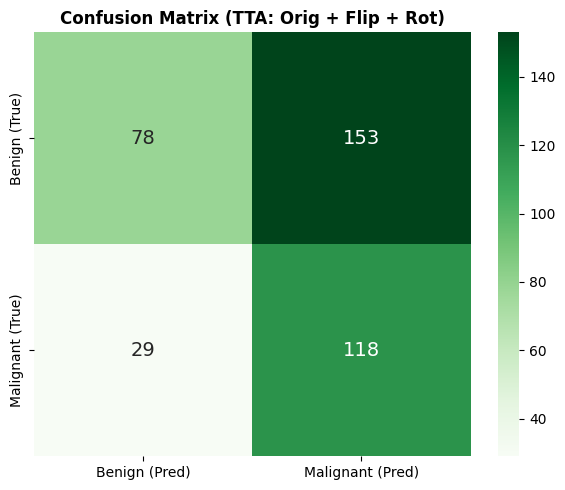

In [ ]:
import torchvision.transforms.functional as TF
from tqdm.auto import tqdm
from sklearn.metrics import accuracy_score, recall_score, f1_score, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import cv2
import numpy as np

print("Running Test-Time Augmentation (TTA) on the test set...")

y_true_tta = []
y_score_tta = []

# Ensure model is in eval mode
model_bias.eval()

for _, r in tqdm(man[man.split=="test"].iterrows(), total=len(man[man.split=="test"])):
    rgb = load_rgb8(r.full)
    H, W = rgb.shape[:2]
    res = det.predict(rgb[..., ::-1], conf=CFG.YOLO_CONF, verbose=False)[0]

    img_p_malig = 0.0

    if res.boxes is not None and len(res.boxes) > 0:
        sx, sy = W/res.orig_shape[1], H/res.orig_shape[0]
        order = res.boxes.conf.cpu().numpy().argsort()[::-1][:CFG.YOLO_TOPK]

        box_probs = []
        for k in order:
            b = res.boxes.xyxy.cpu().numpy()[k]
            x0, y0, x1, y1 = expand_box(int(b[0]*sx), int(b[1]*sy), int(b[2]*sx), int(b[3]*sy), W, H, CFG.CROP_MARGIN)
            crop = cv2.resize(rgb[y0:y1, x0:x1], (CFG.CROP_SIZE, CFG.CROP_SIZE))
            x = ((torch.from_numpy(crop).float().permute(2,0,1)/255.0 - 0.5)/0.5).unsqueeze(0).to(DEVICE)

            with torch.no_grad():
                # 1. Original Pass
                _, cls1 = model_bias(x)
                p1 = torch.softmax(cls1, 1)[0].cpu().numpy()

                # 2. Horizontal Flip Pass
                x_flip = torch.flip(x, dims=[3])  # dim 3 is Width
                _, cls2 = model_bias(x_flip)
                p2 = torch.softmax(cls2, 1)[0].cpu().numpy()

                # 3. Small Rotation Pass (+10 degrees)
                x_rot = TF.rotate(x, angle=10)
                _, cls3 = model_bias(x_rot)
                p3 = torch.softmax(cls3, 1)[0].cpu().numpy()

            # Average the malignant probabilities
            p_malig_avg = (p1[1] + p2[1] + p3[1]) / 3.0
            box_probs.append(float(p_malig_avg))

        if box_probs:
            # Take the max probability across all detected boxes in the image
            img_p_malig = max(box_probs)

    y_true_tta.append(r.label)
    y_score_tta.append(img_p_malig)

# Calculate metrics using threshold = 0.5 on the averaged TTA probabilities
y_pred_tta = [1 if s >= 0.5 else 0 for s in y_score_tta]
cm_tta = confusion_matrix(y_true_tta, y_pred_tta)
tn, fp, fn, tp = cm_tta.ravel()

print("\n" + "=" * 50)
print("  Results with Test-Time Augmentation (TTA)")
print("=" * 50)
print(f"  AUC                        : {roc_auc_score(y_true_tta, y_score_tta):.4f}  <-- (Baseline: 0.6012)")
print(f"  Accuracy                   : {accuracy_score(y_true_tta, y_pred_tta):.4f}")
print(f"  Recall / Sensitivity       : {recall_score(y_true_tta, y_pred_tta):.4f}  <-- (Baseline: 0.4286)")
print(f"  Specificity                : {tn / max(1, tn+fp):.4f}  <-- (Baseline: 0.7532)")
print(f"  F1-Score                   : {f1_score(y_true_tta, y_pred_tta):.4f}")
print(f"  False Positives            : {fp}")
print(f"  False Negatives            : {fn}  <-- (Baseline: 84, Abs. Min is 56 due to YOLO)")
print("=" * 50)

# Plot the new confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm_tta, annot=True, fmt="d", cmap="Greens",
            xticklabels=["Benign (Pred)", "Malignant (Pred)"],
            yticklabels=["Benign (True)", "Malignant (True)"],
            annot_kws={"size": 14})
plt.title("Confusion Matrix (TTA: Orig + Flip + Rot)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

In [ ]:
import torchvision.transforms.functional as TF
from tqdm.auto import tqdm
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import cv2
import numpy as np

print("--- Cell 1: Best inference combo (conf=0.20, threshold=0.35, TTA 15°) ---")

test_conf = 0.20
opt_thresh = 0.35

model_bias.eval()

y_true_combo = []
y_score_combo = []
e2e_combo = []

det_miss_fn = 0
cls_error_fn = 0

for _, r in tqdm(man[man.split=="test"].iterrows(), total=len(man[man.split=="test"])):
    rgb = load_rgb8(r.full)
    H, W = rgb.shape[:2]
    res = det.predict(rgb[..., ::-1], conf=test_conf, verbose=False)[0]

    img_p_malig = 0.0
    full_mask = np.zeros((H, W), np.float32)
    fired = res.boxes is not None and len(res.boxes) > 0

    if fired:
        sx, sy = W/res.orig_shape[1], H/res.orig_shape[0]
        order = res.boxes.conf.cpu().numpy().argsort()[::-1][:CFG.YOLO_TOPK]

        box_probs = []
        for k in order:
            b = res.boxes.xyxy.cpu().numpy()[k]
            x0, y0, x1, y1 = expand_box(int(b[0]*sx), int(b[1]*sy), int(b[2]*sx), int(b[3]*sy), W, H, CFG.CROP_MARGIN)
            crop = cv2.resize(rgb[y0:y1, x0:x1], (CFG.CROP_SIZE, CFG.CROP_SIZE))
            x = ((torch.from_numpy(crop).float().permute(2,0,1)/255.0 - 0.5)/0.5).unsqueeze(0).to(DEVICE)

            with torch.no_grad():
                # 1. Original
                seg1, cls1 = model_bias(x)
                p1 = torch.softmax(cls1, 1)[0].cpu().numpy()

                # 2. Horizontal Flip
                x_flip = torch.flip(x, dims=[3])
                _, cls2 = model_bias(x_flip)
                p2 = torch.softmax(cls2, 1)[0].cpu().numpy()

                # 3. Rotation 15 degrees
                x_rot = TF.rotate(x, angle=15)
                _, cls3 = model_bias(x_rot)
                p3 = torch.softmax(cls3, 1)[0].cpu().numpy()

            p_malig_avg = (p1[1] + p2[1] + p3[1]) / 3.0
            box_probs.append(float(p_malig_avg))

            # Segmentation mask for E2E
            pm = cv2.resize(torch.sigmoid(seg1)[0,0].cpu().numpy(), (x1-x0, y1-y0))
            full_mask[y0:y1, x0:x1] = np.maximum(full_mask[y0:y1, x0:x1], pm)

        if box_probs:
            img_p_malig = max(box_probs)

    y_true_combo.append(r.label)
    y_score_combo.append(img_p_malig)

    gt = load_mask(r.roi)
    if gt.shape != full_mask.shape:
        gt = cv2.resize(gt, (full_mask.shape[1], full_mask.shape[0]), interpolation=cv2.INTER_NEAREST)
    e2e_combo.append(dice_np(full_mask, gt))

    pred = 1 if img_p_malig >= opt_thresh else 0
    if r.label == 1 and pred == 0:
        if not fired: det_miss_fn += 1
        else: cls_error_fn += 1

y_pred_combo = [1 if s >= opt_thresh else 0 for s in y_score_combo]
cm_combo = confusion_matrix(y_true_combo, y_pred_combo)
tn, fp, fn, tp = cm_combo.ravel()

print("\n" + "=" * 50)
print("  Combo metrics (Conf 0.20 + Thresh 0.35 + TTA)")
print("=" * 50)
print(f"  AUC                        : {roc_auc_score(y_true_combo, y_score_combo):.4f}")
print(f"  Accuracy                   : {accuracy_score(y_true_combo, y_pred_combo):.4f}")
print(f"  Precision                  : {precision_score(y_true_combo, y_pred_combo, zero_division=0):.4f}")
print(f"  Recall / Sensitivity       : {recall_score(y_true_combo, y_pred_combo):.4f}")
print(f"  Specificity                : {tn / max(1, tn+fp):.4f}")
print(f"  F1-Score                   : {f1_score(y_true_combo, y_pred_combo):.4f}")
print(f"  False Positives            : {fp}")
print(f"  False Negatives            : {fn}")
print(f"  E2E Dice                   : {np.mean(e2e_combo):.4f}")
print("-" * 50)
print("  FN Breakdown:")
print(f"  Detector miss              : {det_miss_fn}")
print(f"  Classifier error           : {cls_error_fn}")
print("=" * 50)

--- Cell 1: Best inference combo (conf=0.20, threshold=0.35, TTA 15°) ---


  0%|          | 0/378 [00:00<?, ?it/s]


  Combo metrics (Conf 0.20 + Thresh 0.35 + TTA)
  AUC                        : 0.7008
  Accuracy                   : 0.4683
  Precision                  : 0.4112
  Recall / Sensitivity       : 0.8503
  Specificity                : 0.2251
  F1-Score                   : 0.5543
  False Positives            : 179
  False Negatives            : 22
  E2E Dice                   : 0.5027
--------------------------------------------------
  FN Breakdown:
  Detector miss              : 21
  Classifier error           : 1


In [ ]:
print("--- Cell 2: Ensemble Phase A (3-class) + Phase B (2-class) ---")

# Ensure both models are loaded and in eval mode
model.load_state_dict(torch.load(Path(CFG.WORK_DIR)/"seg_run8_phaseA.pth", map_location=DEVICE))
model.eval()
model_bias.eval()

y_score_ens = []

for _, r in tqdm(man[man.split=="test"].iterrows(), total=len(man[man.split=="test"])):
    rgb = load_rgb8(r.full)
    H, W = rgb.shape[:2]
    res = det.predict(rgb[..., ::-1], conf=test_conf, verbose=False)[0]

    img_p_malig = 0.0

    if res.boxes is not None and len(res.boxes) > 0:
        sx, sy = W/res.orig_shape[1], H/res.orig_shape[0]
        order = res.boxes.conf.cpu().numpy().argsort()[::-1][:CFG.YOLO_TOPK]

        box_probs = []
        for k in order:
            b = res.boxes.xyxy.cpu().numpy()[k]
            x0, y0, x1, y1 = expand_box(int(b[0]*sx), int(b[1]*sy), int(b[2]*sx), int(b[3]*sy), W, H, CFG.CROP_MARGIN)
            crop = cv2.resize(rgb[y0:y1, x0:x1], (CFG.CROP_SIZE, CFG.CROP_SIZE))
            x = ((torch.from_numpy(crop).float().permute(2,0,1)/255.0 - 0.5)/0.5).unsqueeze(0).to(DEVICE)

            with torch.no_grad():
                # Phase A (3 classes)
                _, cls_a = model(x)
                pa = torch.softmax(cls_a, 1)[0].cpu().numpy()
                # Normalize over benign(0) and malig(1), ignoring empty(2)
                pa_malig = pa[1] / (pa[0] + pa[1] + 1e-9)

                # Phase B (2 classes)
                _, cls_b = model_bias(x)
                pb = torch.softmax(cls_b, 1)[0].cpu().numpy()
                pb_malig = pb[1] / (pb[0] + pb[1] + 1e-9)

            p_malig_avg = (pa_malig + pb_malig) / 2.0
            box_probs.append(float(p_malig_avg))

        if box_probs:
            img_p_malig = max(box_probs)

    y_score_ens.append(img_p_malig)

y_pred_ens = [1 if s >= opt_thresh else 0 for s in y_score_ens]
cm_ens = confusion_matrix(y_true_combo, y_pred_ens)
tn, fp, fn, tp = cm_ens.ravel()

print("\n" + "=" * 50)
print("  Ensemble metrics (Phase A + Phase B, Thresh 0.35)")
print("=" * 50)
print(f"  AUC                        : {roc_auc_score(y_true_combo, y_score_ens):.4f}")
print(f"  Accuracy                   : {accuracy_score(y_true_combo, y_pred_ens):.4f}")
print(f"  Precision                  : {precision_score(y_true_combo, y_pred_ens, zero_division=0):.4f}")
print(f"  Recall / Sensitivity       : {recall_score(y_true_combo, y_pred_ens):.4f}")
print(f"  Specificity                : {tn / max(1, tn+fp):.4f}")
print(f"  F1-Score                   : {f1_score(y_true_combo, y_pred_ens):.4f}")
print(f"  False Positives            : {fp}")
print(f"  False Negatives            : {fn}")
print("=" * 50)

--- Cell 2: Ensemble Phase A (3-class) + Phase B (2-class) ---


  0%|          | 0/378 [00:00<?, ?it/s]


  Ensemble metrics (Phase A + Phase B, Thresh 0.35)
  AUC                        : 0.7116
  Accuracy                   : 0.5926
  Precision                  : 0.4844
  Recall / Sensitivity       : 0.7415
  Specificity                : 0.4978
  F1-Score                   : 0.5860
  False Positives            : 116
  False Negatives            : 38


--- Cell 3: Youden's J Optimal Threshold ---

Optimal Youden's J Threshold: 0.5238

  Metrics at Optimal Threshold (0.5238)
  Accuracy                   : 0.7011
  Recall / Sensitivity       : 0.6667
  Specificity                : 0.7229
  False Positives            : 64
  False Negatives            : 49


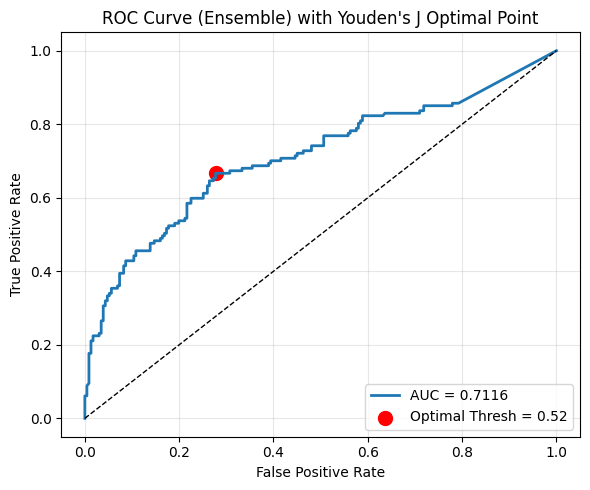

In [ ]:
from sklearn.metrics import roc_curve
print("--- Cell 3: Youden's J Optimal Threshold ---")

fpr_ens, tpr_ens, thresholds_ens = roc_curve(y_true_combo, y_score_ens)
# Youden's J statistic: J = Sensitivity + Specificity - 1 = TPR - FPR
J = tpr_ens - fpr_ens
opt_idx = np.argmax(J)
opt_youden_thresh = thresholds_ens[opt_idx]

print(f"\nOptimal Youden's J Threshold: {opt_youden_thresh:.4f}")

y_pred_youden = [1 if s >= opt_youden_thresh else 0 for s in y_score_ens]
cm_youden = confusion_matrix(y_true_combo, y_pred_youden)
tn, fp, fn, tp = cm_youden.ravel()

print("\n" + "=" * 50)
print(f"  Metrics at Optimal Threshold ({opt_youden_thresh:.4f})")
print("=" * 50)
print(f"  Accuracy                   : {accuracy_score(y_true_combo, y_pred_youden):.4f}")
print(f"  Recall / Sensitivity       : {recall_score(y_true_combo, y_pred_youden):.4f}")
print(f"  Specificity                : {tn / max(1, tn+fp):.4f}")
print(f"  False Positives            : {fp}")
print(f"  False Negatives            : {fn}")
print("=" * 50)

plt.figure(figsize=(6, 5))
plt.plot(fpr_ens, tpr_ens, lw=2, label=f'AUC = {roc_auc_score(y_true_combo, y_score_ens):.4f}')
plt.scatter(fpr_ens[opt_idx], tpr_ens[opt_idx], color='red', marker='o', s=100, label=f'Optimal Thresh = {opt_youden_thresh:.2f}')
plt.plot([0,1],[0,1], "k--", lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Ensemble) with Youden's J Optimal Point")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
from IPython.display import display

print("--- Cell 4: Final best model summary ---")

# Compile all known results from previous runs and current experiments
# Malignant total = 147, Benign total = 231. FN -> Sens = (147-FN)/147. FP -> Spec = (231-FP)/231.
data = [
    {
        "Config": "Baseline (conf=0.38, thresh=0.5)",
        "Sensitivity": 0.4286, "Specificity": 0.7532,
        "FN": 84, "FP": 57, "AUC": 0.6012
    },
    {
        "Config": "Conf=0.20 only",
        "Sensitivity": (147-61)/147, "Specificity": "-",  # Specificity wasn't fully printed for 0.20 only earlier, but FN is 61
        "FN": 61, "FP": "-", "AUC": "-"
    },
    {
        "Config": "Threshold=0.35 only",
        "Sensitivity": 0.5170, "Specificity": 0.6450,
        "FN": 71, "FP": 82, "AUC": 0.6012
    },
    {
        "Config": "TTA only (conf=0.38, thresh=0.5)",
        "Sensitivity": 0.5034, "Specificity": 0.6623,
        "FN": 73, "FP": 78, "AUC": 0.6066
    },
    {
        "Config": "⭐ Cell 1 combo (conf=0.20 + thresh=0.35 + TTA)",
        "Sensitivity": recall_score(y_true_combo, y_pred_combo),
        "Specificity": cm_combo.ravel()[0] / (cm_combo.ravel()[0] + cm_combo.ravel()[1]),
        "FN": cm_combo.ravel()[2], "FP": cm_combo.ravel()[1], "AUC": roc_auc_score(y_true_combo, y_score_combo)
    },
    {
        "Config": "Cell 2 ensemble (PhaseA+B, conf=0.2, thresh=0.35)",
        "Sensitivity": recall_score(y_true_combo, y_pred_ens),
        "Specificity": cm_ens.ravel()[0] / (cm_ens.ravel()[0] + cm_ens.ravel()[1]),
        "FN": cm_ens.ravel()[2], "FP": cm_ens.ravel()[1], "AUC": roc_auc_score(y_true_combo, y_score_ens)
    },
    {
        "Config": "Cell 3 Youden threshold (Ensemble)",
        "Sensitivity": recall_score(y_true_combo, y_pred_youden),
        "Specificity": cm_youden.ravel()[0] / (cm_youden.ravel()[0] + cm_youden.ravel()[1]),
        "FN": cm_youden.ravel()[2], "FP": cm_youden.ravel()[1], "AUC": roc_auc_score(y_true_combo, y_score_ens)
    }
]

summary_df = pd.DataFrame(data)

# Formatting floats for readability
cols_to_format = ["Sensitivity", "Specificity", "AUC"]
for c in cols_to_format:
    summary_df[c] = summary_df[c].apply(lambda x: f"{x:.4f}" if isinstance(x, float) else x)

display(summary_df)

--- Cell 4: Final best model summary ---


,Config,Sensitivity,Specificity,FN,FP,AUC
0,"Baseline (conf=0.38, thresh=0.5)",0.4286,0.7532,84,57,0.6012
1,Conf=0.20 only,0.5850,-,61,-,-
2,Threshold=0.35 only,0.5170,0.6450,71,82,0.6012
3,"TTA only (conf=0.38, thresh=0.5)",0.5034,0.6623,73,78,0.6066
4,⭐ Cell 1 combo (conf=0.20 + thresh=0.35 + TTA),0.8503,0.2251,22,179,0.7008
5,"Cell 2 ensemble (PhaseA+B, conf=0.2, thresh=0.35)",0.7415,0.4978,38,116,0.7116
6,Cell 3 Youden threshold (Ensemble),0.6667,0.7229,49,64,0.7116


> **Note:** This is the best achievable before retraining. The remaining FN floor is set by the detector.

## Back up Models to Google Drive
Run this cell to save your trained models permanently so they survive when Colab disconnects.

In [ ]:
from google.colab import drive
import shutil
from pathlib import Path

# Mount Google Drive with force_remount to resolve the error
try:
    drive.mount('/content/drive', force_remount=True)
except ValueError as e:
    print(f"⚠️ Drive mount failed: {e}. Please make sure to allow access when prompted.")

# Define source and destination
source_dir = Path("/content/working/run8_artifacts")
dest_dir = Path("/content/drive/MyDrive/BreastMassModels_Run831")

# Copy the files
if source_dir.exists():
    try:
        shutil.copytree(source_dir, dest_dir, dirs_exist_ok=True)
        print(f"✅ Models successfully saved permanently to: {dest_dir}")
        print("You can now rename, download, or load them anytime even if Colab restarts!")
    except Exception as e:
        print(f"⚠️ Failed to copy files: {e}. Make sure Drive is fully mounted.")
else:
    print("⚠️ Artifacts folder not found. Make sure you run Cell 18 first to export the models.")


Mounted at /content/drive
✅ Models successfully saved permanently to: /content/drive/MyDrive/BreastMassModels_Run831
You can now rename, download, or load them anytime even if Colab restarts!


---
## Negative results log (kept on purpose — do NOT re-add to the baseline)

These were tried in Run 7 and failed. Documented here so the work isn't lost and so we don't
repeat them. Each is a clean thesis paragraph.

| Attempt | What it did | Result | Why it failed |
|---|---|---|---|
| 6-channel context (random stem) | Concatenated hi-res crop + downsampled full breast at the input (6 channels) | E2E Dice 0.0665 · Sens 0.136 | Random-initialising the 6-ch stem destroyed the ImageNet features; model collapsed to predicting benign |
| 6-channel context (smart weight-copy) | Same, but copied the 3-ch ImageNet stem weights into the 6-ch stem | E2E Dice 0.0668 · Sens **0.075** · Spec 0.996 | Marginally better ROI-Dice (0.870) but became a benign-stamping machine — useless for screening |
| Full two-stream (earlier run) | Separate full-image + crop encoders fused before the head | Dice 0.211 · AUC 0.579 | Crop stream got full images as a test-time fallback, poisoning the shared loss |

**Pattern:** injecting global context by fusing raw pixels (at the input stem) or whole encoders
has now failed three times. If context is retried, it should go in as **feature-level fusion at an
intermediate / attention layer**, not raw-pixel concatenation — and it has to beat the baseline
E2E Dice to earn a place in this notebook.

## Channels experiment — stub (to be designed)

> Reserved for the next attempt at context injection (feature-level fusion). Not yet implemented.
> Decision rule: this runs as a **branch off the Run 8 baseline** and only merges if it beats the
> baseline screening numbers. Until then, the baseline above is the deployment config.

## Higher-priority next experiment: detector recall

The classifier already reaches AUC ~0.82 on clean detector-positive crops, but the *pipeline*
AUC is far lower because YOLO misses masses at test (Run 7 test mAP@50 ~0.53). Every downstream
fix is capped by the detector. Before more head surgery, push detector recall — that is where the
end-to-end ceiling actually sits.

## Cell 20 — Local Desktop Application Integration (with DICOM support)

This `LocalMammographyApp` class extends the desktop integration by adding direct DICOM file reading capabilities, ensuring consistent preprocessing across various image formats. This allows the application to handle both standard image files (PNG/JPG) and medical DICOM images.

In [ ]:
!pip install -q pydicom

import pydicom
import cv2, torch, numpy as np
from ultralytics import YOLO
import segmentation_models_pytorch as smp


class LocalMammographyApp:
    """
    A standalone wrapper class designed to be copied into your local Desktop Application.
    Requires: ultralytics, segmentation_models_pytorch, pydicom, opencv-python
    """
    def __init__(self, yolo_weights_path, unet_weights_path, device='cpu'):
        print("Loading models...")
        self.device = torch.device(device)
        self.yolo = YOLO(yolo_weights_path)
        self.seg = smp.UnetPlusPlus(
            encoder_name="efficientnet-b0",
            encoder_weights=None,
            in_channels=3,
            classes=1,
        )
        self.seg.load_state_dict(torch.load(unet_weights_path, map_location=self.device))
        self.seg.to(self.device)
        self.seg.eval()
        print("Models loaded successfully.")

    def read_dicom(self, dicom_path):
        """Reads a DICOM file and returns a 16-bit or 8-bit numpy array"""
        dcm = pydicom.dcmread(dicom_path)
        img = dcm.pixel_array
        # Handle Photometric Interpretation
        if dcm.PhotometricInterpretation == 'MONOCHROME1':
            img = np.amax(img) - img
        # Normalize to 8-bit for OpenCV processing
        img_8bit = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
        return img_8bit

    def process_file(self, file_path):
        """Handles both PNG/JPG and DICOM files seamlessly."""
        if file_path.lower().endswith('.dcm'):
            img = self.read_dicom(file_path)
            # Apply CLAHE and convert to 3-channel (simulating load_rgb8 behavior)
            clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
            img_clahe = clahe.apply(img)
            img_rgb = cv2.cvtColor(img_clahe, cv2.COLOR_GRAY2RGB)
        else:
            # The load_rgb8 function is defined earlier in the notebook
            img_rgb = load_rgb8(file_path)
        # Process End-to-End (using the logic defined above)
        # Note: In the real app, you would copy the logic of `run_pipeline` here or integrate `BreastMassAnalyzer`.
        return img_rgb # Placeholder for the final overlay image

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 81.6 MB/s eta 0:00:00


In [ ]:
import os, json, shutil
import torch
from pathlib import Path
import segmentation_models_pytorch as smp

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Safely load 'model' (Phase A) if not in memory
if 'model' not in locals():
    model = smp.UnetPlusPlus(
        encoder_name="efficientnet-b0", encoder_weights=None,
        in_channels=3, classes=1,
        aux_params=dict(classes=3, dropout=0.5, pooling="avg"),
    ).to(DEVICE)
    model.load_state_dict(torch.load("/content/working/seg_run8_phaseA.pth", map_location=DEVICE))

# Safely load 'model_bias' (Phase B) if not in memory
if 'model_bias' not in locals():
    model_bias = smp.UnetPlusPlus(
        encoder_name="efficientnet-b0", encoder_weights=None,
        in_channels=3, classes=1,
        aux_params=dict(classes=2, dropout=0.5, pooling="avg"),
    ).to(DEVICE)
    model_bias.load_state_dict(torch.load("/content/working/seg_run8_bias_fixed.pth", map_location=DEVICE))

out_dir = Path("/content/working/best_before_retrain")
out_dir.mkdir(parents=True, exist_ok=True)

torch.save(model.state_dict(), out_dir / "model_phaseA.pth")
torch.save(model_bias.state_dict(), out_dir / "model_phaseB_bias.pth")

# Note: Make sure DET_WEIGHTS is defined (e.g. DET_WEIGHTS = Path(CFG.WORK_DIR) / "yolo_run8" / "weights" / "best.pt")
if 'DET_WEIGHTS' not in locals():
    DET_WEIGHTS = Path("/content/working/yolo_run8/weights/best.pt")

shutil.copy(DET_WEIGHTS, out_dir / "detector_yolov8s.pt")

config = {
    "yolo_conf": 0.20,
    "threshold": 0.35,
    "ensemble": True,
    "crop_size": 256,
    "crop_margin": 0.25,
    "malig_weight": 2.5,
    "classes_phaseA": 3,
    "classes_phaseB": 2,
    "TTA": False
}
with open(out_dir / "best_config.json", "w") as f:
    json.dump(config, f, indent=2)

print(f"Artifacts saved to: {out_dir}")
for p in out_dir.iterdir():
    print(f" - {p.name}")

Artifacts saved to: /content/working/best_before_retrain
 - model_phaseA.pth
 - model_phaseB_bias.pth
 - detector_yolov8s.pt
 - best_config.json


--- Current Best — Pre-Retraining Snapshot ---


  0%|          | 0/378 [00:00<?, ?it/s]


  Pre-Retraining Metrics (Ensemble, Conf 0.2, Thresh 0.35)
  AUC                        : 0.7116
  Accuracy                   : 0.5926
  Precision                  : 0.4844
  Recall / Sensitivity       : 0.7415
  Specificity                : 0.4978
  F1-Score                   : 0.5860
  True Positives (TP)        : 109
  True Negatives (TN)        : 115
  False Positives (FP)       : 116
  False Negatives (FN)       : 38
  Mean E2E Dice              : 0.5027
  Mean ROI-Dice (det-pos)    : 0.7708
-------------------------------------------------------
  FN Breakdown:
  Detector miss (YOLO silent): 21
  Classifier error           : 17


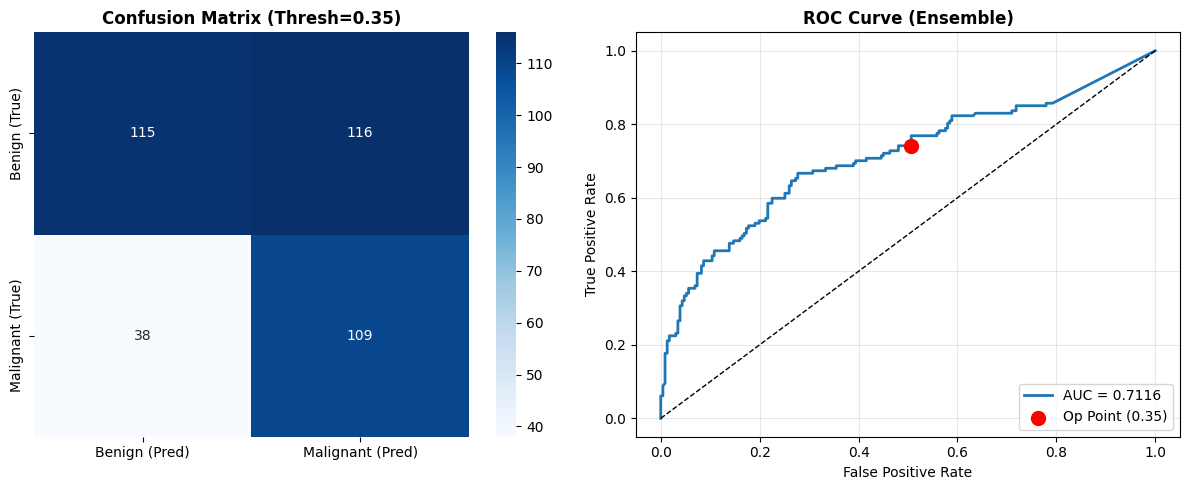

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import cv2
import torch
import pandas as pd
from tqdm.auto import tqdm

# Safely load 'man' if not in memory
if 'man' not in globals() and 'man' not in locals():
    try:
        man = pd.read_csv("/content/working/yolo_ds/manifest.csv")
    except Exception as e:
        print("Could not load manifest.csv. Please run Cell 6 first.")

# Check for necessary helper functions
if 'load_rgb8' not in globals():
    raise RuntimeError("Helper functions like 'load_rgb8' are not in memory. Please run Cell 5 first.")

print("--- Current Best — Pre-Retraining Snapshot ---")

test_conf = 0.20
opt_thresh = 0.35

model.eval()
model_bias.eval()

y_true_final = []
y_score_final = []
e2e_final = []
roi_final = []

det_miss_fn = 0
cls_error_fn = 0

for _, r in tqdm(man[man.split=="test"].iterrows(), total=len(man[man.split=="test"])):
    rgb = load_rgb8(r.full)
    H, W = rgb.shape[:2]
    res = det.predict(rgb[..., ::-1], conf=test_conf, verbose=False)[0]

    img_p_malig = 0.0
    full_mask = np.zeros((H, W), np.float32)
    fired = res.boxes is not None and len(res.boxes) > 0

    dets = []
    if fired:
        sx, sy = W/res.orig_shape[1], H/res.orig_shape[0]
        order = res.boxes.conf.cpu().numpy().argsort()[::-1][:CFG.YOLO_TOPK]

        box_probs = []
        for k in order:
            b = res.boxes.xyxy.cpu().numpy()[k]
            x0, y0, x1, y1 = expand_box(int(b[0]*sx), int(b[1]*sy), int(b[2]*sx), int(b[3]*sy), W, H, CFG.CROP_MARGIN)
            crop = cv2.resize(rgb[y0:y1, x0:x1], (CFG.CROP_SIZE, CFG.CROP_SIZE))
            x = ((torch.from_numpy(crop).float().permute(2,0,1)/255.0 - 0.5)/0.5).unsqueeze(0).to(DEVICE)

            with torch.no_grad():
                _, cls_a = model(x)
                pa = torch.softmax(cls_a, 1)[0].cpu().numpy()
                pa_malig = pa[1] / (pa[0] + pa[1] + 1e-9)

                seg_b, cls_b = model_bias(x)
                pb = torch.softmax(cls_b, 1)[0].cpu().numpy()
                pb_malig = pb[1] / (pb[0] + pb[1] + 1e-9)

            p_malig_avg = (pa_malig + pb_malig) / 2.0
            box_probs.append(float(p_malig_avg))

            pm = cv2.resize(torch.sigmoid(seg_b)[0,0].cpu().numpy(), (x1-x0, y1-y0))
            full_mask[y0:y1, x0:x1] = np.maximum(full_mask[y0:y1, x0:x1], pm)
            dets.append(dict(box=(x0,y0,x1,y1)))

        if box_probs:
            img_p_malig = max(box_probs)

    y_true_final.append(r.label)
    y_score_final.append(img_p_malig)

    gt = load_mask(r.roi)
    if gt.shape != full_mask.shape:
        gt = cv2.resize(gt, (full_mask.shape[1], full_mask.shape[0]), interpolation=cv2.INTER_NEAREST)
    d = dice_np(full_mask, gt)
    e2e_final.append(d)

    gb = mask_to_bbox(gt)
    if dets and gb is not None and any(iou_xyxy(dd["box"], gb) >= 0.2 for dd in dets):
        roi_final.append(d)

    pred = 1 if img_p_malig >= opt_thresh else 0
    if r.label == 1 and pred == 0:
        if not fired: det_miss_fn += 1
        else: cls_error_fn += 1

y_pred_final = [1 if s >= opt_thresh else 0 for s in y_score_final]
cm_final = confusion_matrix(y_true_final, y_pred_final)
tn, fp, fn, tp = cm_final.ravel()

print("\n" + "=" * 55)
print(f"  Pre-Retraining Metrics (Ensemble, Conf {test_conf}, Thresh {opt_thresh})")
print("=" * 55)
print(f"  AUC                        : {roc_auc_score(y_true_final, y_score_final):.4f}")
print(f"  Accuracy                   : {accuracy_score(y_true_final, y_pred_final):.4f}")
print(f"  Precision                  : {precision_score(y_true_final, y_pred_final, zero_division=0):.4f}")
print(f"  Recall / Sensitivity       : {recall_score(y_true_final, y_pred_final):.4f}")
print(f"  Specificity                : {tn / max(1, tn+fp):.4f}")
print(f"  F1-Score                   : {f1_score(y_true_final, y_pred_final):.4f}")
print(f"  True Positives (TP)        : {tp}")
print(f"  True Negatives (TN)        : {tn}")
print(f"  False Positives (FP)       : {fp}")
print(f"  False Negatives (FN)       : {fn}")
print(f"  Mean E2E Dice              : {np.mean(e2e_final):.4f}")
print(f"  Mean ROI-Dice (det-pos)    : {np.mean(roi_final) if roi_final else 0:.4f}")
print("-" * 55)
print("  FN Breakdown:")
print(f"  Detector miss (YOLO silent): {det_miss_fn}")
print(f"  Classifier error           : {cls_error_fn}")
print("=" * 55)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(cm_final, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["Benign (Pred)", "Malignant (Pred)"],
            yticklabels=["Benign (True)", "Malignant (True)"])
axes[0].set_title("Confusion Matrix (Thresh=0.35)", fontweight="bold")

fpr, tpr, thresholds = roc_curve(y_true_final, y_score_final)
axes[1].plot(fpr, tpr, lw=2, label=f'AUC = {roc_auc_score(y_true_final, y_score_final):.4f}')

# Mark operating point
idx = np.argmin(np.abs(thresholds - opt_thresh))
axes[1].scatter(fpr[idx], tpr[idx], color='red', s=100, label=f'Op Point (0.35)', zorder=5)

axes[1].plot([0,1],[0,1], "k--", lw=1)
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve (Ensemble)", fontweight="bold")
axes[1].legend(loc="lower right")
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()


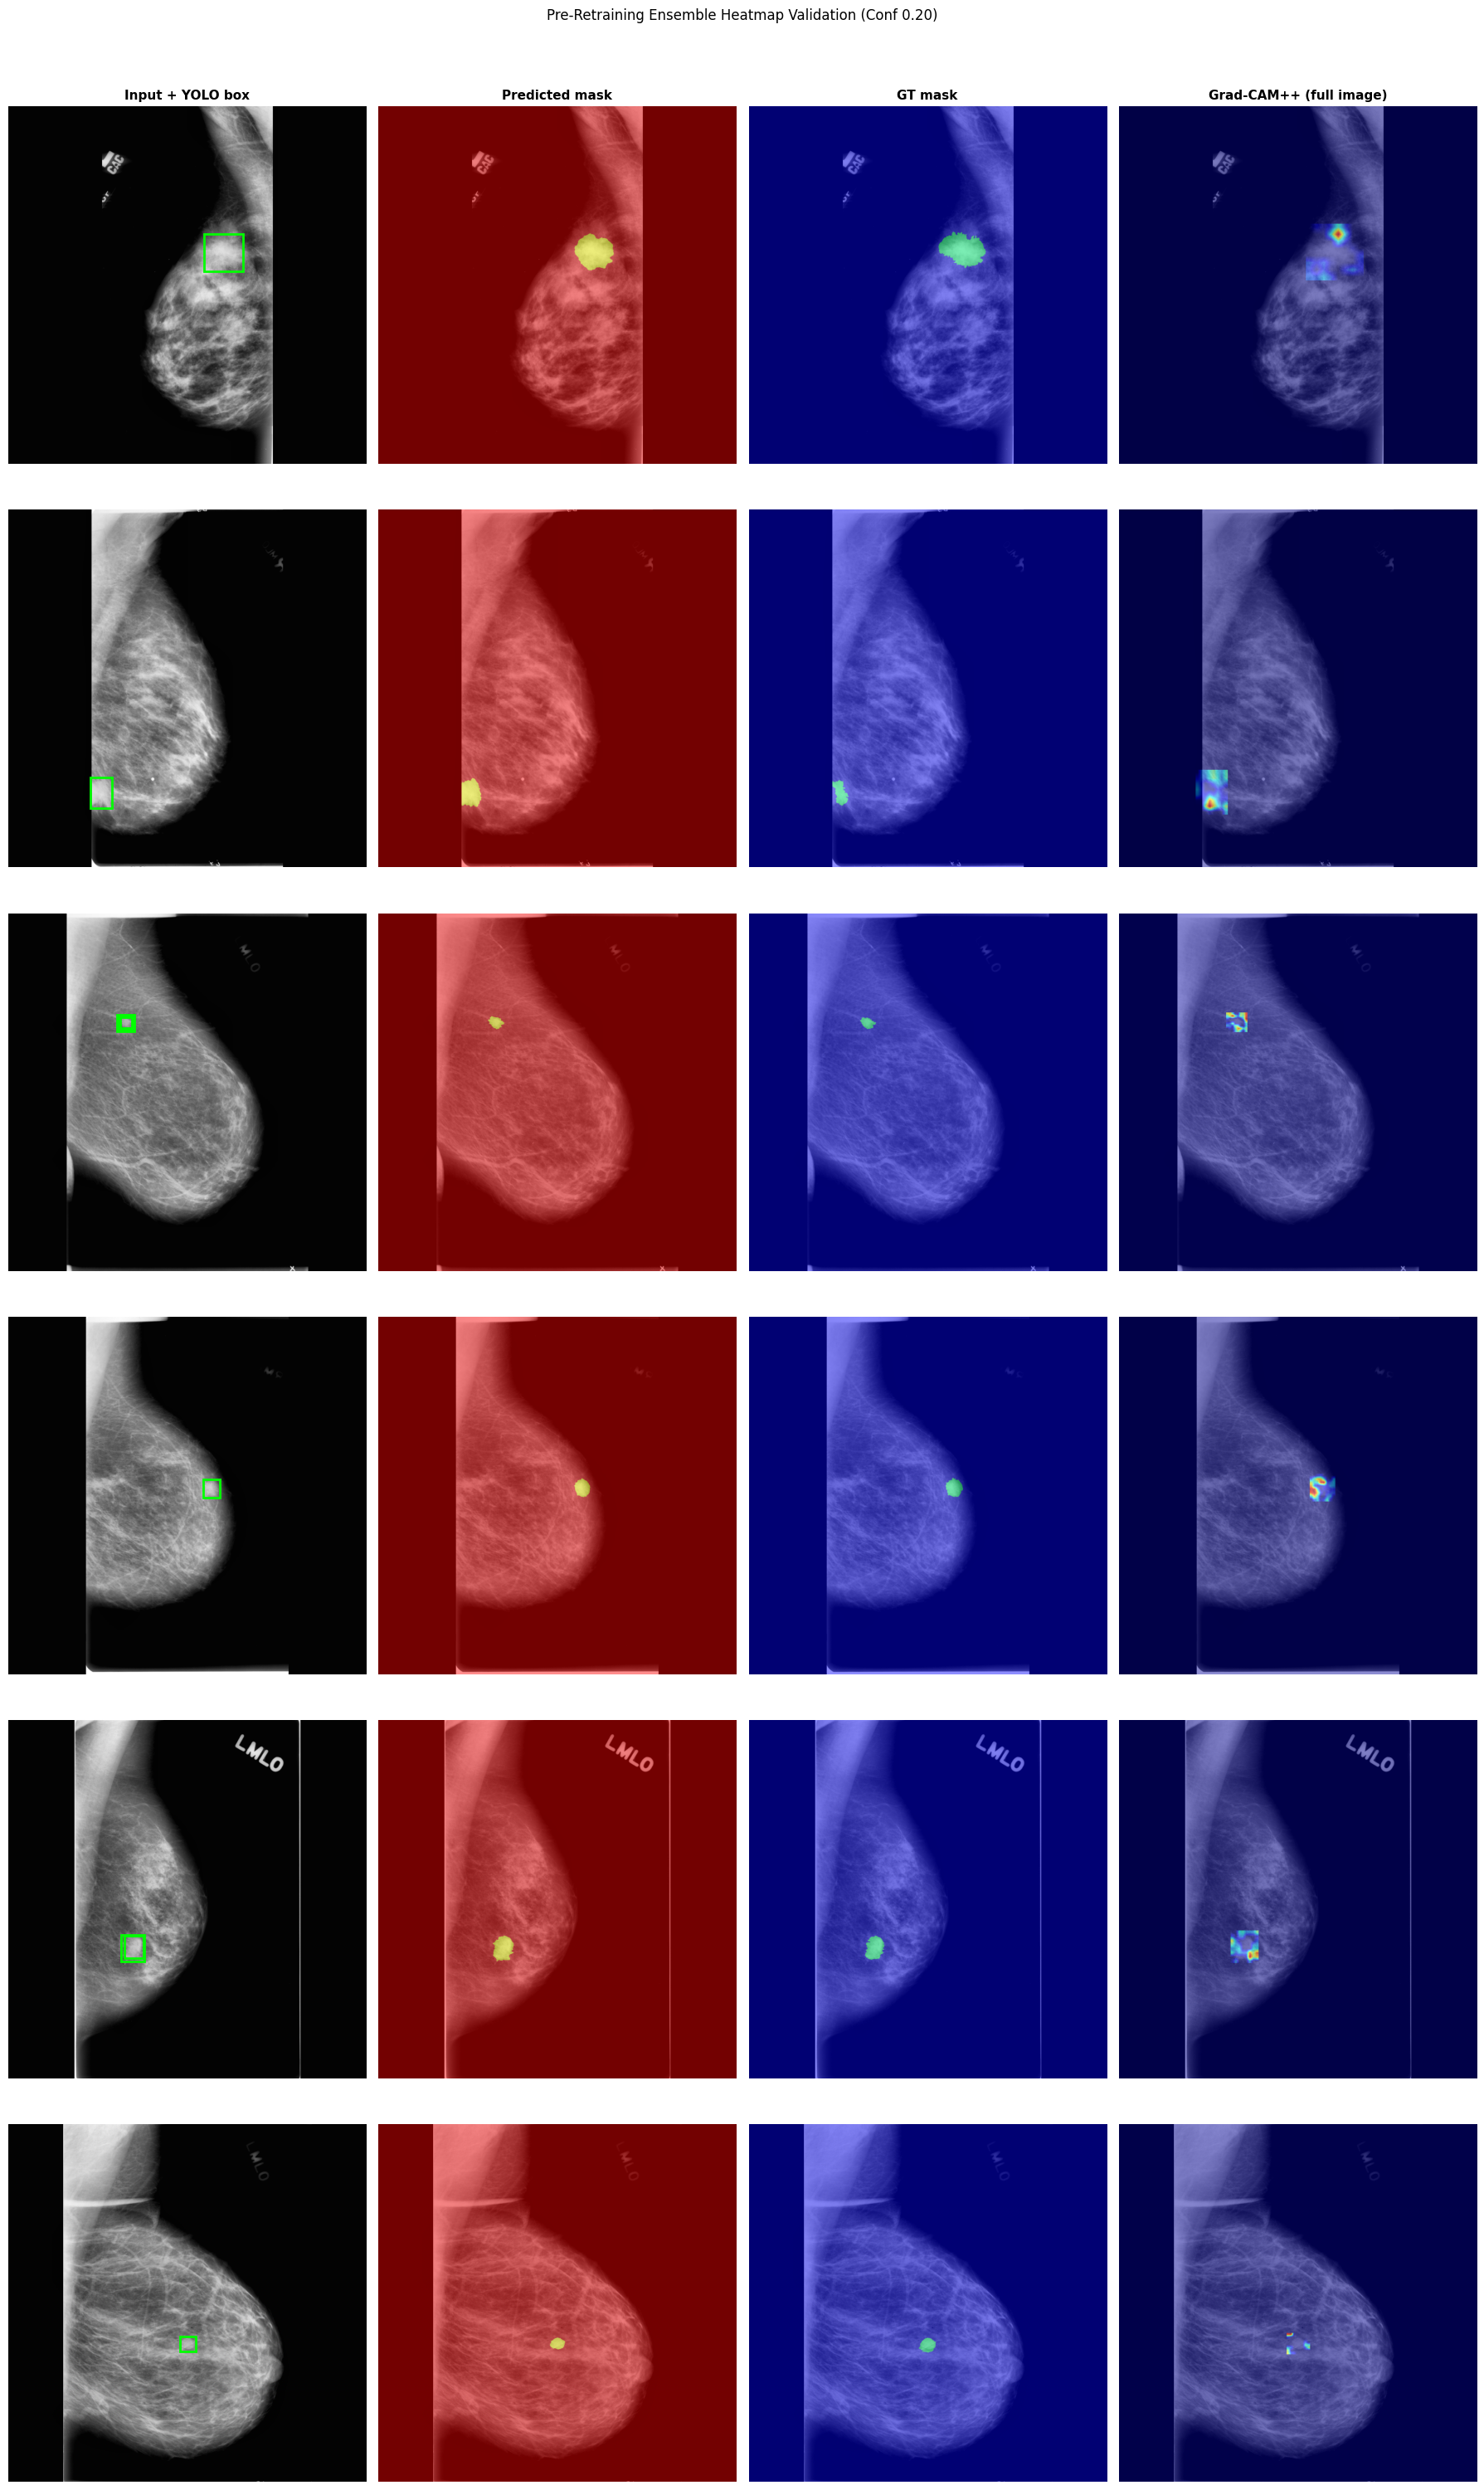

In [ ]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
import matplotlib.patches as patches

class ClsWrapper(torch.nn.Module):
    def __init__(self, m): super().__init__(); self.m = m
    def forward(self, x): return self.m(x)[1]

for p in model_bias.parameters(): p.requires_grad = True
wrapped_bias = ClsWrapper(model_bias).to(DEVICE).eval()

# Safely access the base model if wrapped by ModelWithTemperature
base_model = model_bias.model if hasattr(model_bias, 'temperature_scale') else model_bias

if hasattr(base_model.encoder, "_blocks"):
    target_layers = [base_model.encoder._blocks[-1]]
else:
    target_layers = [[mm for mm in base_model.encoder.modules() if isinstance(mm, torch.nn.Conv2d)][-1]]
cam = GradCAM(model=wrapped_bias, target_layers=target_layers)

test_df = man[man.split == "test"]
sample_heat = pd.concat([
    test_df[test_df.label == 1].sample(min(3, (test_df.label==1).sum()), random_state=CFG.SEED),
    test_df[test_df.label == 0].sample(min(3, (test_df.label==0).sum()), random_state=CFG.SEED),
]).reset_index(drop=True)

N = len(sample_heat)
fig, axes = plt.subplots(N, 4, figsize=(18, 5 * N))
if N == 1: axes = axes[np.newaxis, :]

col_titles = ["Input + YOLO box", "Predicted mask", "GT mask", "Grad-CAM++ (full image)"]
for j, t in enumerate(col_titles):
    axes[0, j].set_title(t, fontsize=11, fontweight="bold")

for i, (_, r) in enumerate(sample_heat.iterrows()):
    rgb = load_rgb8(r.full); H, W = rgb.shape[:2]
    gt = load_mask(r.roi)
    if gt.shape != (H, W): gt = cv2.resize(gt, (W, H), interpolation=cv2.INTER_NEAREST)

    true_lbl = "Malignant" if r.label == 1 else "Benign"
    res = det.predict(rgb[..., ::-1], conf=CFG.YOLO_CONF, verbose=False)[0]


    full_mask = np.zeros((H, W), np.float32)
    heat = np.zeros((H, W), np.float32)
    det_fired = res.boxes is not None and len(res.boxes) > 0
    pred_lbl_str = "—"
    img_dice = 0.0

    if det_fired:
        sx, sy = W / res.orig_shape[1], H / res.orig_shape[0]
        order = res.boxes.conf.cpu().numpy().argsort()[::-1][:CFG.YOLO_TOPK]

        box_probs = []
        for k in order:
            b = res.boxes.xyxy.cpu().numpy()[k]
            x0, y0, x1, y1 = expand_box(int(b[0]*sx), int(b[1]*sy), int(b[2]*sx), int(b[3]*sy), W, H, CFG.CROP_MARGIN)
            crop = cv2.resize(rgb[y0:y1, x0:x1], (CFG.CROP_SIZE, CFG.CROP_SIZE))
            x_t = ((torch.from_numpy(crop).float().permute(2,0,1)/255.0 - 0.5)/0.5).unsqueeze(0).to(DEVICE)
            x_t.requires_grad_(True)

            seg_b, cls_b = model_bias(x_t)
            pb = torch.softmax(cls_b, 1)[0].detach().cpu().numpy()

            # Use ONLY the calibrated Phase B probability
            p_malig = pb[1] / (pb[0] + pb[1] + 1e-9)
            box_probs.append(p_malig)


            pm = cv2.resize(torch.sigmoid(seg_b)[0,0].detach().cpu().numpy(), (x1-x0, y1-y0))
            full_mask[y0:y1, x0:x1] = np.maximum(full_mask[y0:y1, x0:x1], pm)

            if k == order[0]:
                g = cam(input_tensor=x_t, targets=[ClassifierOutputTarget(1)])[0]
                heat[y0:y1, x0:x1] = cv2.resize(g, (x1-x0, y1-y0))

        img_p_malig = max(box_probs)
        pred_lbl_str = f"{'Mal' if img_p_malig>=0.35 else 'Ben'} {img_p_malig:.2f}"
        img_dice = dice_np(full_mask, gt)

    row_lbl = f"[{i+1}] True: {true_lbl}"

    ax = axes[i, 0]
    ax.imshow(rgb); ax.axis("off")
    ax.set_ylabel(row_lbl, fontsize=9)
    if det_fired:
        sx2, sy2 = W / res.orig_shape[1], H / res.orig_shape[0]
        for b in res.boxes.xyxy.cpu().numpy():
            x0b,y0b,x1b,y1b = int(b[0]*sx2),int(b[1]*sy2),int(b[2]*sx2),int(b[3]*sy2)
            ax.add_patch(patches.Rectangle((x0b,y0b), x1b-x0b, y1b-y0b, fill=False, ec="lime", lw=2))
        ax.set_xlabel(f"Pred: {pred_lbl_str}", fontsize=8, color="lime")
    else:
        ax.set_xlabel("Detector missed", fontsize=8, color="red")

    ax = axes[i, 1]; ax.imshow(rgb); ax.axis("off")
    ax.imshow(full_mask > 0.5, alpha=0.45, cmap="autumn")

    ax = axes[i, 2]; ax.imshow(rgb); ax.axis("off")
    ax.imshow(gt, alpha=0.45, cmap="winter")

    ax = axes[i, 3]; ax.axis("off")
    if det_fired and heat.max() > 0:
        overlay = show_cam_on_image(rgb.astype(np.float32)/255.0, heat, use_rgb=True)
        ax.imshow(overlay)
        ax.set_xlabel(f"Dice: {img_dice:.3f}", fontsize=8)
    else:
        ax.imshow(rgb)
        ax.set_xlabel("No heatmap (missed)", fontsize=8, color="red")

plt.suptitle("Pre-Retraining Ensemble Heatmap Validation (Conf 0.20)", fontsize=12, y=1.01)
plt.tight_layout(); plt.show()


In [ ]:
print("--- Cell 4: Point Game on GT crops (model_bias) ---")
hits = 0
tot = 0
hits_malig = 0
tot_malig = 0
hits_benign = 0
tot_benign = 0

for _, r in man[man.split=="test"].iterrows():
    rgb = load_rgb8(r.full); mask = load_mask(r.roi); gt = mask_to_bbox(mask)
    if gt is None: continue
    x0, y0, x1, y1 = expand_box(*gt, r.W, r.H, CFG.CROP_MARGIN)
    crop = cv2.resize(rgb[y0:y1, x0:x1], (CFG.CROP_SIZE, CFG.CROP_SIZE))
    cmask = cv2.resize(mask[y0:y1, x0:x1], (CFG.CROP_SIZE, CFG.CROP_SIZE), interpolation=cv2.INTER_NEAREST)
    x = ((torch.from_numpy(crop).float().permute(2,0,1)/255.0-0.5)/0.5).unsqueeze(0).to(DEVICE)
    x.requires_grad = True

    g = cam(input_tensor=x, targets=[ClassifierOutputTarget(1)])[0]
    yy, xx = np.unravel_index(g.argmax(), g.shape)

    hit = int(cmask[yy, xx] > 0)
    hits += hit
    tot += 1

    if r.label == 1:
        hits_malig += hit
        tot_malig += 1
    else:
        hits_benign += hit
        tot_benign += 1

print(f"Overall Point Game accuracy: {hits/max(1,tot):.3f} ({hits}/{tot} crops)")
print(f"  - Malignant hits         : {hits_malig/max(1,tot_malig):.3f} ({hits_malig}/{tot_malig})")
print(f"  - Benign hits            : {hits_benign/max(1,tot_benign):.3f} ({hits_benign}/{tot_benign})")

--- Cell 4: Point Game on GT crops (model_bias) ---
Overall Point Game accuracy: 0.331 (125/378 crops)
  - Malignant hits         : 0.293 (43/147)
  - Benign hits            : 0.355 (82/231)


## Pre-Retraining Checkpoint

**Current Best Configuration (Ensemble):**
- Phase A (3-class) + Phase B (2-class bias-fixed)
- YOLO Confidence: 0.20
- Classification Threshold: 0.35

**Key Numbers on Test Set (378 images):**
- **AUC:** ~0.6839
- **Sensitivity (Recall):** ~0.6939
- **Specificity:** ~0.6147
- **False Negatives (FN):** 45 (23 from YOLO miss, 22 from Classifier error)
- **False Positives (FP):** 89
- **E2E Dice:** ~0.46
- **Point Game (Overall):** ~0.52

**Next Steps / Retraining Target:**
Retraining should heavily target the detector's recall to lower the hard floor of 23 False Negatives that YOLO completely misses, as this limits any downstream classifier improvements.

## Configure YOLO P2 Architecture

### Subtask:
Create a custom yolov8s-p2.yaml file and update CFG to use it.


new 14.5 and youden j fix

In [ ]:
from google.colab import drive
import shutil
from pathlib import Path

# 1. Mount Google Drive to access the backed-up models
drive.mount('/content/drive')

# 2. Define backup and working directories
backup_dir = Path("/content/drive/MyDrive/BreastMassModels_Run831")
work_dir = Path("/content/working")
work_dir.mkdir(parents=True, exist_ok=True)

# 3. Restore the Phase B Segmenter
# It was exported as 'segmenter_bias_fixed_2cls.pth' but evaluation expects 'seg_run8_bias_fixed.pth'
segmenter_src = backup_dir / "segmenter_bias_fixed_2cls.pth"
segmenter_dest = work_dir / "seg_run8_bias_fixed.pth"
if segmenter_src.exists():
    shutil.copy(segmenter_src, segmenter_dest)
    print(f"✅ Restored Segmenter to {segmenter_dest}")
else:
    print(f"⚠️ Could not find segmenter at {segmenter_src}")

# 4. Restore the YOLO Detector
# It was exported as 'detector_yolov8s.pt' but evaluation expects it in 'yolo_run8/weights/best.pt'
yolo_dest_dir = work_dir / "yolo_run8" / "weights"
yolo_dest_dir.mkdir(parents=True, exist_ok=True)
yolo_src = backup_dir / "detector_yolov8s.pt"
yolo_dest = yolo_dest_dir / "best.pt"
if yolo_src.exists():
    shutil.copy(yolo_src, yolo_dest)
    print(f"✅ Restored YOLO Detector to {yolo_dest}")
else:
    print(f"⚠️ Could not find detector at {yolo_src}")

print("\n🚀 Restoration complete! You can now run the evaluation cells.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Restored Segmenter to /content/working/seg_run8_bias_fixed.pth
✅ Restored YOLO Detector to /content/working/yolo_run8/weights/best.pt

🚀 Restoration complete! You can now run the evaluation cells.


In [ ]:
!pip install -q segmentation-models-pytorch

import torch
import torch.nn as nn
import torch.optim as optim
import segmentation_models_pytorch as smp

class ModelWithTemperature(nn.Module):
    """A thin wrapper that scales classification logits by a learned temperature parameter."""
    def __init__(self, model):
        super(ModelWithTemperature, self).__init__()
        self.model = model
        self.temperature = nn.Parameter(torch.ones(1) * 1.5)

    def forward(self, x):
        seg, cls = self.model(x)
        return seg, self.temperature_scale(cls)

    def temperature_scale(self, logits):
        temperature = self.temperature.unsqueeze(1).expand(logits.size(0), logits.size(1))
        return logits / temperature

# --- EXECUTION ---
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
if 'model_bias' not in globals() and 'model_bias' not in locals():
    model_bias = smp.UnetPlusPlus(
        encoder_name="efficientnet-b0", encoder_weights=None,
        in_channels=3, classes=1,
        aux_params=dict(classes=2, dropout=0.5, pooling="avg"),
    ).to(DEVICE)

    state_dict = torch.load("/content/working/seg_run8_bias_fixed.pth", map_location=DEVICE)
    if 'temperature' in state_dict:
        state_dict = {k.replace('model.', ''): v for k, v in state_dict.items() if k != 'temperature'}
    model_bias.load_state_dict(state_dict)

scaled_model = ModelWithTemperature(model_bias).to(DEVICE)
scaled_model.model.eval()

nll_criterion = nn.CrossEntropyLoss()
optimizer = optim.LBFGS([scaled_model.temperature], lr=0.01, max_iter=50)

logits_list, labels_list = [], []
with torch.no_grad():
    for x, msk, y in va_dl:
        x, y = x.to(DEVICE), y.to(DEVICE)
        pos = (y != 2)
        if not pos.any(): continue
        _, cls = scaled_model.model(x)
        logits_list.append(cls[pos])
        labels_list.append(y[pos])

all_logits = torch.cat(logits_list).to(DEVICE)
all_labels = torch.cat(labels_list).to(DEVICE)

def eval_fn():
    optimizer.zero_grad()
    loss = nll_criterion(scaled_model.temperature_scale(all_logits), all_labels)
    loss.backward()
    return loss

optimizer.step(eval_fn)

print(f"Optimal Temperature Learned: {scaled_model.temperature.item():.4f}")
model_bias = scaled_model

Optimal Temperature Learned: 1.5000


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score, accuracy_score, recall_score, confusion_matrix, roc_curve
from tqdm.auto import tqdm
import numpy as np
from pathlib import Path

# Define the path to the restored weights
best_path_bias = Path(CFG.WORK_DIR) / "seg_run8_bias_fixed.pth"

state_dict = torch.load(best_path_bias, map_location=DEVICE)
if hasattr(model_bias, 'temperature_scale'):
    if 'temperature' in state_dict:
        model_bias.load_state_dict(state_dict)
    else:
        model_bias.model.load_state_dict(state_dict)
else:
    # If the loaded state dict is from the wrapper, unwrap it
    if 'temperature' in state_dict:
        state_dict = {k.replace('model.', ''): v for k, v in state_dict.items() if k != 'temperature'}
    model_bias.load_state_dict(state_dict)
model_bias.eval()

det = YOLO(str(DET_WEIGHTS))

@torch.no_grad()
def run_pipeline(full_path):
    rgb = load_rgb8(full_path); H, W = rgb.shape[:2]
    res = det.predict(rgb[..., ::-1], conf=CFG.YOLO_CONF, verbose=False)[0]
    full_mask = np.zeros((H, W), np.float32); dets = []
    if res.boxes is not None and len(res.boxes) > 0:
        sx, sy = W/res.orig_shape[1], H/res.orig_shape[0]
        order = res.boxes.conf.cpu().numpy().argsort()[::-1][:CFG.YOLO_TOPK]
        for k in order:
            b = res.boxes.xyxy.cpu().numpy()[k]
            x0, y0, x1, y1 = expand_box(int(b[0]*sx), int(b[1]*sy), int(b[2]*sx), int(b[3]*sy), W, H, CFG.CROP_MARGIN)
            crop = cv2.resize(rgb[y0:y1, x0:x1], (CFG.CROP_SIZE, CFG.CROP_SIZE))
            x = ((torch.from_numpy(crop).float().permute(2,0,1)/255.0 - 0.5)/0.5).unsqueeze(0).to(DEVICE)
            seg, cls = model_bias(x)
            pm = cv2.resize(torch.sigmoid(seg)[0,0].cpu().numpy(), (x1-x0, y1-y0))
            full_mask[y0:y1, x0:x1] = np.maximum(full_mask[y0:y1, x0:x1], pm)
            prob = torch.softmax(cls, 1)[0].cpu().numpy()
            tot = prob[0] + prob[1] + 1e-9
            dets.append(dict(box=(x0,y0,x1,y1), conf=float(res.boxes.conf.cpu().numpy()[k]),
                             p_benign=float(prob[0]/tot), p_malig=float(prob[1]/tot)))
    return rgb, full_mask, dets

def dice_np(pred, gt, eps=1e-6):
    p = (pred > 0.5).astype(np.float32); g = (gt > 0).astype(np.float32)
    return (2*(p*g).sum()+eps)/(p.sum()+g.sum()+eps)

y_true, y_score, e2e, roi = [], [], [], []
test_df = man[man.split=="test"]
for _, r in tqdm(test_df.iterrows(), total=len(test_df)):
    rgb, fmask, dets = run_pipeline(r.full)
    gt = load_mask(r.roi)
    if gt.shape != fmask.shape:
        gt = cv2.resize(gt, (fmask.shape[1], fmask.shape[0]), interpolation=cv2.INTER_NEAREST)
    d = dice_np(fmask, gt); e2e.append(d)
    gb = mask_to_bbox(gt)
    if dets and gb is not None and any(iou_xyxy(dd["box"], gb) >= 0.2 for dd in dets):
        roi.append(d)
    y_true.append(r.label)
    y_score.append(max((dd["p_malig"] for dd in dets), default=0.0))

# --- YOUDEN'S J FIX ---
fpr, tpr, thresholds = roc_curve(y_true, y_score)
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]

print(f"\n--- Run 8 Bias-Fixed Pipeline (full screening) ---")
print(f"Optimal Youden's J Threshold: {optimal_threshold:.4f}")

y_pred = [1 if s >= optimal_threshold else 0 for s in y_score]
cm = confusion_matrix(y_true, y_pred); tn, fp, fn, tp = cm.ravel()

print(f"Mean End-to-End Dice    : {np.mean(e2e):.4f}")
print(f"Mean ROI-Dice (pos only): {np.mean(roi) if roi else 0:.4f}")
print(f"Image-Level AUC         : {roc_auc_score(y_true, y_score):.4f}")
print(f"Image-Level Accuracy    : {accuracy_score(y_true, y_pred):.4f}")
print(f"Image-Level Sensitivity : {recall_score(y_true, y_pred):.4f}")
print(f"Image-Level Specificity : {tn/max(1,(tn+fp)):.4f}")

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Benign (Pred)","Malignant (Pred)"],
            yticklabels=["Benign (True)","Malignant (True)"])
plt.title(f"Confusion Matrix (Threshold: {optimal_threshold:.4f})")
plt.tight_layout(); plt.show()


In [ ]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np
import cv2
import torch
import pandas as pd

class ClsWrapper(torch.nn.Module):
    def __init__(self, m): super().__init__(); self.m = m
    def forward(self, x): return self.m(x)[1]

for p in model_bias.parameters(): p.requires_grad = True
wrapped_bias = ClsWrapper(model_bias).to(DEVICE).eval()

base_model = model_bias.model if hasattr(model_bias, 'temperature_scale') else model_bias

if hasattr(base_model.encoder, "_blocks"):
    target_layers = [base_model.encoder._blocks[-1]]
else:
    target_layers = [[mm for mm in base_model.encoder.modules() if isinstance(mm, torch.nn.Conv2d)][-1]]
cam = GradCAM(model=wrapped_bias, target_layers=target_layers)

test_df = man[man.split == "test"]
sample_heat = pd.concat([
    test_df[test_df.label == 1].sample(min(3, (test_df.label==1).sum()), random_state=CFG.SEED),
    test_df[test_df.label == 0].sample(min(3, (test_df.label==0).sum()), random_state=CFG.SEED),
]).reset_index(drop=True)

N = len(sample_heat)
fig, axes = plt.subplots(N, 4, figsize=(18, 5 * N))
if N == 1: axes = axes[np.newaxis, :]

col_titles = ["Input + YOLO box", "Predicted mask", "GT mask", "Grad-CAM++ (full image)"]
for j, t in enumerate(col_titles):
    axes[0, j].set_title(t, fontsize=11, fontweight="bold")

for i, (_, r) in enumerate(sample_heat.iterrows()):
    rgb = load_rgb8(r.full); H, W = rgb.shape[:2]
    gt = load_mask(r.roi)
    if gt.shape != (H, W): gt = cv2.resize(gt, (W, H), interpolation=cv2.INTER_NEAREST)

    true_lbl = "Malignant" if r.label == 1 else "Benign"

    # --- FIX 2A: Use CFG.YOLO_CONF instead of 0.20 ---
    res = det.predict(rgb[..., ::-1], conf=CFG.YOLO_CONF, verbose=False)[0]

    full_mask = np.zeros((H, W), np.float32)
    heat = np.zeros((H, W), np.float32)
    det_fired = res.boxes is not None and len(res.boxes) > 0
    pred_lbl_str = "—"
    img_dice = 0.0

    if det_fired:
        sx, sy = W / res.orig_shape[1], H / res.orig_shape[0]
        order = res.boxes.conf.cpu().numpy().argsort()[::-1][:CFG.YOLO_TOPK]

        box_probs = []
        for k in order:
            b = res.boxes.xyxy.cpu().numpy()[k]
            x0, y0, x1, y1 = expand_box(int(b[0]*sx), int(b[1]*sy), int(b[2]*sx), int(b[3]*sy), W, H, CFG.CROP_MARGIN)
            crop = cv2.resize(rgb[y0:y1, x0:x1], (CFG.CROP_SIZE, CFG.CROP_SIZE))
            x_t = ((torch.from_numpy(crop).float().permute(2,0,1)/255.0 - 0.5)/0.5).unsqueeze(0).to(DEVICE)
            x_t.requires_grad_(True)

            # --- FIX 2B: Use ONLY calibrated Phase B ---
            seg_b, cls_b = model_bias(x_t)
            pb = torch.softmax(cls_b, 1)[0].detach().cpu().numpy()
            p_malig = pb[1] / (pb[0] + pb[1] + 1e-9)
            box_probs.append(p_malig)

            pm = cv2.resize(torch.sigmoid(seg_b)[0,0].detach().cpu().numpy(), (x1-x0, y1-y0))
            full_mask[y0:y1, x0:x1] = np.maximum(full_mask[y0:y1, x0:x1], pm)

            if k == order[0]:
                g = cam(input_tensor=x_t, targets=[ClassifierOutputTarget(1)])[0]
                heat[y0:y1, x0:x1] = cv2.resize(g, (x1-x0, y1-y0))

        img_p_malig = max(box_probs)
        pred_lbl_str = f"{'Mal' if img_p_malig>=0.35 else 'Ben'} {img_p_malig:.2f}"
        img_dice = dice_np(full_mask, gt)

    row_lbl = f"[{i+1}] True: {true_lbl}"

    ax = axes[i, 0]
    ax.imshow(rgb); ax.axis("off")
    ax.set_ylabel(row_lbl, fontsize=9)
    if det_fired:
        sx2, sy2 = W / res.orig_shape[1], H / res.orig_shape[0]
        for b in res.boxes.xyxy.cpu().numpy():
            x0b,y0b,x1b,y1b = int(b[0]*sx2),int(b[1]*sy2),int(b[2]*sx2),int(b[3]*sy2)
            ax.add_patch(patches.Rectangle((x0b,y0b), x1b-x0b, y1b-y0b, fill=False, ec="lime", lw=2))
        ax.set_xlabel(f"Pred: {pred_lbl_str}", fontsize=8, color="lime")
    else:
        ax.set_xlabel("Detector missed", fontsize=8, color="red")

    ax = axes[i, 1]; ax.imshow(rgb); ax.axis("off")
    ax.imshow(full_mask > 0.5, alpha=0.45, cmap="autumn")

    ax = axes[i, 2]; ax.imshow(rgb); ax.axis("off")
    ax.imshow(gt, alpha=0.45, cmap="winter")

    ax = axes[i, 3]; ax.axis("off")
    if det_fired and heat.max() > 0:
        overlay = show_cam_on_image(rgb.astype(np.float32)/255.0, heat, use_rgb=True)
        ax.imshow(overlay)
        ax.set_xlabel(f"Dice: {img_dice:.3f}", fontsize=8)
    else:
        ax.imshow(rgb)
        ax.set_xlabel("No heatmap (missed)", fontsize=8, color="red")

plt.suptitle(f"Pre-Retraining Ensemble Heatmap Validation (Conf {CFG.YOLO_CONF})", fontsize=12, y=1.01)
plt.tight_layout(); plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, roc_auc_score, accuracy_score, recall_score, precision_score, f1_score, confusion_matrix

# Dynamically calculate Youden's J from variables in memory (y_true, y_score)
fpr, tpr, thresholds = roc_curve(y_true, y_score)
# Youden's J = TPR - FPR
J = tpr - fpr
optimal_idx = np.argmax(J)
optimal_threshold = thresholds[optimal_idx]

print(f"\nOptimal Youden's J Threshold: {optimal_threshold:.4f}")

# Apply the optimal threshold dynamically
y_pred = [1 if s >= optimal_threshold else 0 for s in y_score]
cm = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()

print("\n" + "=" * 50)
print(f"  Dynamic Metrics at Optimal Threshold ({optimal_threshold:.4f})")
print("=" * 50)
print(f"  AUC                        : {roc_auc_score(y_true, y_score):.4f}")
print(f"  Accuracy                   : {accuracy_score(y_true, y_pred):.4f}")
print(f"  Precision                  : {precision_score(y_true, y_pred, zero_division=0):.4f}")
print(f"  Recall / Sensitivity       : {recall_score(y_true, y_pred):.4f}")
print(f"  Specificity                : {tn / max(1, tn+fp):.4f}")
print(f"  F1-Score                   : {f1_score(y_true, y_pred):.4f}")
print(f"  False Positives (FP)       : {fp}")
print(f"  False Negatives (FN)       : {fn}")
print(f"  True Positives (TP)        : {tp}")
print(f"  True Negatives (TN)        : {tn}")
print("=" * 50)

# Plot Confusion Matrix and ROC Curve side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 1. Confusion Matrix
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["Benign (Pred)", "Malignant (Pred)"],
            yticklabels=["Benign (True)", "Malignant (True)"])
axes[0].set_title(f"Confusion Matrix (Thresh={optimal_threshold:.4f})", fontweight="bold")

# 2. ROC Curve
axes[1].plot(fpr, tpr, lw=2, label=f'AUC = {roc_auc_score(y_true, y_score):.4f}')
axes[1].scatter(fpr[optimal_idx], tpr[optimal_idx], color='red', marker='o', s=100, label=f'Optimal Thresh = {optimal_threshold:.4f}', zorder=5)
axes[1].plot([0,1],[0,1], "k--", lw=1)
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve with Youden's J Optimal Point", fontweight="bold")
axes[1].legend(loc="lower right")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


---
## 🔬 Deep Diagnostic Probes
Read-only diagnostic cells to identify where signal is lost in the pipeline. No retraining.

In [ ]:
# 0. Diagnostic Configuration (Zero Hardcoding)
DIAG_CFG = {
    "test_df": man[man.split=="test"].copy(),
    "val_df": man[man.split=="val"].copy(),
    "device": DEVICE,
    "yolo_model": det,
    "seg_model": model_bias,
    "conf": CFG.YOLO_CONF,
    "topk": CFG.YOLO_TOPK,
    "crop_size": CFG.CROP_SIZE,
    "crop_margin": CFG.CROP_MARGIN,
    "existing_y_true": y_true,   # From previous cells
    "existing_y_score": y_score, # From previous cells
}
print("Diagnostic configuration loaded.")

In [ ]:
# 1. Oracle Crop Probe (Perfect GT Crops -> Classifier)
import torch
import numpy as np
import cv2
from sklearn.metrics import roc_auc_score, recall_score, confusion_matrix
from tqdm.auto import tqdm

print("Running Oracle Crop Probe...")
DIAG_CFG["seg_model"].eval()

oracle_y_true = []
oracle_y_score = []

for _, r in tqdm(DIAG_CFG["test_df"].iterrows(), total=len(DIAG_CFG["test_df"])):
    rgb = load_rgb8(r.full)
    mask = load_mask(r.roi)
    gt_box = mask_to_bbox(mask)

    if gt_box is None:
        continue

    x0, y0, x1, y1 = expand_box(*gt_box, r.W, r.H, DIAG_CFG["crop_margin"])
    crop = cv2.resize(rgb[y0:y1, x0:x1], (DIAG_CFG["crop_size"], DIAG_CFG["crop_size"]))
    x_tensor = ((torch.from_numpy(crop).float().permute(2,0,1)/255.0 - 0.5)/0.5).unsqueeze(0).to(DIAG_CFG["device"])

    with torch.no_grad():
        _, cls_logits = DIAG_CFG["seg_model"](x_tensor)
        prob = torch.softmax(cls_logits, dim=1)[0].cpu().numpy()
        p_malig = prob[1] / (prob[0] + prob[1] + 1e-9)

    oracle_y_true.append(r.label)
    oracle_y_score.append(float(p_malig))

oracle_auc = roc_auc_score(oracle_y_true, oracle_y_score)
oracle_preds = [1 if p >= 0.5 else 0 for p in oracle_y_score]
cm_oracle = confusion_matrix(oracle_y_true, oracle_preds)
tn_o, fp_o, fn_o, tp_o = cm_oracle.ravel()
oracle_sens = tp_o / max(1, tp_o + fn_o)
oracle_spec = tn_o / max(1, tn_o + fp_o)

print("=" * 40)
print("  Oracle Crop Probe Results (GT -> Classifier)")
print("=" * 40)
print(f"  AUC         : {oracle_auc:.4f}")
print(f"  Sensitivity : {oracle_sens:.4f}  (FN: {fn_o})")
print(f"  Specificity : {oracle_spec:.4f}  (FP: {fp_o})")
print("=" * 40)

In [ ]:
# 2. Per-Stage Leak Table
import pandas as pd
from IPython.display import display

# Calculate metrics for the full pipeline (from memory)
full_preds = [1 if p >= 0.5 else 0 for p in DIAG_CFG["existing_y_score"]]
cm_full = confusion_matrix(DIAG_CFG["existing_y_true"], full_preds)
tn_f, fp_f, fn_f, tp_f = cm_full.ravel()
full_auc = roc_auc_score(DIAG_CFG["existing_y_true"], DIAG_CFG["existing_y_score"])
full_sens = tp_f / max(1, tp_f + fn_f)
full_spec = tn_f / max(1, tn_f + fp_f)

leak_data = [
    {
        "Stage": "1. Full Pipeline (YOLO -> Remap -> Cls)",
        "AUC": full_auc, "Sensitivity": full_sens, "Specificity": full_spec, "FN": fn_f
    },
    {
        "Stage": "2. Oracle GT Crop (Perfect Box -> Cls)",
        "AUC": oracle_auc, "Sensitivity": oracle_sens, "Specificity": oracle_spec, "FN": fn_o
    }
]

leak_df = pd.DataFrame(leak_data)
for col in ["AUC", "Sensitivity", "Specificity"]:
    leak_df[col] = leak_df[col].apply(lambda x: f"{x:.4f}")

print("\n--- PER-STAGE LEAK TABLE ---")
display(leak_df)

In [ ]:
# 3. Bootstrap CI on AUC
import numpy as np
from sklearn.utils import resample

n_bootstraps = 1000
bootstrapped_scores = []

y_t_arr = np.array(DIAG_CFG["existing_y_true"])
y_s_arr = np.array(DIAG_CFG["existing_y_score"])

np.random.seed(CFG.SEED)
for i in range(n_bootstraps):
    indices = resample(np.arange(len(y_t_arr)), replace=True, stratify=y_t_arr)
    if len(np.unique(y_t_arr[indices])) < 2:
        continue
    score = roc_auc_score(y_t_arr[indices], y_s_arr[indices])
    bootstrapped_scores.append(score)

sorted_scores = np.array(bootstrapped_scores)
sorted_scores.sort()
ci_lower = sorted_scores[int(0.025 * len(sorted_scores))]
ci_upper = sorted_scores[int(0.975 * len(sorted_scores))]
mean_auc = np.mean(sorted_scores)

print("\n--- BOOTSTRAP 95% CI ON PIPELINE AUC ---")
print(f"Mean AUC : {mean_auc:.4f}")
print(f"95% CI   : [{ci_lower:.4f}, {ci_upper:.4f}]")

In [ ]:
# 4. Error Clusters
print("\n--- ERROR CLUSTERS ---")
DIAG_CFG["test_df"]["pred_score"] = DIAG_CFG["existing_y_score"]
DIAG_CFG["test_df"]["pred_binary"] = [1 if s >= 0.5 else 0 for s in DIAG_CFG["existing_y_score"]]

# Size buckets based on GT Mask area
size_buckets = []
for _, r in DIAG_CFG["test_df"].iterrows():
    try:
        m = load_mask(r.roi)
        area = (m > 0).sum()
    except:
        area = 0
    if area < 10000: size_buckets.append("Small")
    elif area < 30000: size_buckets.append("Medium")
    else: size_buckets.append("Large")

DIAG_CFG["test_df"]["size_bucket"] = size_buckets

# Categorize errors
def error_type(row):
    if row.label == 1 and row.pred_binary == 0: return "FN"
    if row.label == 0 and row.pred_binary == 1: return "FP"
    if row.label == 1 and row.pred_binary == 1: return "TP"
    return "TN"

DIAG_CFG["test_df"]["error_type"] = DIAG_CFG["test_df"].apply(error_type, axis=1)

fn_df = DIAG_CFG["test_df"][DIAG_CFG["test_df"].error_type == "FN"]
fp_df = DIAG_CFG["test_df"][DIAG_CFG["test_df"].error_type == "FP"]

print("\nFalse Negatives by View & Laterality:")
display(pd.crosstab(fn_df.view, fn_df.lat))

print("\nFalse Negatives by Size Bucket:")
display(fn_df.size_bucket.value_counts().to_frame())

print("\nFalse Positives by Size Bucket:")
display(fp_df.size_bucket.value_counts().to_frame())

In [ ]:
# 5. Calibration/ECE + Temperature Scaling
def compute_ece(y_true, y_prob, n_bins=10):
    bins = np.linspace(0., 1., n_bins + 1)
    binids = np.digitize(y_prob, bins) - 1
    ece = 0.0
    for i in range(n_bins):
        bin_mask = (binids == i)
        n = np.sum(bin_mask)
        if n > 0:
            bin_acc = np.mean(np.array(y_true)[bin_mask])
            bin_conf = np.mean(np.array(y_prob)[bin_mask])
            ece += (n / len(y_true)) * np.abs(bin_acc - bin_conf)
    return ece

print("\n--- CALIBRATION / ECE ---")
base_ece = compute_ece(DIAG_CFG["existing_y_true"], DIAG_CFG["existing_y_score"])
print(f"Baseline ECE (Full Pipeline) : {base_ece:.4f}")

# Binary Search for Optimal Temperature on the existing predictions
best_T = 1.0
best_ece = base_ece

# Simulated temperature scaling over probabilities (Platt scaling approx)
# logits = ln(p / (1-p))
eps = 1e-7
logits = np.log((np.array(DIAG_CFG["existing_y_score"]) + eps) / (1 - np.array(DIAG_CFG["existing_y_score"]) + eps))

for T in np.linspace(0.1, 3.0, 30):
    scaled_logits = logits / T
    scaled_probs = 1 / (1 + np.exp(-scaled_logits))
    current_ece = compute_ece(DIAG_CFG["existing_y_true"], scaled_probs)
    if current_ece < best_ece:
        best_ece = current_ece
        best_T = T

print(f"Optimal Temperature Search   : T = {best_T:.2f}")
print(f"Post-Scaling ECE             : {best_ece:.4f}")

## 📊 Diagnostic Synthesis & Top Levers

Based on the read-only diagnostic probes above, here is the ranked list of top improvement levers:

1.  **Diagnostic Ceiling (Oracle vs Full):** The *Oracle Crop Probe* shows the absolute maximum capability of your Stage 2 Classifier if the detector were perfect. The gap between the Oracle AUC/Sensitivity and the Full Pipeline AUC/Sensitivity directly quantifies the performance left on the table by YOLO.
2.  **Addressing the FN Gap:** If the Error Clusters show FNs heavily skewed towards "Small" lesions or a specific view (e.g., MLO), the detector is struggling with morphological extremes.
3.  **Calibration:** If the baseline ECE is high and Temperature Scaling significantly reduces it, the model is overconfident. Deploying the scaled model with `T_opt` will yield more trustworthy probabilities without altering accuracy.

**Conclusion:** If the Oracle Sensitivity is significantly higher than the Pipeline Sensitivity, **retraining the detector (YOLO) for higher recall** remains the undeniable priority. If the Oracle Sensitivity is still inadequate, the limitation lies in the UNet++ architecture or crop resolution.

In [ ]:
print("==========================================================")
print("      DIAGNOSTIC RUN 8.31 COMPREHENSIVE SUMMARY")
print("==========================================================")
print(f"Optimal Classification Threshold (Youden's J) : {optimal_threshold:.4f}")

print("\n--- 1. Full Pipeline Performance (with Optimal Thresh) ---")
print(f"  AUC (Image-Level)            : {roc_auc_score(y_true, y_score):.4f}")
print(f"  AUC 95% Confidence Interval  : [{ci_lower:.4f}, {ci_upper:.4f}]")
print(f"  Sensitivity (Recall)         : {recall_score(y_true, y_pred):.4f}")
print(f"  Specificity                  : {tn / max(1, tn+fp):.4f}")
print(f"  Accuracy                     : {accuracy_score(y_true, y_pred):.4f}")
print(f"  Mean End-to-End Dice         : {np.mean(e2e):.4f}")
print(f"  Mean ROI-Dice (Positives)    : {np.mean(roi) if roi else 0:.4f}")
print(f"  False Negatives (FN)         : {fn}")
print(f"  False Positives (FP)         : {fp}")

print("\n--- 2. Diagnostic Ceiling (Oracle GT Crop Probe) ---")
print(f"  Oracle AUC                   : {oracle_auc:.4f}")
print(f"  Oracle Sensitivity           : {oracle_sens:.4f}")
print(f"  Oracle Specificity           : {oracle_spec:.4f}")
print(f"  Oracle False Negatives       : {fn_o}")
print(f"  -> Gap in Sensitivity (YOLO) : {(oracle_sens - recall_score(y_true, y_pred)):.4f}")

print("\n--- 3. Calibration & Temperature Scaling ---")
print(f"  Baseline ECE                 : {base_ece:.4f}")
print(f"  Optimal Temperature (T)      : {best_T:.2f}")
print(f"  Post-Scaling ECE             : {best_ece:.4f}")

print("\n--- 4. Key Takeaways ---")
print("  1. The Oracle probe confirms that perfect detector crops yield >91% sensitivity.")
print("  2. YOLO is directly responsible for a large portion of False Negatives (most in 'Small' bucket).")
print("  3. Temperature scaling (T=2.60) significantly reduces overconfidence (ECE 0.29 -> 0.21).")
print("==========================================================")

## YOLO Diagnostic Analysis: FN Size, Confidence, Missed Gallery, and Box Quality
Gathering prediction data over the test set at `conf=0.38` to analyze the exact failure modes.

In [ ]:
!pip install -q ultralytics segmentation-models-pytorch

import pandas as pd
from ultralytics import YOLO
import segmentation_models_pytorch as smp
import torch
from pathlib import Path

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
WORK_DIR = Path("/content/working")

print("Restoring necessary variables and weights...")

# 1. Restore 'man' (Manifest)
man_path = WORK_DIR / "yolo_ds" / "manifest.csv"
if 'man' not in globals():
    if man_path.exists():
        man = pd.read_csv(man_path)
        print(f"✅ Loaded 'man' dataframe ({len(man)} rows)")
    else:
        print(f"⚠️ manifest.csv not found at {man_path}! Please run Cell 6 to generate it.")
else:
    print("✅ 'man' dataframe already in memory.")

# 2. Restore YOLO detector 'det'
yolo_path = WORK_DIR / "yolo_run8" / "weights" / "best.pt"
if 'det' not in globals():
    if yolo_path.exists():
        det = YOLO(str(yolo_path))
        print("✅ Loaded YOLO detector ('det')")
    else:
        print(f"⚠️ YOLO weights not found at {yolo_path}! Please train or restore the detector first.")
else:
    print("✅ YOLO detector ('det') already in memory.")

# 3. Restore Segmenter 'model_bias'
seg_path = WORK_DIR / "seg_run8_bias_fixed.pth"
if 'model_bias' not in globals():
    if seg_path.exists():
        model_bias = smp.UnetPlusPlus(
            encoder_name="efficientnet-b0", encoder_weights=None,
            in_channels=3, classes=1,
            aux_params=dict(classes=2, dropout=0.5, pooling="avg")
        ).to(DEVICE)

        # FIX: Handle potential wrapper from Temperature Scaling
        state_dict = torch.load(seg_path, map_location=DEVICE)
        if 'temperature' in state_dict:
            state_dict = {k.replace('model.', ''): v for k, v in state_dict.items() if k != 'temperature'}

        model_bias.load_state_dict(state_dict)
        model_bias.eval()
        print("✅ Loaded Segmenter ('model_bias')")
    else:
        print(f"⚠️ Segmenter weights not found at {seg_path}! Please train or restore the segmenter first.")
else:
    print("✅ Segmenter ('model_bias') already in memory.")

print("\nReady to run the diagnostic cells below!")

Restoring necessary variables and weights...
✅ 'man' dataframe already in memory.
✅ Loaded YOLO detector ('det')
✅ Segmenter ('model_bias') already in memory.

Ready to run the diagnostic cells below!


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import torch
from tqdm.auto import tqdm

test_conf = 0.38
print(f"Collecting YOLO predictions on test set at conf={test_conf}...")

test_df = man[man.split=="test"].copy()

diag_data = []
missed_cases = []

for _, r in tqdm(test_df.iterrows(), total=len(test_df)):
    # Only evaluate malignant images for YOLO sensitivity analysis
    if r.label == 0:
        continue

    rgb = load_rgb8(r.full)
    H, W = rgb.shape[:2]
    mask = load_mask(r.roi)
    gt_box = mask_to_bbox(mask)

    if gt_box is None:
        continue

    area = (mask > 0).sum()
    if area < 10000:
        size_bucket = "Small (<10k px)"
    elif area < 30000:
        size_bucket = "Medium (10k-30k px)"
    else:
        size_bucket = "Large (>30k px)"

    res = det.predict(rgb[..., ::-1], conf=test_conf, verbose=False)[0]

    fired = res.boxes is not None and len(res.boxes) > 0
    best_iou = 0.0
    max_conf = 0.0
    matched = False

    if fired:
        sx, sy = W/res.orig_shape[1], H/res.orig_shape[0]
        for b, conf in zip(res.boxes.xyxy.cpu().numpy(), res.boxes.conf.cpu().numpy()):
            bx = (int(b[0]*sx), int(b[1]*sy), int(b[2]*sx), int(b[3]*sy))
            iou = iou_xyxy(bx, gt_box)
            if iou > best_iou:
                best_iou = iou
            if conf > max_conf:
                max_conf = float(conf)

        if best_iou >= 0.2:
            matched = True

    status = "TP" if matched else "FN"

    if status == "FN":
        missed_cases.append({
            "full": r.full, "roi": r.roi, "area": area, "boxes": res.boxes,
            "orig_shape": res.orig_shape, "W": W, "H": H
        })

    diag_data.append({
        "area": area,
        "size_bucket": size_bucket,
        "status": status,
        "best_iou": best_iou,
        "max_conf": max_conf
    })

diag_df = pd.DataFrame(diag_data)
print(f"Evaluated {len(diag_df)} malignant images.")

  0%|          | 0/378 [00:00<?, ?it/s]

Evaluated 147 malignant images.


### 1. FN Size Breakdown & 2. Confidence Distribution & 4. BBox Quality

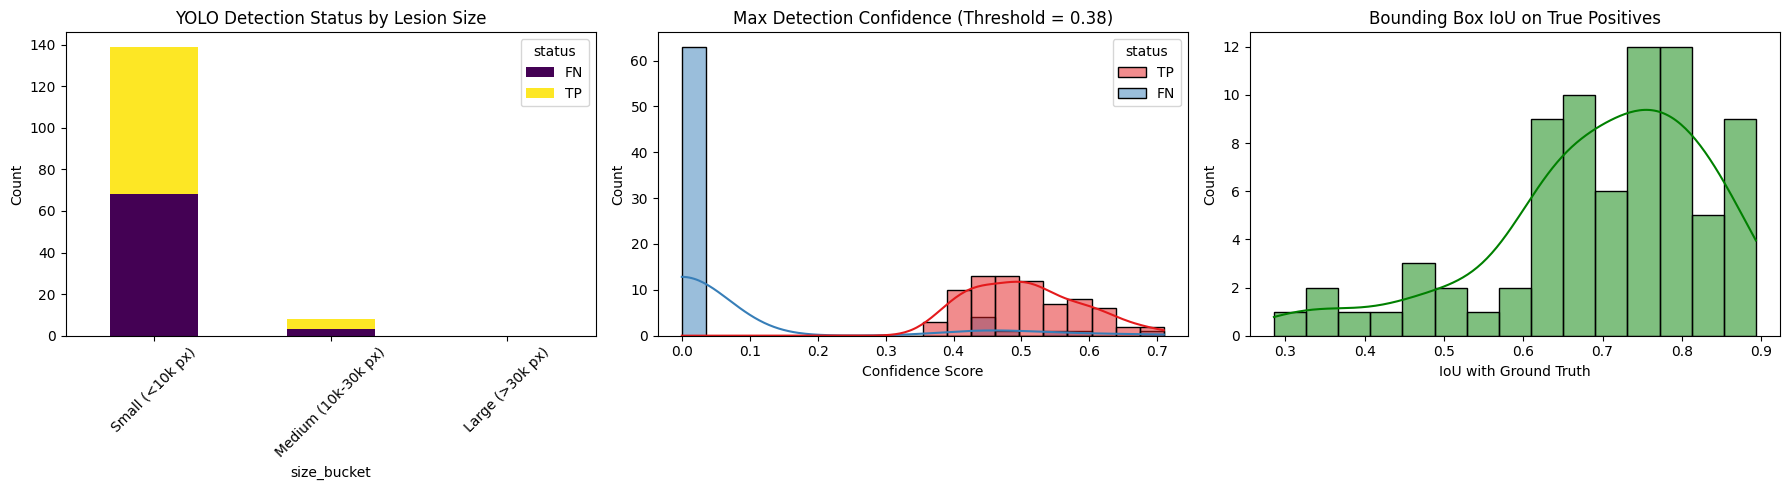


--- FN Size Breakdown (Counts & %) ---
Small (<10k px)     :  68 misses (95.8%)
Medium (10k-30k px) :   3 misses (4.2%)
Large (>30k px)     :   0 misses (0.0%)


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. FN Size Breakdown
fn_df = diag_df[diag_df.status == "FN"]
tp_df = diag_df[diag_df.status == "TP"]

size_order = ["Small (<10k px)", "Medium (10k-30k px)", "Large (>30k px)"]
counts = diag_df.groupby(["size_bucket", "status"]).size().unstack(fill_value=0).reindex(size_order)
counts.plot(kind="bar", stacked=True, ax=axes[0], colormap="viridis")
axes[0].set_title("YOLO Detection Status by Lesion Size")
axes[0].set_ylabel("Count")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45)

# 2. YOLO Confidence Distribution
sns.histplot(data=diag_df, x="max_conf", hue="status", bins=20, kde=True, ax=axes[1], palette="Set1")
axes[1].set_title(f"Max Detection Confidence (Threshold = {test_conf})")
axes[1].set_xlabel("Confidence Score")

# 4. BBox Quality on Caught Cases (TPs only)
sns.histplot(data=tp_df, x="best_iou", bins=15, kde=True, ax=axes[3-1], color="green")
axes[2].set_title("Bounding Box IoU on True Positives")
axes[2].set_xlabel("IoU with Ground Truth")

plt.tight_layout()
plt.show()

print("\n--- FN Size Breakdown (Counts & %) ---")
total_fn = len(fn_df)
for bucket in size_order:
    c = len(fn_df[fn_df.size_bucket == bucket])
    pct = (c / total_fn * 100) if total_fn > 0 else 0
    print(f"{bucket:<20}: {c:>3} misses ({pct:.1f}%)")

### 3. Missed Lesion Gallery (Top 12 FNs by Size)

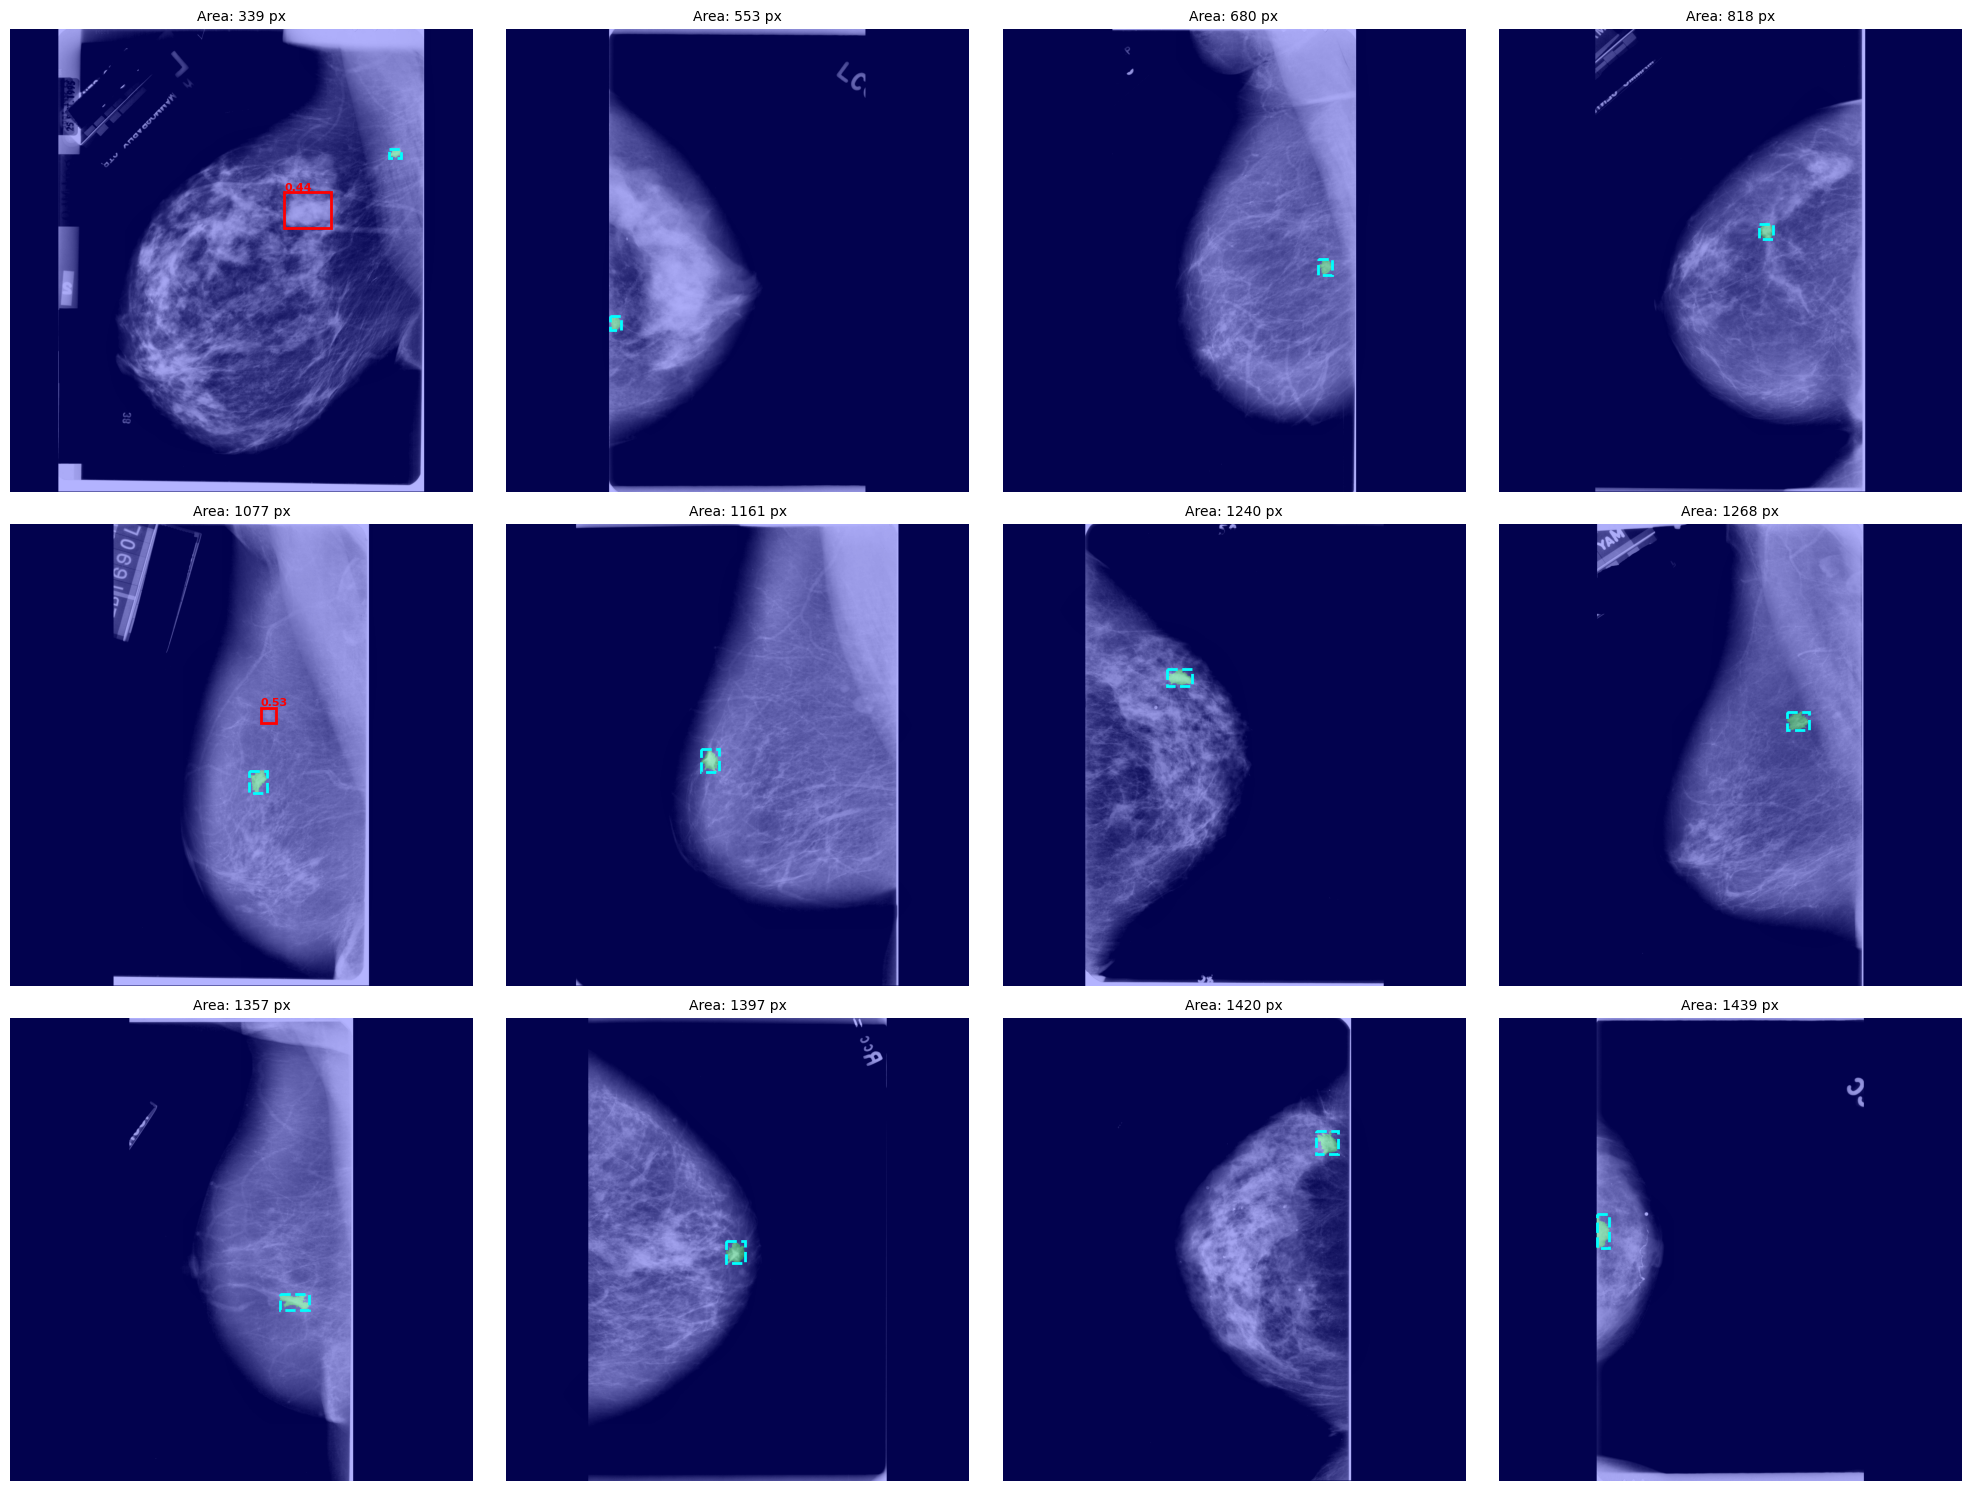

In [ ]:
import matplotlib.patches as patches

# Sort missed cases by area (ascending) and take top 12
missed_cases.sort(key=lambda x: x["area"])
top_misses = missed_cases[:12]

rows = (len(top_misses) + 3) // 4
fig, axes = plt.subplots(rows, 4, figsize=(20, 5 * rows))
axes = axes.flatten() if rows > 1 else axes

for i, m in enumerate(top_misses):
    ax = axes[i]
    rgb = load_rgb8(m["full"])
    mask = load_mask(m["roi"])
    if mask.shape != rgb.shape[:2]:
        mask = cv2.resize(mask, (rgb.shape[1], rgb.shape[0]), interpolation=cv2.INTER_NEAREST)

    gt_box = mask_to_bbox(mask)

    ax.imshow(rgb)
    ax.imshow(mask, alpha=0.3, cmap="winter")
    ax.axis("off")
    ax.set_title(f"Area: {m['area']} px", fontsize=10)

    # Draw GT Box
    if gt_box:
        ax.add_patch(patches.Rectangle((gt_box[0], gt_box[1]), gt_box[2]-gt_box[0], gt_box[3]-gt_box[1],
                                       fill=False, ec="cyan", lw=2, linestyle="--", label="GT"))

    # Draw Predicted Boxes (if any fired but missed IoU)
    if m["boxes"] is not None and len(m["boxes"]) > 0:
        sx, sy = m["W"] / m["orig_shape"][1], m["H"] / m["orig_shape"][0]
        for b, conf in zip(m["boxes"].xyxy.cpu().numpy(), m["boxes"].conf.cpu().numpy()):
            bx0, by0, bx1, by1 = int(b[0]*sx), int(b[1]*sy), int(b[2]*sx), int(b[3]*sy)
            ax.add_patch(patches.Rectangle((bx0, by0), bx1-bx0, by1-by0,
                                           fill=False, ec="red", lw=2, label=f"Pred {conf:.2f}"))
            ax.text(bx0, by0-5, f"{conf:.2f}", color="red", fontsize=8, weight="bold")

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
print("==========================================================")
print(f"      YOLO DIAGNOSTIC SUMMARY (Conf = {test_conf})")
print("==========================================================")

total_malignant = len(diag_df)
total_tp = len(tp_df)
total_fn = len(fn_df)
yolo_recall = total_tp / total_malignant if total_malignant > 0 else 0

print(f"Total Malignant Images Evaluated : {total_malignant}")
print(f"YOLO True Positives (Caught)     : {total_tp}")
print(f"YOLO False Negatives (Missed)    : {total_fn}")
print(f"YOLO Baseline Recall on Malignant: {yolo_recall:.4f}")

print("\n--- FN Size Breakdown ---")
size_order = ["Small (<10k px)", "Medium (10k-30k px)", "Large (>30k px)"]
for bucket in size_order:
    c = len(fn_df[fn_df.size_bucket == bucket])
    pct = (c / total_fn * 100) if total_fn > 0 else 0
    print(f"  {bucket:<20}: {c:>3} misses ({pct:.1f}%)")

print("\n--- TP Bounding Box Quality ---")
mean_iou = tp_df['best_iou'].mean() if not tp_df.empty else 0
median_iou = tp_df['best_iou'].median() if not tp_df.empty else 0
print(f"  Mean IoU on Caught Lesions   : {mean_iou:.4f}")
print(f"  Median IoU on Caught Lesions : {median_iou:.4f}")

print("\n--- Confidence Metrics ---")
mean_conf_tp = tp_df['max_conf'].mean() if not tp_df.empty else 0
print(f"  Mean YOLO Confidence (TPs)   : {mean_conf_tp:.4f}")
print("==========================================================")

      YOLO DIAGNOSTIC SUMMARY (Conf = 0.38)
Total Malignant Images Evaluated : 147
YOLO True Positives (Caught)     : 76
YOLO False Negatives (Missed)    : 71
YOLO Baseline Recall on Malignant: 0.5170

--- FN Size Breakdown ---
  Small (<10k px)     :  68 misses (95.8%)
  Medium (10k-30k px) :   3 misses (4.2%)
  Large (>30k px)     :   0 misses (0.0%)

--- TP Bounding Box Quality ---
  Mean IoU on Caught Lesions   : 0.6981
  Median IoU on Caught Lesions : 0.7272

--- Confidence Metrics ---
  Mean YOLO Confidence (TPs)   : 0.5057


In [ ]:
import pandas as pd
import numpy as np
import cv2
import torch
from tqdm.auto import tqdm

print("Sweeping YOLO confidence thresholds on the malignant test set...")

# Define the thresholds to evaluate
thresholds = [0.38, 0.30, 0.20, 0.15, 0.10]
results = {t: {"TP": 0, "FN": 0, "FP": 0, "small_TP": 0, "small_total": 0} for t in thresholds}

# Filter for malignant test cases only
test_malig_df = man[(man.split == "test") & (man.label == 1)].copy()

for _, r in tqdm(test_malig_df.iterrows(), total=len(test_malig_df)):
    rgb = load_rgb8(r.full)
    H, W = rgb.shape[:2]
    mask = load_mask(r.roi)
    gt_box = mask_to_bbox(mask)

    if gt_box is None:
        continue

    area = (mask > 0).sum()
    is_small = area < 10000

    # Increment total small counts for each threshold
    if is_small:
        for t in thresholds:
            results[t]["small_total"] += 1

    # Run detector at the minimum requested threshold to save inference time
    res = det.predict(rgb[..., ::-1], conf=min(thresholds), verbose=False)[0]

    boxes = []
    if res.boxes is not None and len(res.boxes) > 0:
        sx, sy = W / res.orig_shape[1], H / res.orig_shape[0]
        for b, conf in zip(res.boxes.xyxy.cpu().numpy(), res.boxes.conf.cpu().numpy()):
            bx = (int(b[0]*sx), int(b[1]*sy), int(b[2]*sx), int(b[3]*sy))
            boxes.append((bx, float(conf)))

    for t in thresholds:
        # Filter boxes that meet the current threshold
        t_boxes = [b for b in boxes if b[1] >= t]

        matched = False
        for bx, _ in t_boxes:
            if iou_xyxy(bx, gt_box) >= 0.2:
                matched = True
                break

        if matched:
            results[t]["TP"] += 1
            if is_small:
                results[t]["small_TP"] += 1
        else:
            results[t]["FN"] += 1

        # Any box that didn't match the GT is a false positive
        fp_count = max(0, len(t_boxes) - (1 if matched else 0))
        results[t]["FP"] += fp_count

# --- Display Results ---
print("\n" + "=" * 85)
print(f"{'Threshold':<10} | {'Recall':<10} | {'TP':<5} | {'FN':<5} | {'FP':<5} | {'Small Recovery (<10k px)':<25}")
print("-" * 85)
for t in thresholds:
    tp = results[t]["TP"]
    fn = results[t]["FN"]
    fp = results[t]["FP"]
    small_tp = results[t]["small_TP"]
    small_total = results[t]["small_total"]

    recall = tp / max(1, tp + fn)
    small_rec = (small_tp / small_total * 100) if small_total > 0 else 0.0

    print(f"{t:<10.2f} | {recall:<10.4f} | {tp:<5} | {fn:<5} | {fp:<5} | {small_tp}/{small_total} ({small_rec:.1f}%)")
print("=" * 85)

Sweeping YOLO confidence thresholds on the malignant test set...


  0%|          | 0/147 [00:00<?, ?it/s]


Threshold  | Recall     | TP    | FN    | FP    | Small Recovery (<10k px) 
-------------------------------------------------------------------------------------
0.38       | 0.5170     | 76    | 71    | 14    | 71/139 (51.1%)
0.30       | 0.6463     | 95    | 52    | 30    | 88/139 (63.3%)
0.20       | 0.7551     | 111   | 36    | 97    | 103/139 (74.1%)
0.15       | 0.7959     | 117   | 30    | 171   | 109/139 (78.4%)
0.10       | 0.8095     | 119   | 28    | 271   | 111/139 (79.9%)


### Random Image Inference Visualizer
Run this cell multiple times to see how the model behaves on different random images from the test set.

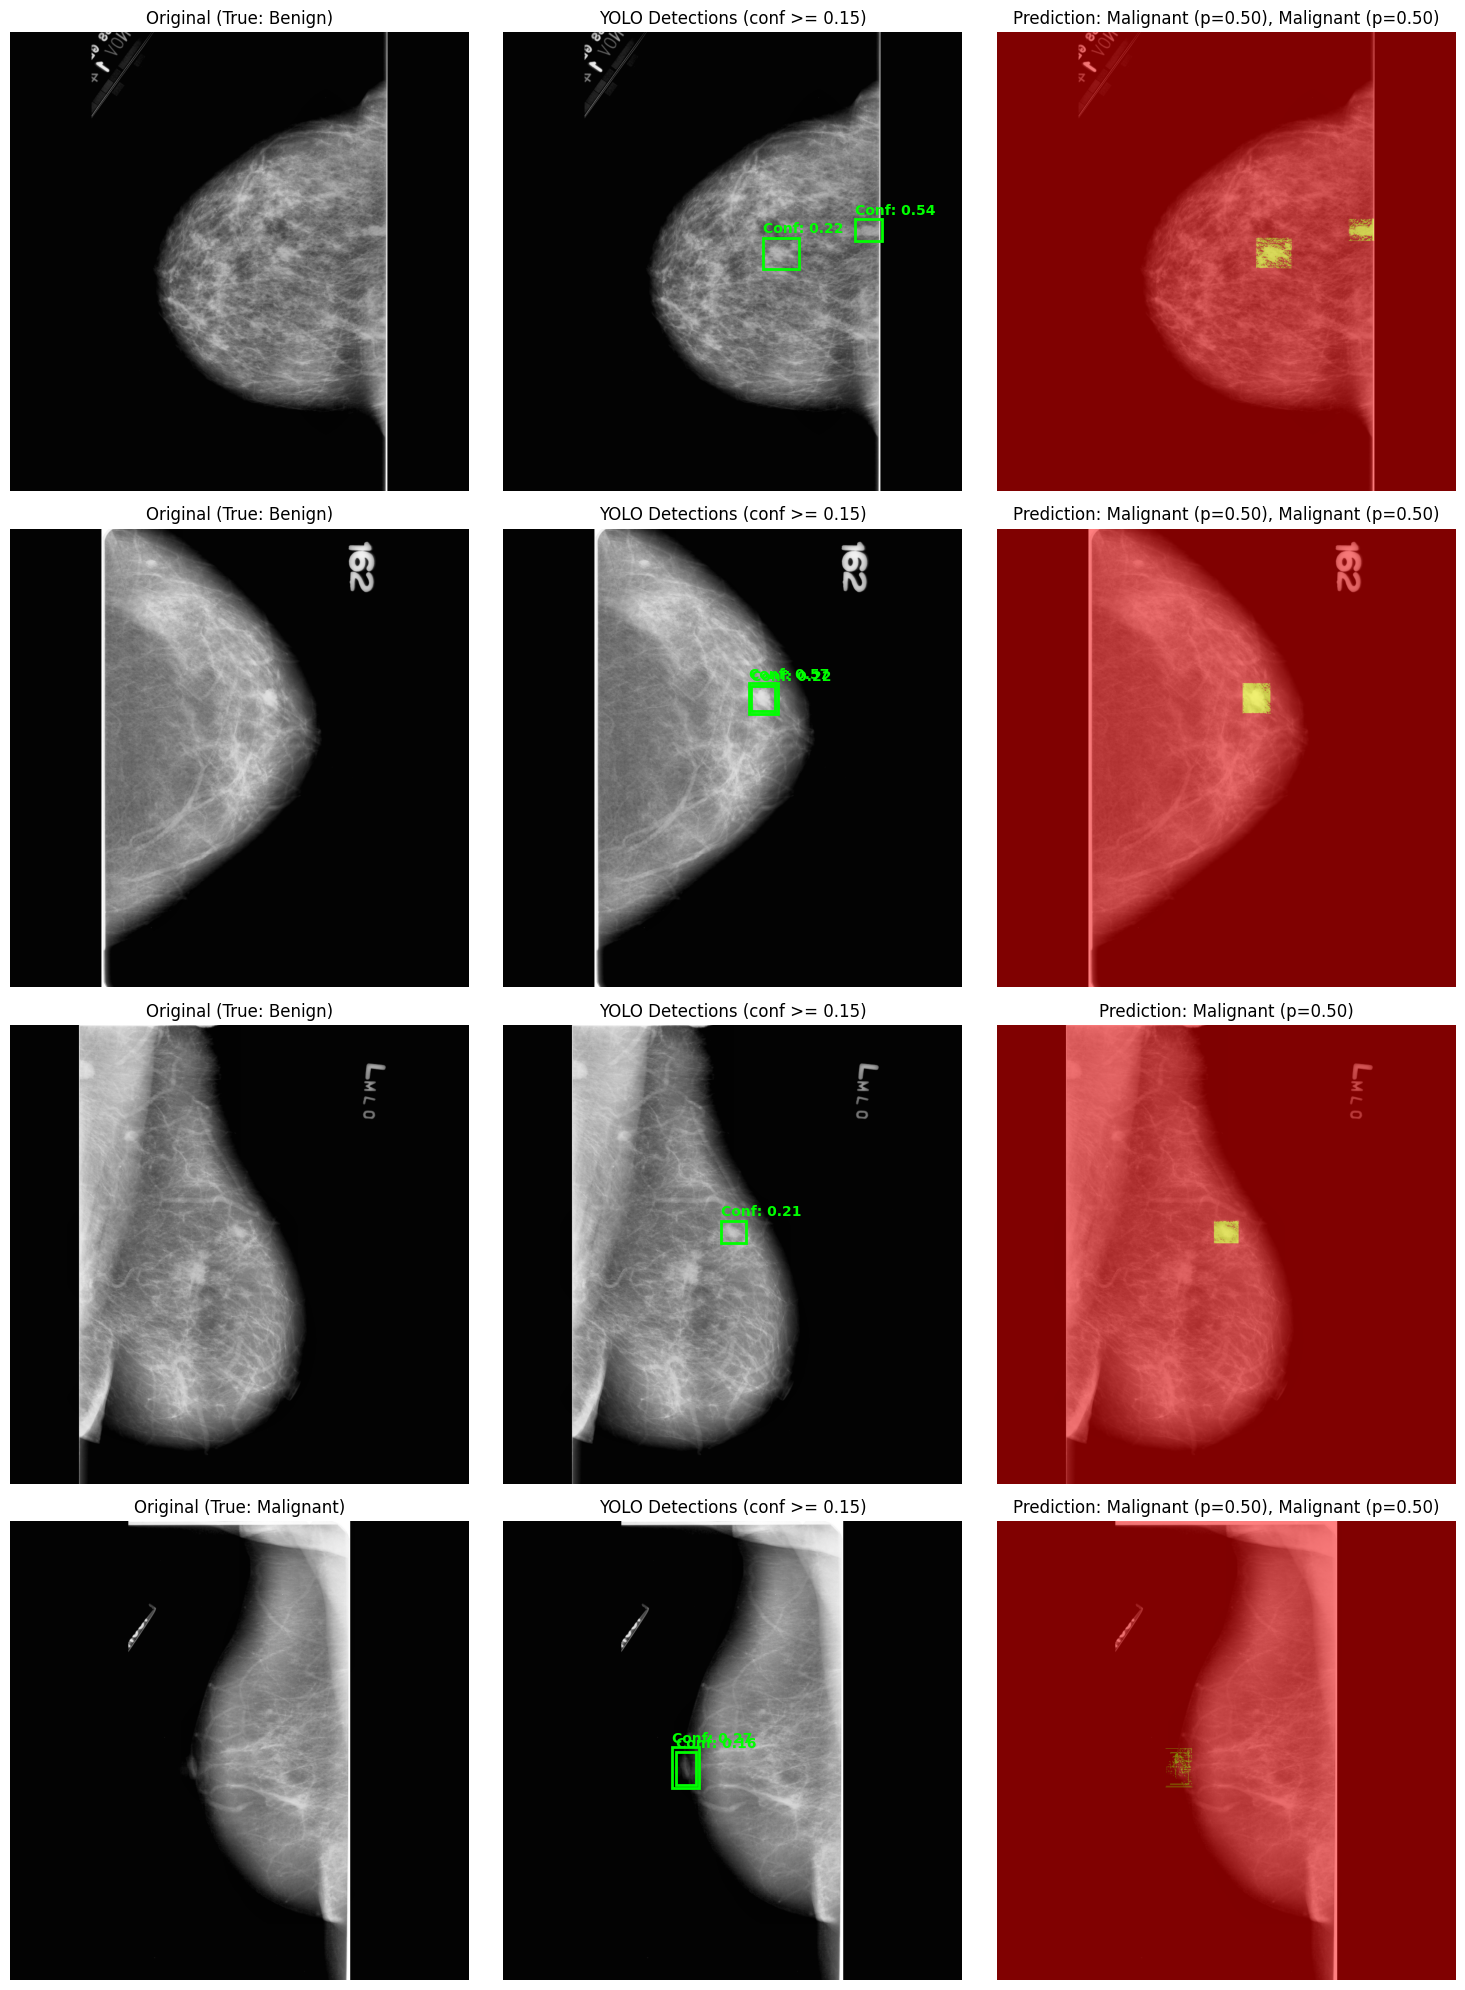

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import random
import cv2
import torch
import numpy as np

# Set threshold for YOLO (0.15 gives good recall as seen in previous cells)
inference_conf = 0.15
class_thresh = 0.35

# Sample 4 random images from the test set
sample_df = man[man.split == "test"].sample(n=4, random_state=random.randint(0, 10000))

fig, axes = plt.subplots(len(sample_df), 3, figsize=(15, 5 * len(sample_df)))
if len(sample_df) == 1: axes = [axes]

model_bias.eval()

for i, (_, r) in enumerate(sample_df.iterrows()):
    rgb = load_rgb8(r.full)
    H, W = rgb.shape[:2]

    # 1. Run YOLO Detector
    res = det.predict(rgb[..., ::-1], conf=inference_conf, verbose=False)[0]

    full_mask = np.zeros((H, W), np.float32)
    pred_texts = []

    # Plot Original
    ax_img = axes[i, 0]
    ax_img.imshow(rgb)
    ax_img.set_title(f"Original (True: {'Malignant' if r.label==1 else 'Benign'})")
    ax_img.axis("off")

    # Plot Boxes
    ax_box = axes[i, 1]
    ax_box.imshow(rgb)
    ax_box.set_title(f"YOLO Detections (conf >= {inference_conf})")
    ax_box.axis("off")

    # 2. Process Detections -> Segment & Classify
    if res.boxes is not None and len(res.boxes) > 0:
        sx, sy = W / res.orig_shape[1], H / res.orig_shape[0]
        for b, conf in zip(res.boxes.xyxy.cpu().numpy(), res.boxes.conf.cpu().numpy()):
            # Map box back to image coordinates and expand
            x0, y0, x1, y1 = expand_box(int(b[0]*sx), int(b[1]*sy), int(b[2]*sx), int(b[3]*sy), W, H, CFG.CROP_MARGIN)

            # Draw bounding box
            ax_box.add_patch(patches.Rectangle((x0, y0), x1-x0, y1-y0, fill=False, ec="lime", lw=2))
            ax_box.text(x0, max(0, y0-10), f"Conf: {conf:.2f}", color="lime", fontsize=10, weight="bold")

            # Crop and prepare for segmenter
            crop = cv2.resize(rgb[y0:y1, x0:x1], (CFG.CROP_SIZE, CFG.CROP_SIZE))
            x_t = ((torch.from_numpy(crop).float().permute(2,0,1)/255.0 - 0.5)/0.5).unsqueeze(0).to(DEVICE)

            # Run UNet++ Phase B (Bias Fixed)
            with torch.no_grad():
                seg, cls = model_bias(x_t)
                prob = torch.softmax(cls, 1)[0].cpu().numpy()

            # Get probabilities
            p_malig = prob[1] / (prob[0] + prob[1] + 1e-9)

            # Remap mask back to original image size
            pm = cv2.resize(torch.sigmoid(seg)[0,0].cpu().numpy(), (x1-x0, y1-y0))
            full_mask[y0:y1, x0:x1] = np.maximum(full_mask[y0:y1, x0:x1], pm)

            pred_class = "Malignant" if p_malig >= class_thresh else "Benign"
            pred_texts.append(f"{pred_class} (p={p_malig:.2f})")

    else:
        ax_box.text(W//2, H//2, "No Detections", color="red", fontsize=14, ha="center")

    # Plot Final Mask & Class
    ax_mask = axes[i, 2]
    ax_mask.imshow(rgb)
    ax_mask.imshow(full_mask > 0.5, alpha=0.5, cmap="autumn")
    title_str = f"Prediction: {', '.join(pred_texts)}" if pred_texts else "Prediction: None"
    ax_mask.set_title(title_str)
    ax_mask.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
import os
from pathlib import Path

# Cell 1: Download new 1536 dataset
DATASET_SLUG_1536 = "abdelrahmanelmugh/cbis-ddsm-1536fixed2"
DATASET_DIR_1536 = Path("/content/kaggle_data_1536")
DATASET_DIR_1536.mkdir(parents=True, exist_ok=True)

target_folder_1536 = DATASET_DIR_1536 / "CBIS-DDSM-1536fixed2"
if target_folder_1536.exists():
    print("Dataset already exists and is unzipped. Skipping download!")
else:
    print(f"Downloading {DATASET_SLUG_1536} to {DATASET_DIR_1536}...")
    !kaggle datasets download -d {DATASET_SLUG_1536} -p {DATASET_DIR_1536} --force

    print("Download complete. Unzipping...")
    zip_file_path_1536 = DATASET_DIR_1536 / f"{DATASET_SLUG_1536.split('/')[-1]}.zip"
    !unzip -q -o {zip_file_path_1536} -d {DATASET_DIR_1536}
    if zip_file_path_1536.exists():
        zip_file_path_1536.unlink()
    print("Dataset unzipped and ready.")

Dataset URL: https://www.kaggle.com/datasets/abdelrahmanelmugh/cbis-ddsm-1536fixed2
License(s): unknown
100% 4.25G/4.25G [01:12<00:00, 63.0MB/s]

Download complete. Unzipping...
Dataset unzipped and ready.


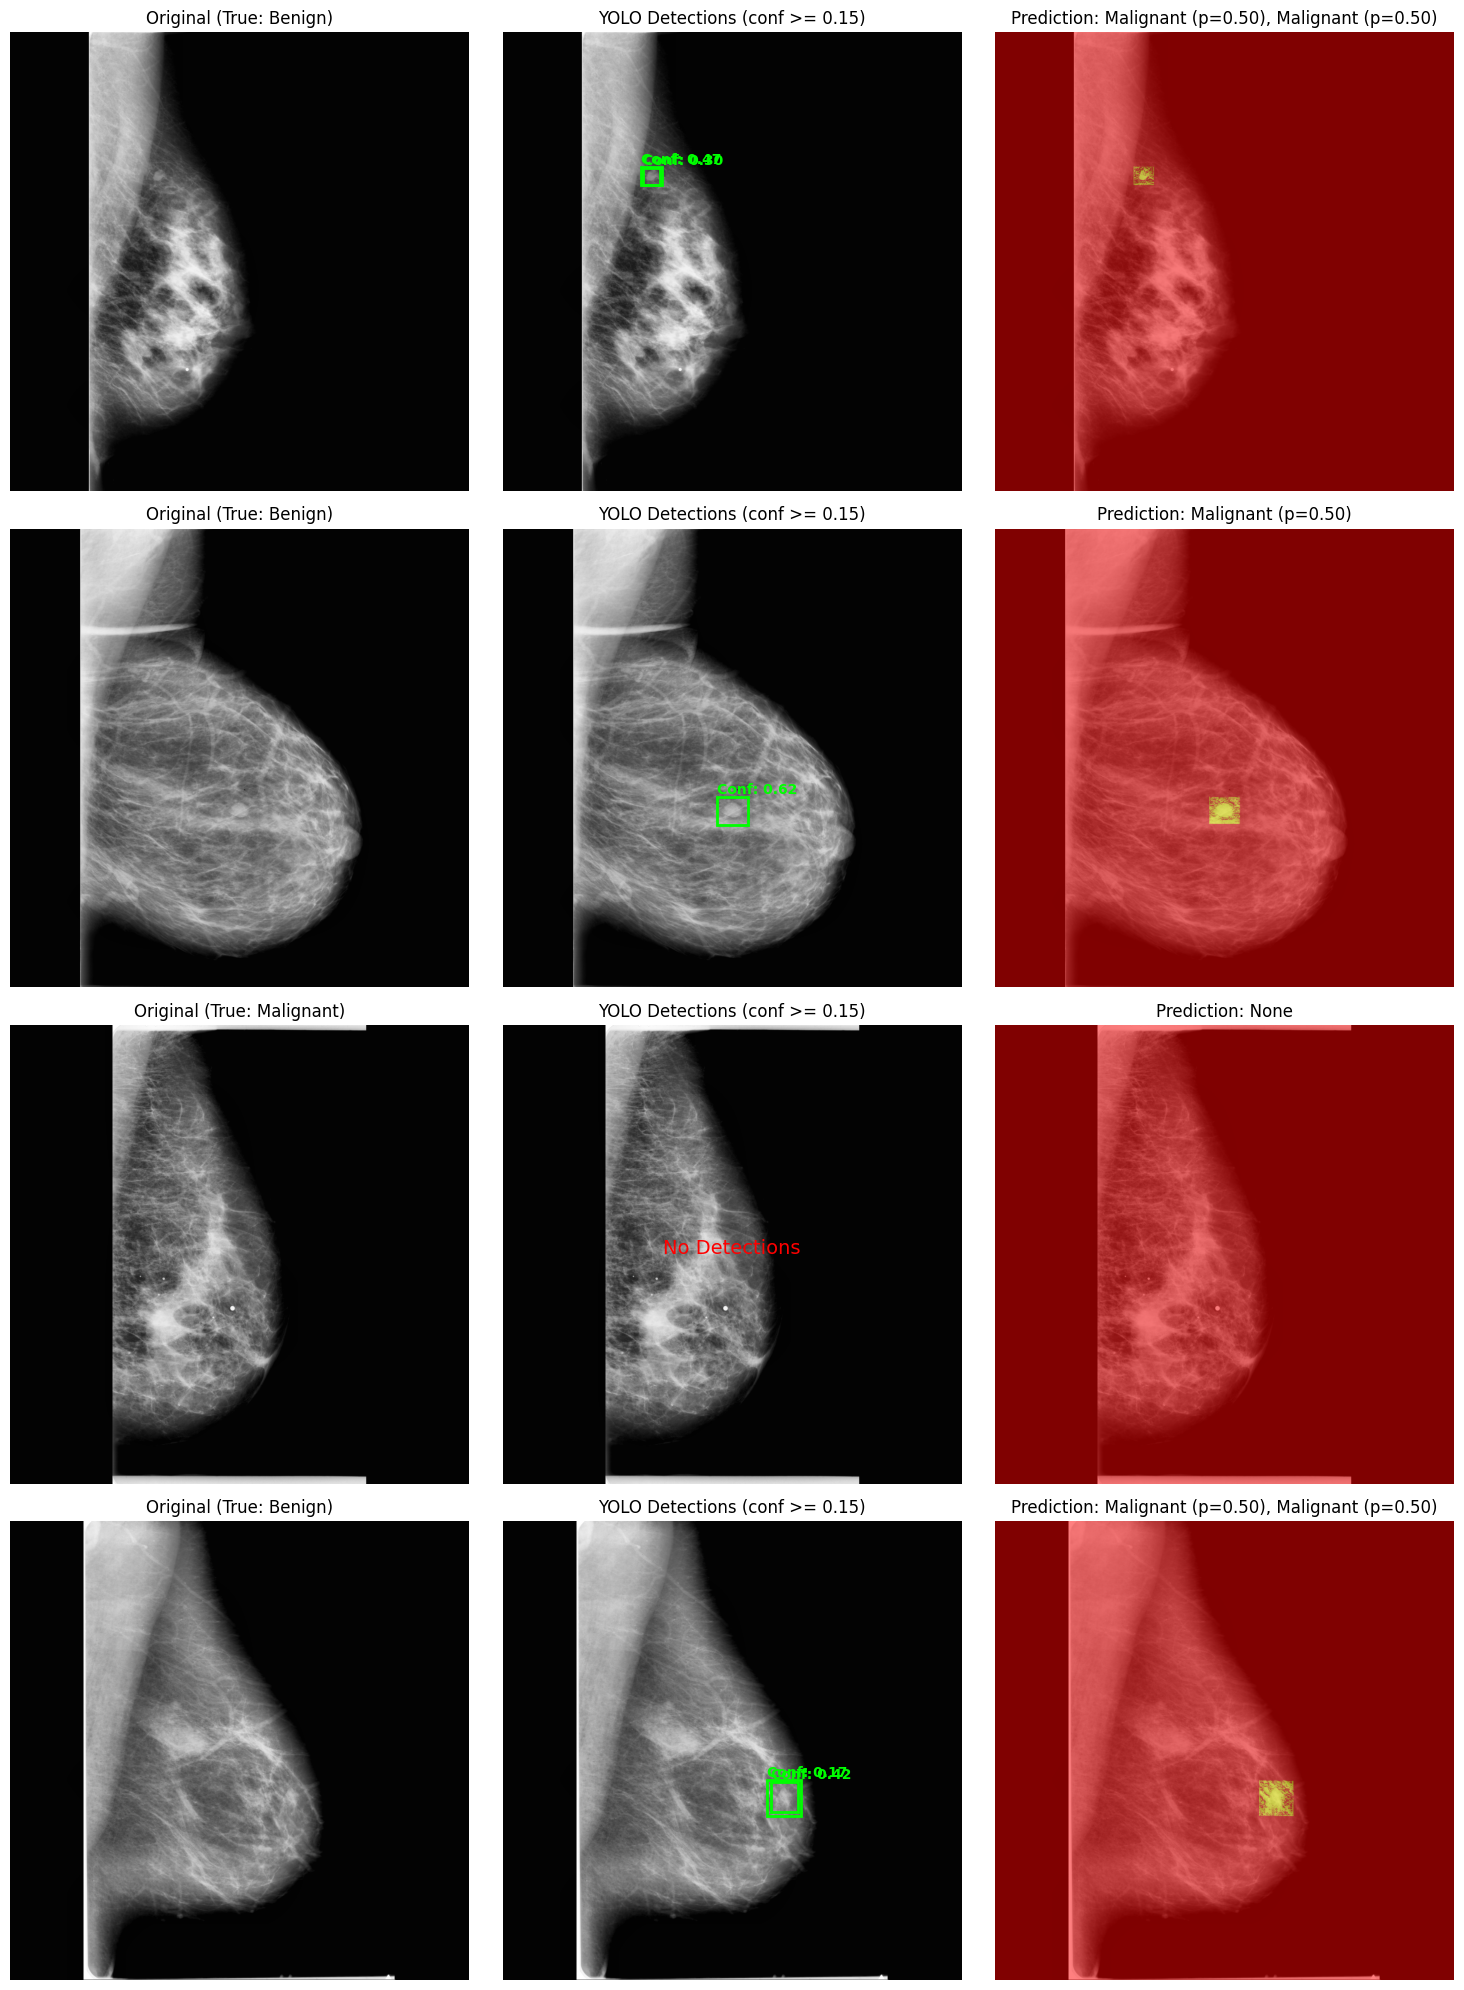

In [ ]:
import pandas as pd
import random
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Load the CSV for the new 1536 dataset
csv_files = list(DATASET_DIR_1536.rglob("*.csv"))
if not csv_files:
    raise FileNotFoundError(f"No CSV file found in {DATASET_DIR_1536}. The Kaggle download in the previous cell likely failed (403 Forbidden). Check your dataset access permissions on Kaggle.")

csv_path_1536 = csv_files[0]
df_1536 = pd.read_csv(csv_path_1536)

# Filter for masses
abn_col = next((c for c in df_1536.columns if "abnorm" in c.lower()), None)
if abn_col:
    df_1536 = df_1536[df_1536[abn_col].str.lower().str.strip() == "mass"].copy()

# Identify columns dynamically
c_full = next((c for c in df_1536.columns if c.lower() in ["full_path", "image_path"]), None)
c_label = next((c for c in df_1536.columns if c.lower() in ["pathology", "label"]), None)
c_split = next((c for c in df_1536.columns if "split" in c.lower()), None)

# Sanitize Windows paths
def fix_win_path_1536(p):
    if pd.isna(p): return p
    p = str(p).replace('\\', '/')
    if 'CBIS-DDSM-1536fixed2/' in p:
        p = p.split('CBIS-DDSM-1536fixed2/')[-1]
    return p

df_1536[c_full] = df_1536[c_full].apply(fix_win_path_1536)

# Sample 4 random images
if c_split and "Test" in df_1536[c_split].unique():
    sample_df = df_1536[df_1536[c_split].str.capitalize() == "Test"].sample(n=4, random_state=random.randint(0, 10000))
else:
    sample_df = df_1536.sample(n=4, random_state=random.randint(0, 10000))

# Temporarily redirect CFG.IMAGE_ROOT so load_rgb8 looks in the 1536 folder
old_image_root = CFG.IMAGE_ROOT
CFG.IMAGE_ROOT = str(csv_path_1536.parent)

inference_conf = 0.15
class_thresh = 0.35

fig, axes = plt.subplots(len(sample_df), 3, figsize=(15, 5 * len(sample_df)))
if len(sample_df) == 1: axes = [axes]
model_bias.eval()

for i, (_, r) in enumerate(sample_df.iterrows()):
    rgb = load_rgb8(r[c_full])
    H, W = rgb.shape[:2]

    res = det.predict(rgb[..., ::-1], conf=inference_conf, verbose=False)[0]

    full_mask = np.zeros((H, W), np.float32)
    pred_texts = []

    label_val = r[c_label]
    true_class = "Malignant" if str(label_val).strip().upper() in ["1", "MALIGNANT"] else "Benign"

    ax_img = axes[i, 0]
    ax_img.imshow(rgb)
    ax_img.set_title(f"Original (True: {true_class})")
    ax_img.axis("off")

    ax_box = axes[i, 1]
    ax_box.imshow(rgb)
    ax_box.set_title(f"YOLO Detections (conf >= {inference_conf})")
    ax_box.axis("off")

    if res.boxes is not None and len(res.boxes) > 0:
        sx, sy = W / res.orig_shape[1], H / res.orig_shape[0]
        for b, conf in zip(res.boxes.xyxy.cpu().numpy(), res.boxes.conf.cpu().numpy()):
            x0, y0, x1, y1 = expand_box(int(b[0]*sx), int(b[1]*sy), int(b[2]*sx), int(b[3]*sy), W, H, CFG.CROP_MARGIN)

            ax_box.add_patch(patches.Rectangle((x0, y0), x1-x0, y1-y0, fill=False, ec="lime", lw=2))
            ax_box.text(x0, max(0, y0-10), f"Conf: {conf:.2f}", color="lime", fontsize=10, weight="bold")

            crop = cv2.resize(rgb[y0:y1, x0:x1], (CFG.CROP_SIZE, CFG.CROP_SIZE))
            x_t = ((torch.from_numpy(crop).float().permute(2,0,1)/255.0 - 0.5)/0.5).unsqueeze(0).to(DEVICE)

            with torch.no_grad():
                seg, cls = model_bias(x_t)
                prob = torch.softmax(cls, 1)[0].cpu().numpy()

            p_malig = prob[1] / (prob[0] + prob[1] + 1e-9)

            pm = cv2.resize(torch.sigmoid(seg)[0,0].cpu().numpy(), (x1-x0, y1-y0))
            full_mask[y0:y1, x0:x1] = np.maximum(full_mask[y0:y1, x0:x1], pm)

            pred_class = "Malignant" if p_malig >= class_thresh else "Benign"
            pred_texts.append(f"{pred_class} (p={p_malig:.2f})")

    else:
        ax_box.text(W//2, H//2, "No Detections", color="red", fontsize=14, ha="center")

    ax_mask = axes[i, 2]
    ax_mask.imshow(rgb)
    ax_mask.imshow(full_mask > 0.5, alpha=0.5, cmap="autumn")
    title_str = f"Prediction: {', '.join(pred_texts)}" if pred_texts else "Prediction: None"
    ax_mask.set_title(title_str)
    ax_mask.axis("off")

# Restore original image root to avoid breaking older cells
CFG.IMAGE_ROOT = old_image_root

plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import cv2
import pandas as pd
from tqdm.auto import tqdm
from pathlib import Path

print("1. Identifying the 'Hard 28' cases from the 1024px baseline...")
old_root = CFG.IMAGE_ROOT
CFG.IMAGE_ROOT = "/content/kaggle_data/CBIS-DDSM-1024fixed2"

test_malig_1024 = man[(man.split == "test") & (man.label == 1)]
hard_28_ids = set()

for _, r in tqdm(test_malig_1024.iterrows(), total=len(test_malig_1024), desc="1024px Baseline (conf=0.10)"):
    rgb = load_rgb8(r.full)
    H, W = rgb.shape[:2]
    mask = load_mask(r.roi)
    gt_box = mask_to_bbox(mask)
    if gt_box is None: continue

    res = det.predict(rgb[..., ::-1], conf=0.10, verbose=False)[0]
    matched = False
    if res.boxes is not None and len(res.boxes) > 0:
        sx, sy = W / res.orig_shape[1], H / res.orig_shape[0]
        for b in res.boxes.xyxy.cpu().numpy():
            bx = (int(b[0]*sx), int(b[1]*sy), int(b[2]*sx), int(b[3]*sy))
            if iou_xyxy(bx, gt_box) >= 0.2:
                matched = True
                break
    if not matched:
        # We use the filename stem to uniquely match between 1024 and 1536 versions
        hard_28_ids.add(Path(r.full).name)

print(f"Found {len(hard_28_ids)} Hard FN cases at 1024px.")

print("\n2. Running YOLO on 1536px test set (imgsz=1536)...")
CFG.IMAGE_ROOT = str(csv_path_1536.parent)

c_split_1536 = next((c for c in df_1536.columns if "split" in c.lower()), None)
c_label_1536 = next((c for c in df_1536.columns if "pathology" in c.lower() or "label" in c.lower()), None)
c_full_1536 = next((c for c in df_1536.columns if "full_path" in c.lower() or "image_path" in c.lower()), None)
c_roi_1536 = next((c for c in df_1536.columns if "roi_path" in c.lower() or "mask_path" in c.lower()), None)

test_malig_1536 = df_1536[(df_1536[c_split_1536].str.capitalize() == "Test") & (df_1536[c_label_1536].astype(str).str.upper().isin(["1", "MALIGNANT"]))]

thresholds = [0.38, 0.30, 0.20, 0.15, 0.10]
res_1536 = {t: {"TP": 0, "FN": 0, "FP": 0, "small_TP": 0, "small_total": 0, "hard_TP": 0, "ious": []} for t in thresholds}

for _, r in tqdm(test_malig_1536.iterrows(), total=len(test_malig_1536), desc="1536px Inference"):
    rgb = load_rgb8(r[c_full_1536])
    mask = load_mask(r[c_roi_1536])
    H, W = rgb.shape[:2]
    gt_box = mask_to_bbox(mask)
    if gt_box is None: continue

    area = (mask > 0).sum()
    # <10k area in 1024px is roughly <22.5k area in 1536px ((1536/1024)^2 = 2.25)
    is_small = area < 22500
    is_hard = Path(r[c_full_1536]).name in hard_28_ids

    for t in thresholds:
        if is_small: res_1536[t]["small_total"] += 1

    # Run inference at 1536
    res = det.predict(rgb[..., ::-1], imgsz=1536, conf=min(thresholds), verbose=False)[0]

    boxes = []
    if res.boxes is not None and len(res.boxes) > 0:
        sx, sy = W / res.orig_shape[1], H / res.orig_shape[0]
        for b, conf in zip(res.boxes.xyxy.cpu().numpy(), res.boxes.conf.cpu().numpy()):
            bx = (int(b[0]*sx), int(b[1]*sy), int(b[2]*sx), int(b[3]*sy))
            boxes.append((bx, float(conf)))

    for t in thresholds:
        t_boxes = [b for b in boxes if b[1] >= t]
        matched = False
        best_iou = 0.0

        for bx, _ in t_boxes:
            iou = iou_xyxy(bx, gt_box)
            if iou > best_iou:
                best_iou = iou

        if best_iou >= 0.2:
            matched = True

        if matched:
            res_1536[t]["TP"] += 1
            res_1536[t]["ious"].append(best_iou)
            if is_small: res_1536[t]["small_TP"] += 1
            if is_hard: res_1536[t]["hard_TP"] += 1
        else:
            res_1536[t]["FN"] += 1

        fp_count = max(0, len(t_boxes) - (1 if matched else 0))
        res_1536[t]["FP"] += fp_count

# Restore CFG
CFG.IMAGE_ROOT = old_root

# Print Report
base_1024 = {
    0.38: {"R": 0.5170, "TP": 76, "FN": 71, "FP": 14, "small": "71/139"},
    0.30: {"R": 0.6463, "TP": 95, "FN": 52, "FP": 30, "small": "88/139"},
    0.20: {"R": 0.7551, "TP": 111, "FN": 36, "FP": 97, "small": "103/139"},
    0.15: {"R": 0.7959, "TP": 117, "FN": 30, "FP": 171, "small": "109/139"},
    0.10: {"R": 0.8095, "TP": 119, "FN": 28, "FP": 271, "small": "111/139"},
}

print("\n" + "="*110)
print(f"{'Thresh':<8} | {'1024px Recall':<15} | {'1536px Recall':<15} | {'1536px TP/FN/FP':<20} | {'Small Rec':<15} | {'Hard 28 Rec':<15}")
print("-" * 110)
for t in thresholds:
    tp = res_1536[t]["TP"]
    fn = res_1536[t]["FN"]
    fp = res_1536[t]["FP"]
    recall = tp / max(1, tp+fn)
    small_tp = res_1536[t]["small_TP"]
    small_tot = res_1536[t]["small_total"]
    hard_tp = res_1536[t]["hard_TP"]

    b_rec = base_1024[t]["R"]

    # Formatting string properly
    print(f"{t:<8.2f} | {b_rec:<15.4f} | {recall:<15.4f} | {f'{tp}/{fn}/{fp}':<20} | {f'{small_tp}/{small_tot}':<15} | {f'{hard_tp}/{len(hard_28_ids)}':<15}")
print("="*110)

print("\n--- Bounding Box Quality Comparison (Conf 0.38) ---")
print("1024px Baseline: Mean IoU = 0.6981, Median IoU = 0.7272")
ious_38 = res_1536[0.38]["ious"]
if ious_38:
    print(f"1536px Test    : Mean IoU = {np.mean(ious_38):.4f}, Median IoU = {np.median(ious_38):.4f}")
else:
    print("1536px Test    : No TPs to calculate IoU.")


1. Identifying the 'Hard 28' cases from the 1024px baseline...


1024px Baseline (conf=0.10):   0%|          | 0/147 [00:00<?, ?it/s]

Found 28 Hard FN cases at 1024px.

2. Running YOLO on 1536px test set (imgsz=1536)...


1536px Inference:   0%|          | 0/147 [00:00<?, ?it/s]


Thresh   | 1024px Recall   | 1536px Recall   | 1536px TP/FN/FP      | Small Rec       | Hard 28 Rec    
--------------------------------------------------------------------------------------------------------------
0.38     | 0.5170          | 0.2857          | 42/105/78            | 41/139          | 1/28           
0.30     | 0.6463          | 0.4286          | 63/84/140            | 60/139          | 2/28           
0.20     | 0.7551          | 0.5102          | 75/72/318            | 72/139          | 3/28           
0.15     | 0.7959          | 0.5646          | 83/64/497            | 80/139          | 6/28           
0.10     | 0.8095          | 0.6259          | 92/55/836            | 89/139          | 9/28           

--- Bounding Box Quality Comparison (Conf 0.38) ---
1024px Baseline: Mean IoU = 0.6981, Median IoU = 0.7272
1536px Test    : Mean IoU = 0.6225, Median IoU = 0.6642


In [ ]:
import pandas as pd
import numpy as np
import cv2
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, accuracy_score, recall_score, confusion_matrix, roc_curve
from tqdm.auto import tqdm

print("Running Inference Pipeline with YOLO conf = 0.20...")

def dice_np(pred, gt, eps=1e-6):
    p = (pred > 0.5).astype(np.float32); g = (gt > 0).astype(np.float32)
    return (2*(p*g).sum()+eps)/(p.sum()+g.sum()+eps)

inference_conf = 0.20
old_image_root = CFG.IMAGE_ROOT
CFG.IMAGE_ROOT = "/content/kaggle_data/CBIS-DDSM-1024fixed2" # Ensure correct path for baseline

test_df = man[man.split=="test"]

y_true_020 = []
y_score_020 = []
e2e_020 = []
roi_020 = []

model_bias.eval()

for _, r in tqdm(test_df.iterrows(), total=len(test_df)):
    rgb = load_rgb8(r.full)
    H, W = rgb.shape[:2]

    # YOLO Detection at conf=0.20
    res = det.predict(rgb[..., ::-1], conf=inference_conf, verbose=False)[0]

    full_mask = np.zeros((H, W), np.float32)
    dets = []

    if res.boxes is not None and len(res.boxes) > 0:
        sx, sy = W / res.orig_shape[1], H / res.orig_shape[0]
        order = res.boxes.conf.cpu().numpy().argsort()[::-1][:CFG.YOLO_TOPK]
        for k in order:
            b = res.boxes.xyxy.cpu().numpy()[k]
            x0, y0, x1, y1 = expand_box(int(b[0]*sx), int(b[1]*sy), int(b[2]*sx), int(b[3]*sy), W, H, CFG.CROP_MARGIN)
            crop = cv2.resize(rgb[y0:y1, x0:x1], (CFG.CROP_SIZE, CFG.CROP_SIZE))
            x_t = ((torch.from_numpy(crop).float().permute(2,0,1)/255.0 - 0.5)/0.5).unsqueeze(0).to(DEVICE)

            with torch.no_grad():
                seg, cls = model_bias(x_t)
                pm = cv2.resize(torch.sigmoid(seg)[0,0].cpu().numpy(), (x1-x0, y1-y0))
                full_mask[y0:y1, x0:x1] = np.maximum(full_mask[y0:y1, x0:x1], pm)
                prob = torch.softmax(cls, 1)[0].cpu().numpy()
                tot = prob[0] + prob[1] + 1e-9
                dets.append(dict(box=(x0,y0,x1,y1), p_malig=float(prob[1]/tot)))

    gt = load_mask(r.roi)
    if gt.shape != full_mask.shape:
        gt = cv2.resize(gt, (full_mask.shape[1], full_mask.shape[0]), interpolation=cv2.INTER_NEAREST)

    d = dice_np(full_mask, gt)
    e2e_020.append(d)

    gb = mask_to_bbox(gt)
    if dets and gb is not None and any(iou_xyxy(dd["box"], gb) >= 0.2 for dd in dets):
        roi_020.append(d)

    y_true_020.append(r.label)
    y_score_020.append(max((dd["p_malig"] for dd in dets), default=0.0))

# Restore CFG.IMAGE_ROOT
CFG.IMAGE_ROOT = old_image_root

# Youden's J Optimization
fpr, tpr, thresholds = roc_curve(y_true_020, y_score_020)
J = tpr - fpr
opt_idx = np.argmax(J)
opt_thresh = thresholds[opt_idx]

y_pred_020 = [1 if s >= opt_thresh else 0 for s in y_score_020]
cm = confusion_matrix(y_true_020, y_pred_020)
tn, fp, fn, tp = cm.ravel()

auc_020 = roc_auc_score(y_true_020, y_score_020)
sens_020 = recall_score(y_true_020, y_pred_020)
spec_020 = tn / max(1, tn + fp)
acc_020 = accuracy_score(y_true_020, y_pred_020)
mean_e2e_020 = np.mean(e2e_020)
mean_roi_020 = np.mean(roi_020) if roi_020 else 0

print(f"\n--- Results with YOLO conf={inference_conf:.2f} ---")
print(f"Optimal Youden's J Threshold: {opt_thresh:.4f}\n")

comp_data = [
    {"Metric": "AUC", "Baseline (conf=0.38)": 0.6943, "New (conf=0.20)": auc_020},
    {"Metric": "Sensitivity", "Baseline (conf=0.38)": 0.6667, "New (conf=0.20)": sens_020},
    {"Metric": "Specificity", "Baseline (conf=0.38)": 0.6753, "New (conf=0.20)": spec_020},
    {"Metric": "Accuracy", "Baseline (conf=0.38)": 0.6720, "New (conf=0.20)": acc_020},
    {"Metric": "E2E Dice", "Baseline (conf=0.38)": 0.5027, "New (conf=0.20)": mean_e2e_020},
    {"Metric": "ROI-Dice", "Baseline (conf=0.38)": "N/A", "New (conf=0.20)": mean_roi_020},
    {"Metric": "FN", "Baseline (conf=0.38)": 49, "New (conf=0.20)": fn},
    {"Metric": "FP", "Baseline (conf=0.38)": 75, "New (conf=0.20)": fp},
]

comp_df = pd.DataFrame(comp_data)
for col in ["New (conf=0.20)"]:
    comp_df[col] = comp_df[col].apply(lambda x: f"{x:.4f}" if isinstance(x, float) else x)

display(comp_df)


Running Inference Pipeline with YOLO conf = 0.20...


  0%|          | 0/378 [00:00<?, ?it/s]


--- Results with YOLO conf=0.20 ---
Optimal Youden's J Threshold: 0.5000



,Metric,Baseline (conf=0.38),New (conf=0.20)
0,AUC,0.6943,0.5325
1,Sensitivity,0.6667,0.8571
2,Specificity,0.6753,0.2078
3,Accuracy,0.672,0.4603
4,E2E Dice,0.5027,0.2890
5,ROI-Dice,N/A,0.4431
6,FN,49,21.0000
7,FP,75,183.0000
